# 📋 РУКОВОДСТВО ПО ИСПОЛЬЗОВАНИЮ ШАБЛОНА

## Просмотр результатов

**Ноутбук уже выполнен.** Все графики и выводы видны сразу при открытии на GitHub.

### Источник данных:

**Датасет:** Stroke Prediction Dataset  
**Источник:** [Kaggle - Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

Итоги анализа датасета: [analysis_report_eda.md](analysis_report_eda.md)

> **Примечание:** Датасет не включён в репозиторий. Для самостоятельного запуска ноутбука необходимо скачать датасет и настроить пути в блоке 1.2.

---

## 🚀 БЫСТРЫЙ СТАРТ

1. **Выполни Preprocessing** → получи `metadata.json`, `X_train.csv`, `y_train.csv`
2. **Открой блок 1.2** → [НАСТРОЙКИ ПРОЕКТА](#scrollTo=obp4IhqxUBeM)
3. **Проверь пути** → `PROJECT_NAME` и `BASE_PATH` должны совпадать с Preprocessing
4. **Заполни стратегии** (опционально):
   - `missing_strategy` — как обрабатывать пропуски
   - `outliers_strategy` — как обрабатывать выбросы
   - `encoding_config` — как кодировать категории
   - `scaling_config` — как масштабировать числа
5. **Запусти все ячейки** → `Runtime → Run all`

---

## ⚠️ ВАЖНО: ПОСЛЕДОВАТЕЛЬНЫЙ ЗАПУСК

**Шаблон перезаписывает файлы и переменные в процессе работы.**

| Действие | Рекомендация |
|----------|--------------|
| ✅ **Запускайте ячейки последовательно** | Сверху вниз, без пропусков |
| ✅ **Используйте `Runtime → Run all`** | Для полного выполнения |
| ❌ **Не пропускайте блоки** | Нарушит цепочку трансформаций |
| ❌ **Не меняйте порядок выполнения** | Данные будут испорчены |

**Почему это важно:**
- `X_train` последовательно проходит: пропуски → выбросы → feature engineering → кодирование → масштабирование
- Каждый блок зависит от результатов предыдущего
- Нарушение порядка приведёт к ошибкам или неконсистентным данным

---

## ⚙️ ВСЕ НАСТРОЙКИ ПРОЕКТА (блок 1.3)

| Переменная | Что делает | Пример |
|------------|------------|--------|
| **`PROJECT_NAME`** | Имя проекта (должно совпадать с preprocessing) | `'stroke'` |
| **`BASE_PATH`** | Базовая папка на диске | `/content/drive/MyDrive/ml_learning` |
| **`AUTO_BINS`** | Автоматический расчёт bins (sqrt(n)) — справочно | `54` |
| **`BINS`** | Количество bins для гистограмм | `50` |
| **`HUE_BY_TARGET`** | Разделение графиков по целевой | `True` / `False` |
| **`EMPTY_MARKERS_STR`** | Маркеры пустот в строках | `['', 'null', 'none', 'na', 'n/a', '?', 'unknown', 'nan']` |
| **`EMPTY_MARKERS_NUM`** | Маркеры пустот в числах | `[-1, -999, 999, 999999]` |
| **`missing_strategy`** | Стратегия обработки пропусков | `{'smoking_status': ('constant', 'unknown')}` |
| **`outliers_strategy`** | Стратегия обработки выбросов | `{'age': ('keep', None)}` |
| **`NEW_FEATURES`** | Список новых признаков для анализа (блок 5.3) | `['cardio_risk', 'marriage_risk']` |
| **`encoding_config`** | Кодирование категориальных признаков | `{'marriage_risk': ('one_hot', None)}` |
| **`columns_to_drop_fe`** | Удаление признаков после FE | `['ever_married', 'hypertension', ...]` |
| **`features_to_drop`** | Удаление на основе корреляций | `['senior_work']` |
| **`features_to_drop_rf`** | Удаление на основе Random Forest (блок 8.5) | `[]` |
| **`scaling_config`** | Масштабирование числовых признаков | `{'age': ('standard', None)}` |
| **`columns_to_drop_final`** | Удаление признаков после трансформации | `[]` |
| **`RF_CLASS_WEIGHT`** | Балансировка классов в Random Forest | `'balanced'` |
| **`RF_N_ESTIMATORS`** | Количество деревьев в Random Forest | `100` |

---

## 📋 СТРАТЕГИИ ОБРАБОТКИ

### 1. Пропуски (`missing_strategy`)

| Стратегия | Описание | Пример |
|-----------|----------|--------|
| `drop_column` | Удалить колонку | `('drop_column', None)` |
| `mode` | Заполнить модой | `('mode', None)` |
| `median` | Заполнить медианой | `('median', None)` |
| `mean` | Заполнить средним | `('mean', None)` |
| `constant` | Заполнить константой | `('constant', 'unknown')` |
| `flag` | Создать флаг + заполнить | `('flag', 'median')` |

### 2. Выбросы (`outliers_strategy`)

| Стратегия | Описание | Пример |
|-----------|----------|--------|
| `keep` | Оставить как есть | `('keep', None)` |
| `cap` | Обрезать по границам | `('cap', (10, 60))` |
| `remove` | Удалить строки | `('remove', None)` |
| `log` | Логарифмировать | `('log', None)` |
| `flag` | Создать флаг | `('flag', None)` |

### 3. Кодирование (`encoding_config`)

| Метод | Описание | Когда использовать |
|-------|----------|---------------------|
| `one_hot` | One-Hot Encoding | Низкая кардинальность (≤10) |
| `label` | Label Encoding | Бинарные признаки (2 значения) |
| `target` | Target Encoding | Средняя/высокая кардинальность |
| `frequency` | Frequency Encoding | Альтернатива Target |
| `none` | Без кодирования | Уже числовой признак |

### 4. Масштабирование (`scaling_config`)

| Метод | Описание | Когда использовать |
|-------|----------|---------------------|
| `standard` | StandardScaler | Нормальное распределение |
| `robust` | RobustScaler | Есть выбросы |
| `minmax` | MinMaxScaler | Нейронные сети |
| `none` | Без масштабирования | Tree-based модели |

---

### 🛠️ FEATURE ENGINEERING (блок 5.1)

**⚠️ Блок НЕ универсален — требует ручной настройки под ваш датасет.**

Пример для проекта stroke:

```python
# Сердечно-сосудистый риск
X_train['cardio_risk'] = ((X_train['hypertension'] == 1) | (X_train['heart_disease'] == 1)).astype(int)

# Семейное положение с учётом возраста
def get_marriage_risk(row):
    if row['age'] <= 60:
        return 'young'
    elif row['ever_married'] == 'yes':
        return 'senior_married'
    else:
        return 'senior_unmarried'
X_train['marriage_risk'] = X_train.apply(get_marriage_risk, axis=1)
```

## 🎯 ОПРЕДЕЛЕНИЕ ТИПА ЗАДАЧИ

Тип задачи **автоматически считывается из `metadata.json`**, который создаётся в preprocessing.

| Целевая колонка | Уникальных значений | Результат |
|----------------|---------------------|-----------|
| 0/1 | 2 | **классификация** |
| float | много | **регрессия** |

**В EDA нет возможности изменить тип задачи** — это настройка preprocessing.  
Если тип определён неверно, вернись в preprocessing и укажи `FORCE_TASK_TYPE`:

```python
FORCE_TASK_TYPE = 'classification'  # или 'regression'
```

## 📁 СТРУКТУРА ПРОЕКТА

После выполнения EDA в папке `{PROJECT_NAME}` будет создана следующая структура:

<pre>
📁 {PROJECT_NAME}/
│
├── 📄 metadata.json                     # из Preprocessing
├── 📄 transformations_metadata.json      # конфиг трансформаций
├── 📄 production_metadata.json           # метаданные для production
│
├── 📁 checkpoints/
│   ├── 📄 03_missing_handled.csv         # после обработки пропусков
│   ├── 📄 04_outliers_handled_X.csv      # после обработки выбросов
│   ├── 📄 05_feature_engineering.csv     # после feature engineering
│   ├── 📄 06_features_selected.csv       # после корреляционного отбора
│   ├── 📄 07_rf_selected.csv             # после RF отбора
│   ├── 📄 08_final_X_train.csv           # финальные данные
│   └── 📄 09_final_processed.csv         # финальные масштабированные
│
├── 📁 splits/
│   ├── 📄 X_train_encoded.csv            # для деревьев (RF, XGBoost)
│   ├── 📄 X_train_scaled.csv             # для линейных моделей
│   ├── 📄 X_val_final.csv                # валидация (трансформированная)
│   ├── 📄 X_test_final.csv               # тест (трансформированный)
│   ├── 📄 y_val_final.csv                # целевая val
│   └── 📄 y_test_final.csv               # целевая test
│
├── 📁 transformers/
│   ├── 📄 encoders.pkl                   # энкодеры категорий
│   ├── 📄 scalers.pkl                    # скейлеры чисел
│   └── 📄 random_forest_importance.pkl   # RF для важности
│
└── 📁 reports/
    ├── 📄 eda_run_log_*.txt              # лог запуска
    ├── 📄 eda_final_report.txt           # итоговый отчёт
    └── 📁 plots/
        ├── 📄 distribution_*.png         # распределения числовых
        ├── 📄 target_distribution.png    # распределение целевой
        ├── 📄 binary_*.png               # бинарные признаки
        ├── 📄 boxplot_*.png              # визуализация выбросов
        ├── 📄 categorical_*.png          # категориальные признаки
        ├── 📄 correlation_heatmap_encoded.png  # тепловая карта
        ├── 📄 target_correlation.png     # связь с целевой (регрессия)
        ├── 📄 target_fvalue.png          # связь с целевой (классификация)
        └── 📄 feature_importance_rf.png  # важность признаков RF
</pre>

## 💡 ПОДСКАЗКИ

- **Блок 2.1** → базовая информация о данных (типы, пропуски, память)
- **Блок 3.1** → поиск скрытых пустот и рекомендации по стратегии
- **Блок 4.2** → статистика выбросов IQR и рекомендации
- **Блок 6.1** → анализ категорий и подсказки по кодированию
- **Блок 7.3** → связь признаков с целевой (корреляция / ANOVA)
- **Блок 8.3** → анализ важности RF и кандидаты на удаление

---

## ⚠️ ВАЖНО

- **Все трансформации применяются только к train**, затем через сохранённые объекты к val/test
- **Feature engineering** (блок 5.1) переписывается под конкретный датасет
- **TargetEncoder считает среднее по train**, для val/test используется сохранённый mapping
- **Масштабирование** после кодирования, чтобы новые one-hot колонки не масштабировались
- **Для деревьев используй `X_train_encoded.csv`**, для линейных моделей — `X_train_scaled.csv`


## 📚 Следующий этап

После выполнения шаблона EDA данные готовы для обучения модели. Уже готовы:

| Для деревьев (RF, XGBoost) | Для линейных моделей (LR, SVM) |
|---------------------------|-------------------------------|
| `X_train_encoded.csv` | `X_train_scaled.csv` |

**А также:**
- `X_val_final.csv`, `X_test_final.csv` — валидационные и тестовые данные
- `production_metadata.json` — метаданные для продакшена
- Обученные трансформеры в папке `transformers/`



#### ✅ Шаблон EDA готов к работе.



# СТРУКТУРА ШАБЛОНА EDA

**Версия 6.0**

---

## ЧАСТЬ 1: НАСТРОЙКА И ЗАГРУЗКА
| Блок | Название |
|------|----------|
| 1.1 | Импорт библиотек |
| 1.2 | Настройки проекта (менять под задачу) |
| 1.3 | Настройка путей проекта |
| 1.4 | Монтирование Google Drive |
| 1.5 | Загрузка метаданных (`metadata.json`) |
| 1.6 | Загрузка данных и проверка соответствия |
| 1.7 | Анализ целевой переменной |
| 1.8 | Сохранение лога запуска |

---

## ЧАСТЬ 2: ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ
| Блок | Название |
|------|----------|
| 2.1 | Базовая информация о данных |
| 2.2 | Статистика числовых колонок |
| 2.3 | Статистика категориальных колонок |
| 2.4 | Визуализация числовых колонок (непрерывные) |
| 2.5 | Визуализация целевой переменной |
| 2.6 | Анализ бинарных признаков |

---

## ЧАСТЬ 3: ОБРАБОТКА ПРОПУСКОВ
| Блок | Название |
|------|----------|
| 3.1 | Поиск всех видов пустот (включая скрытые) |
| 3.2 | Стратегия обработки пропусков |
| 3.3 | Применение стратегий обработки пропусков |
| 3.4 | Проверка результата обработки |
| 3.5 | Сохранение очищенных данных (`03_missing_handled.csv`) |

---

## ЧАСТЬ 4: ОБРАБОТКА ВЫБРОСОВ
| Блок | Название |
|------|----------|
| 4.1 | Визуализация выбросов (boxplot) |
| 4.2 | Статистика выбросов по методу IQR |
| 4.3 | Стратегия обработки выбросов |
| 4.4 | Применение стратегий обработки выбросов |
| 4.5 | Проверка результата обработки |
| 4.6 | Сохранение очищенных данных (`04_outliers_handled_X.csv`) |

---

## ЧАСТЬ 5: FEATURE ENGINEERING
| Блок | Название |
|------|----------|
| 5.1 | Создание новых признаков (кастомный код) |
| 5.2 | Удаление признаков после создания |
| 5.3 | Сводный анализ новых признаков |

---

## ЧАСТЬ 6: АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
| Блок | Название |
|------|----------|
| 6.1 | Общая информация о категориальных колонках |
| 6.2 | Визуализация распределения категорий |

---

## ЧАСТЬ 7: КОДИРОВАНИЕ И КОРРЕЛЯЦИЯ
| Блок | Название |
|------|----------|
| 7.1 | Кодирование категориальных признаков |
| 7.2 | Корреляция числовых признаков |
| 7.3 | Связь признаков с целевой переменной |
| 7.4 | Удаление признаков после корреляционного анализа (`06_features_selected.csv`) |

---

## ЧАСТЬ 8: ОТБОР ПРИЗНАКОВ (RANDOM FOREST)
| Блок | Название |
|------|----------|
| 8.1 | Подготовка данных для Random Forest |
| 8.2 | Обучение Random Forest и оценка важности |
| 8.3 | Удаление признаков на основе RF важности (`07_rf_selected.csv`) |

---

## ЧАСТЬ 9: ФИНАЛЬНАЯ ПОДГОТОВКА
| Блок | Название |
|------|----------|
| 9.1 | Определение типов колонок для масштабирования |
| 9.2 | Масштабирование числовых признаков |
| 9.3 | Финальное удаление признаков (`08_final_X_train.csv`) |
| 9.4 | Сохранение подготовленных данных и метаданных |
| 9.5 | Применение трансформаций к val/test |
| 9.6 | Итоговый отчёт EDA |

---

## КОНТРОЛЬНЫЕ ТОЧКИ
| Файл | Блок | Описание |
|------|------|----------|
| `03_missing_handled.csv` | 3.5 | После обработки пропусков |
| `04_outliers_handled_X.csv` | 4.6 | После обработки выбросов |
| `05_feature_engineering.csv` | 5.2 | После создания и удаления признаков |
| `06_features_selected.csv` | 7.4 | После корреляционного отбора |
| `07_rf_selected.csv` | 8.4 | После RF отбора |
| `08_final_X_train.csv` | 9.3 | Финальные данные (без масштабирования) |
| `09_final_processed.csv` | 9.4 | Финальные данные (с масштабированием) |

---

## ТРАНСФОРМЕРЫ
| Файл | Блок | Описание |
|------|------|----------|
| `encoders.pkl` | 7.1 | Энкодеры категориальных признаков |
| `scalers.pkl` | 9.2 | Скейлеры числовых признаков |
| `random_forest_importance.pkl` | 8.2 | Обученный RF для важности |

---

## МЕТАДАННЫЕ
| Файл | Блок | Описание |
|------|------|----------|
| `transformations_metadata.json` | 9.4 | Конфигурации трансформаций |
| `production_metadata.json` | 9.4 | Метаданные для production |
| `03_missing_strategy.json` | 3.5 | Применённые стратегии пропусков |
| `04_outliers_strategy.json` | 4.6 | Применённые стратегии выбросов |

---

## РЕЗУЛЬТАТЫ
**Папка `splits/`:**
- `X_train_encoded.csv` — для деревьев (RF, XGBoost)
- `X_train_scaled.csv` — для линейных моделей (LR, SVM)
- `X_val_final.csv`, `X_test_final.csv` — валидация и тест
- `y_val_final.csv`, `y_test_final.csv` — целевая для val/test

**Папка `reports/`:**
- `eda_run_log_*.txt` — лог запуска
- `eda_final_report.txt` — итоговый отчёт

**Папка `reports/plots/`:**
- `distribution_*.png` — распределения числовых признаков
- `target_distribution.png` — распределение целевой
- `binary_*.png` — анализ бинарных признаков
- `boxplot_*.png` — визуализация выбросов
- `categorical_*.png` — распределение категорий
- `correlation_heatmap_encoded.png` — тепловая карта корреляции
- `target_correlation.png` / `target_fvalue.png` — связь с целевой
- `feature_importance_rf.png` — важность признаков RF

---

# БЛОК 1. import библиотек

In [1]:
# 1.1 ИМПОРТ БИБЛИОТЕК

import os
import sys
import json
import warnings
import shutil
from datetime import datetime

import pandas as pd
import numpy as np
import sklearn
import joblib

# Визуализация
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ML и предобработка
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import f_classif, chi2

# Отображение
from IPython.display import display

# Настройки
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

# Определение окружения
try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ Среда выполнения: Google Colab")
except ImportError:
    IN_COLAB = False
    print("✓ Среда выполнения: локальная / Kaggle")

# Вывод версий
def print_versions():
    """Выводит версии ключевых библиотек"""
    print("\n📦 Версии пакетов:")
    print(f"   Python: {sys.version.split()[0]}")
    print(f"   pandas: {pd.__version__}")
    print(f"   numpy: {np.__version__}")
    print(f"   matplotlib: {matplotlib.__version__}")
    print(f"   seaborn: {sns.__version__}")
    print(f"   scikit-learn: {sklearn.__version__}")

print_versions()

✓ Среда выполнения: Google Colab

📦 Версии пакетов:
   Python: 3.12.13
   pandas: 2.2.2
   numpy: 2.0.2
   matplotlib: 3.10.0
   seaborn: 0.13.2
   scikit-learn: 1.6.1


# Ввод переменных

In [2]:
# 1.2 НАСТРОЙКИ ПРОЕКТА (менять под каждую задачу)

# --------------------------------------------
# 1. ПРОЕКТ (должно совпадать с preprocessing)
# --------------------------------------------
PROJECT_NAME = 'stroke'
BASE_PATH = '/content/drive/MyDrive/ml_learning'

# --------------------------------------------
# 2. ПАРАМЕТРЫ ВИЗУАЛИЗАЦИИ
# --------------------------------------------
AUTO_BINS = 54                    # справочно: √N (рассчитано по формуле)
BINS = 50                         # выбранное количество бинов
HUE_BY_TARGET = True              # разделять визуализации по целевой переменной

# --------------------------------------------
# 3. МАРКЕРЫ ПУСТОТЫ (скрытые пропуски)
# --------------------------------------------
EMPTY_MARKERS_STR = ['', 'null', 'none', 'na', 'n/a', '?', 'unknown', 'nan']
EMPTY_MARKERS_NUM = [-1, -999, 999, 999999]

# --------------------------------------------
# 4. СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ
# --------------------------------------------
# Формат: 'колонка': ('стратегия', 'параметр')
# Стратегии: 'drop_column', 'mode', 'median', 'mean', 'constant', 'flag'
missing_strategy = {
    'smoking_status': ('constant', 'unknown'),
}

# --------------------------------------------
# 5. СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ
# --------------------------------------------
# Формат: 'колонка': ('стратегия', 'параметр')
# Стратегии: 'keep', 'cap', 'remove', 'log', 'flag'
outliers_strategy = {
    'age': ('keep', None),
    'avg_glucose_level': ('keep', None),
    'bmi': ('keep', None),
}

# --------------------------------------------
# 6. НОВЫЕ ПРИЗНАКИ (созданные в блоке 5.1)
# --------------------------------------------
NEW_FEATURES = [
    'cardio_risk',
    'senior_work',
    'marriage_risk',
    'senior_work_1',
    'senior_work_2',
]

# --------------------------------------------
# 7. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# --------------------------------------------
# Методы: 'one_hot', 'label', 'frequency', 'target', 'none'
encoding_config = {
    'marriage_risk': ('one_hot', None),
}

# --------------------------------------------
# 8. УДАЛЕНИЕ ПРИЗНАКОВ
# --------------------------------------------
# 8.1 После feature engineering
columns_to_drop_fe = [
    'ever_married', 'hypertension', 'heart_disease',
    'work_type', 'gender', 'residence_type', 'smoking_status',
    'senior_stress', 'is_high_risk_work', 'high_risk_metabolic',
    'senior_stress_1', 'senior_stress_2', 'senior_stress_3',
    'stress_cardio', 'no_support_stress'
]

# 8.2 После корреляционного анализа
features_to_drop = ['senior_work', 'senior_work_1', 'senior_work_2',
]

# 8.3 На основе Random Forest важности
features_to_drop_rf = [
    # 'low_importance_feature',
]

# --------------------------------------------
# 9. МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ
# --------------------------------------------
# Формат: 'колонка': ('метод', параметры)
# Методы: 'standard', 'robust', 'minmax', 'none'
scaling_config = {
    'age': ('standard', None),              # нормальное распределение
    'avg_glucose_level': ('robust', None),  # скошенное, с выбросами
    'bmi': ('robust', None),                # лёгкая скошенность, выбросы
}

# --------------------------------------------
# 10. ФИНАЛЬНОЕ УДАЛЕНИЕ
# --------------------------------------------
columns_to_drop_final = [
    # 'id', 'user_id',
]

# --------------------------------------------
# 11. НАСТРОЙКИ RANDOM FOREST
# --------------------------------------------
RF_CLASS_WEIGHT = 'balanced'  # 'balanced', None, 'balanced_subsample'
RF_N_ESTIMATORS = 100         # количество деревьев

# --------------------------------------------
# 12. ПРОЧЕЕ
# --------------------------------------------
SAVE_INTERMEDIATE = True       # сохранять промежуточные данные
TARGET_COLUMN = None           # заполнится из metadata.json

# --------------------------------------------
# ВЫВОД НАСТРОЕК
# --------------------------------------------
print("\n" + "="*50)
print(f"📁 ПРОЕКТ: {PROJECT_NAME}")
print(f"📂 BASE_PATH: {BASE_PATH}")
print(f"🎯 HUE_BY_TARGET: {HUE_BY_TARGET}")
print(f"📊 BINS: {BINS} (справочно AUTO_BINS: {AUTO_BINS})")
print("="*50 + "\n")



📁 ПРОЕКТ: stroke
📂 BASE_PATH: /content/drive/MyDrive/ml_learning
🎯 HUE_BY_TARGET: True
📊 BINS: 50 (справочно AUTO_BINS: 54)



In [3]:
# 1.3 НАСТРОЙКА ПУТЕЙ ПРОЕКТА

# Проверка, что BASE_PATH определён
if 'BASE_PATH' not in globals():
    raise NameError("❌ BASE_PATH не определён. Выполните блок 1.2 (Настройки проекта)")

# Определение путей
PROJECT_PATH = os.path.join(BASE_PATH, 'datasets', PROJECT_NAME)
CHECKPOINT_PATH = os.path.join(PROJECT_PATH, 'checkpoints')
SPLITS_PATH = os.path.join(PROJECT_PATH, 'splits')
REPORTS_PATH = os.path.join(PROJECT_PATH, 'reports')
TRANSFORMERS_PATH = os.path.join(PROJECT_PATH, 'transformers')
PLOTS_PATH = os.path.join(REPORTS_PATH, 'plots')

# Создание всех папок
for path in [PROJECT_PATH, CHECKPOINT_PATH, SPLITS_PATH, REPORTS_PATH,
             TRANSFORMERS_PATH, PLOTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Вывод структуры
print("\n📂 СТРУКТУРА ПРОЕКТА:")
print(f"   {PROJECT_PATH}/")
print(f"   ├── checkpoints/")
print(f"   ├── splits/")
print(f"   ├── reports/")
print(f"   │   └── plots/")
print(f"   └── transformers/")
print(f"\n✓ Папки созданы (или уже существуют)")


📂 СТРУКТУРА ПРОЕКТА:
   /content/drive/MyDrive/ml_learning/datasets/stroke/
   ├── checkpoints/
   ├── splits/
   ├── reports/
   │   └── plots/
   └── transformers/

✓ Папки созданы (или уже существуют)


In [4]:
# 1.4 МОНТИРОВАНИЕ GOOGLE DRIVE

print("\n" + "="*50)
print("📂 МОНТИРОВАНИЕ GOOGLE DRIVE")
print("="*50)

if IN_COLAB:
    # Проверяем, нужно ли монтирование (если путь на диске)
    if BASE_PATH.startswith('/content/drive'):
        if os.path.ismount('/content/drive'):
            print("✓ Google Drive уже смонтирован")
        else:
            print("📂 Монтирование Google Drive...")

            # Очистка старой точки монтирования, если есть
            if os.path.exists('/content/drive') and not os.path.ismount('/content/drive'):
                shutil.rmtree('/content/drive')

            drive.mount('/content/drive')
            print("✓ Google Drive смонтирован")
    else:
        print("✓ BASE_PATH не на Google Drive, монтирование не требуется")
else:
    print("✓ Локальная среда, монтирование не требуется")

print("="*50 + "\n")


📂 МОНТИРОВАНИЕ GOOGLE DRIVE
📂 Монтирование Google Drive...
Mounted at /content/drive
✓ Google Drive смонтирован



In [5]:
# 1.5 ЗАГРУЗКА МЕТАДАННЫХ

print("\n" + "="*50)
print("📋 ЗАГРУЗКА МЕТАДАННЫХ")
print("="*50)

# Проверка, что PROJECT_PATH определён
if 'PROJECT_PATH' not in globals():
    raise NameError("❌ PROJECT_PATH не определён. Выполните блок 1.3")

metadata_path = os.path.join(PROJECT_PATH, 'metadata.json')

if os.path.exists(metadata_path):
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)

    # Извлечение ключевой информации
    TARGET_COLUMN = metadata.get('target_column')
    TASK_TYPE = metadata.get('task_type', 'classification')
    FEATURE_NAMES = metadata.get('feature_names', [])
    CLASS_COUNT = metadata.get('class_count', None)
    CLASSES = metadata.get('classes', [])
    TRAIN_SIZE = metadata.get('train_size', 0)
    VAL_SIZE = metadata.get('val_size', 0)
    TEST_SIZE = metadata.get('test_size', 0)
    PACKAGE_VERSIONS = metadata.get('package_versions', {})

    print("\n✓ Метаданные загружены:")
    print(f"   Проект: {metadata.get('project_name', 'N/A')}")
    print(f"   Целевая колонка: {TARGET_COLUMN}")
    print(f"   Тип задачи: {TASK_TYPE}")
    print(f"   Признаков: {len(FEATURE_NAMES)}")

    if TASK_TYPE == 'classification':
        print(f"   Классов: {CLASS_COUNT} {CLASSES}")

    print(f"   Размеры: train={TRAIN_SIZE}, val={VAL_SIZE}, test={TEST_SIZE}")
    print(f"   Дата обработки: {metadata.get('date_processed', 'N/A')}")

    if PACKAGE_VERSIONS:
        print(f"\n📦 Версии из preprocessing:")
        for pkg, ver in list(PACKAGE_VERSIONS.items())[:3]:
            print(f"   {pkg}: {ver}")
else:
    print("\n⚠️ ВНИМАНИЕ: metadata.json не найден!")
    print(f"   Путь: {metadata_path}")
    print("   Убедитесь, что preprocessing выполнен успешно.")

    # Устанавливаем значения по умолчанию
    TARGET_COLUMN = None
    TASK_TYPE = 'classification'
    FEATURE_NAMES = []
    CLASS_COUNT = None
    CLASSES = []
    TRAIN_SIZE = VAL_SIZE = TEST_SIZE = 0
    PACKAGE_VERSIONS = {}

print("\n" + "="*50)
print("✓ Загрузка метаданных завершена")
print("="*50 + "\n")


📋 ЗАГРУЗКА МЕТАДАННЫХ

✓ Метаданные загружены:
   Проект: stroke
   Целевая колонка: stroke
   Тип задачи: classification
   Признаков: 10
   Классов: 2 ['0', '1']
   Размеры: train=2911, val=971, test=971
   Дата обработки: 2026-04-09 21:45:44

📦 Версии из preprocessing:
   python: 3.12.13
   pandas: 2.2.2
   numpy: 2.0.2

✓ Загрузка метаданных завершена



In [6]:
# 1.6 ЗАГРУЗКА ТРЕНИРОВОЧНЫХ ДАННЫХ И ПРОВЕРКА СООТВЕТСТВИЯ

print("\n" + "="*50)
print("📥 ЗАГРУЗКА ДАННЫХ И ПРОВЕРКА")
print("="*50)

# Проверка, что SPLITS_PATH определён
if 'SPLITS_PATH' not in globals():
    raise NameError("❌ SPLITS_PATH не определён. Выполните блок 1.3")

X_train_path = os.path.join(SPLITS_PATH, 'X_train.csv')
y_train_path = os.path.join(SPLITS_PATH, 'y_train.csv')

if os.path.exists(X_train_path) and os.path.exists(y_train_path):
    # Загружаем признаки
    X_train = pd.read_csv(X_train_path)
    original_shape = X_train.shape

    # Загружаем целевую переменную
    y_train_df = pd.read_csv(y_train_path)
    if y_train_df.shape[1] == 1:
        y_train = y_train_df.iloc[:, 0]
    else:
        y_train = y_train_df

    # Присваиваем имя целевой переменной
    if TARGET_COLUMN and y_train_df.shape[1] == 1:
        y_train.name = TARGET_COLUMN

    print(f"\n✓ Данные загружены:")
    print(f"   X_train: {original_shape[0]} строк, {original_shape[1]} признаков")
    print(f"   y_train: {len(y_train)} значений")
    print(f"   Тип целевой: {y_train.dtype}")

    # --------------------------------------------
    # ПРОВЕРКА СООТВЕТСТВИЯ МЕТАДАННЫМ
    # --------------------------------------------
    print(f"\n🔍 Проверка соответствия метаданным:")

    if FEATURE_NAMES:
        expected_features = set(FEATURE_NAMES)
        actual_features = set(X_train.columns)

        missing = expected_features - actual_features
        extra = actual_features - expected_features

        if not missing and not extra:
            print(f"   ✓ Состав признаков полностью соответствует")
            print(f"     ({len(actual_features)} признаков)")
        else:
            print(f"   ⚠️ Набор признаков НЕ совпадает с метаданными!")
            print(f"      Ожидалось: {len(expected_features)}")
            print(f"      Загружено: {len(actual_features)}")

            if missing:
                print(f"\n      🔴 Отсутствуют ({len(missing)}):")
                for feat in sorted(missing)[:10]:
                    print(f"         • {feat}")
                if len(missing) > 10:
                    print(f"         ... и ещё {len(missing) - 10}")

            if extra:
                print(f"\n      🟡 Лишние ({len(extra)}):")
                for feat in sorted(extra)[:10]:
                    print(f"         • {feat}")
                if len(extra) > 10:
                    print(f"         ... и ещё {len(extra) - 10}")

            print(f"\n      💡 Проверьте preprocessing или обновите метаданные")
    else:
        print("   ⚠️ FEATURE_NAMES не загружены из metadata.json")

    # --------------------------------------------
    # РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
    # --------------------------------------------
    if TASK_TYPE == 'classification' and y_train.nunique() <= 20:
        print(f"\n📊 Распределение целевой переменной:")
        value_counts = y_train.value_counts()
        for cls, count in value_counts.items():
            pct = count / len(y_train) * 100
            print(f"   {cls}: {count:>6} ({pct:>5.1f}%)")

else:
    print("\n❌ ОШИБКА: Не найдены файлы X_train.csv или y_train.csv")
    print(f"   Путь: {SPLITS_PATH}")
    print("   Сначала выполните preprocessing.")
    X_train = None
    y_train = None
    original_shape = None

print("\n" + "="*50)
print("✓ Загрузка и проверка завершены")
print("="*50 + "\n")


📥 ЗАГРУЗКА ДАННЫХ И ПРОВЕРКА

✓ Данные загружены:
   X_train: 2911 строк, 10 признаков
   y_train: 2911 значений
   Тип целевой: int64

🔍 Проверка соответствия метаданным:
   ✓ Состав признаков полностью соответствует
     (10 признаков)

📊 Распределение целевой переменной:
   0:   2786 ( 95.7%)
   1:    125 (  4.3%)

✓ Загрузка и проверка завершены



In [7]:
# 1.7 ПРОВЕРКА ТИПА ЗАДАЧИ И ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

print("\n" + "="*50)
print("🎯 АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*50)

if y_train is None:
    print("\n⚠️ y_train не загружен. Пропускаем анализ.")
else:
    # Используем TASK_TYPE из метаданных
    print(f"\n📊 Тип задачи: {TASK_TYPE.upper()} (из metadata.json)")

    if TASK_TYPE == 'classification':
        print(f"\n   Количество классов: {y_train.nunique()}")
        print(f"   Распределение классов:")

        class_counts = y_train.value_counts()
        for cls, count in class_counts.items():
            pct = count / len(y_train) * 100
            print(f"   {cls}: {count:>6} ({pct:>5.1f}%)")

        # Проверка дисбаланса
        min_class_pct = class_counts.min() / len(y_train) * 100
        if min_class_pct < 10:
            imbalance_ratio = class_counts.max() / class_counts.min()
            print(f"\n⚠️ Обнаружен дисбаланс классов ({imbalance_ratio:.1f}:1)")
            print(f"   💡 Рекомендация: RF_CLASS_WEIGHT = 'balanced'")
        else:
            print(f"\n✓ Классы сбалансированы")

    else:  # regression
        print(f"\n   Целевая переменная: числовая")
        print(f"   Диапазон: [{y_train.min():.2f}, {y_train.max():.2f}]")
        print(f"   Среднее: {y_train.mean():.2f}")
        print(f"   Медиана: {y_train.median():.2f}")
        print(f"   Станд. отклонение: {y_train.std():.2f}")

print("\n" + "="*50)
print("✓ Анализ целевой переменной завершён")
print("="*50 + "\n")


🎯 АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

📊 Тип задачи: CLASSIFICATION (из metadata.json)

   Количество классов: 2
   Распределение классов:
   0:   2786 ( 95.7%)
   1:    125 (  4.3%)

⚠️ Обнаружен дисбаланс классов (22.3:1)
   💡 Рекомендация: RF_CLASS_WEIGHT = 'balanced'

✓ Анализ целевой переменной завершён



In [8]:
# 1.8 СОХРАНЕНИЕ ЛОГА ЗАПУСКА

print("\n" + "="*50)
print("📝 СОХРАНЕНИЕ ЛОГА ЗАПУСКА")
print("="*50)

def save_run_log(metadata_loaded):
    """Сохраняет лог запуска EDA"""

    log_lines = []
    log_lines.append("=" * 70)
    log_lines.append("EDA RUN LOG")
    log_lines.append(f"Дата и время запуска: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    log_lines.append("=" * 70)

    # 1. Версии библиотек
    log_lines.append("\n--- 1. ВЕРСИИ БИБЛИОТЕК ---")
    log_lines.append(f"pandas: {pd.__version__}")
    log_lines.append(f"numpy: {np.__version__}")
    log_lines.append(f"matplotlib: {matplotlib.__version__}")
    log_lines.append(f"seaborn: {sns.__version__}")

    try:
        import sklearn
        log_lines.append(f"scikit-learn: {sklearn.__version__}")
    except ImportError:
        log_lines.append("scikit-learn: не установлен")

    log_lines.append(f"joblib: {joblib.__version__}")

    # Сравнение версий с preprocessing
    if PACKAGE_VERSIONS:
        log_lines.append("\n--- Сравнение версий с preprocessing ---")
        for pkg, ver in PACKAGE_VERSIONS.items():
            current = globals().get(pkg, pd).__version__ if pkg in globals() else 'N/A'
            match = "✓" if current == ver else "⚠️"
            log_lines.append(f"{match} {pkg}: {ver} → {current}")

    # 2. Параметры проекта
    log_lines.append("\n--- 2. ПАРАМЕТРЫ ПРОЕКТА ---")
    log_lines.append(f"PROJECT_NAME: {PROJECT_NAME}")
    log_lines.append(f"BASE_PATH: {BASE_PATH}")
    log_lines.append(f"TASK_TYPE: {TASK_TYPE}")
    log_lines.append(f"HUE_BY_TARGET: {HUE_BY_TARGET}")
    log_lines.append(f"BINS: {BINS}")

    # 3. Информация о данных
    log_lines.append("\n--- 3. ИНФОРМАЦИЯ О ДАННЫХ ---")
    if X_train is not None and y_train is not None:
        log_lines.append(f"X_train shape: {X_train.shape[0]} строк, {X_train.shape[1]} колонок")
        log_lines.append(f"y_train: {len(y_train)} значений")
        log_lines.append(f"Тип целевой: {y_train.dtype}")

        if TASK_TYPE == 'classification':
            log_lines.append(f"Количество классов: {y_train.nunique()}")
            log_lines.append("Распределение классов:")
            for cls, count in y_train.value_counts().items():
                log_lines.append(f"  {cls}: {count} ({count/len(y_train)*100:.1f}%)")
        else:
            log_lines.append(f"Диапазон целевой: [{y_train.min():.2f}, {y_train.max():.2f}]")
            log_lines.append(f"Среднее: {y_train.mean():.2f}")
            log_lines.append(f"Медиана: {y_train.median():.2f}")
            log_lines.append(f"Станд. отклонение: {y_train.std():.2f}")

        # Использование памяти
        memory_mb = X_train.memory_usage(deep=True).sum() / 1024 / 1024
        log_lines.append(f"Память X_train: {memory_mb:.2f} MB")
    else:
        log_lines.append("⚠️ Данные не загружены")

    # 4. Структура проекта
    log_lines.append("\n--- 4. СТРУКТУРА ПРОЕКТА ---")
    log_lines.append(f"Папка проекта: {PROJECT_PATH}")
    log_lines.append(f"Сплиты: {SPLITS_PATH}")
    log_lines.append(f"Отчёты: {REPORTS_PATH}")
    log_lines.append(f"Трансформеры: {TRANSFORMERS_PATH}")
    log_lines.append(f"Графики: {PLOTS_PATH}")

    # 5. Дополнительно
    log_lines.append("\n--- 5. ДОПОЛНИТЕЛЬНО ---")
    log_lines.append(f"Метаданные загружены: {metadata_loaded}")
    if metadata_loaded:
        log_lines.append(f"Дата preprocessing: {metadata.get('date_processed', 'N/A')}")

    log_lines.append("\n" + "=" * 70)
    log_lines.append("КОНЕЦ ЛОГА")
    log_lines.append("=" * 70)

    # Сохраняем в файл
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_path = os.path.join(REPORTS_PATH, f'eda_run_log_{timestamp}.txt')

    with open(log_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(log_lines))

    print(f"\n✓ Лог запуска сохранён:")
    print(f"   reports/eda_run_log_{timestamp}.txt")
    print(f"   Всего записано строк: {len(log_lines)}")


# Проверка загрузки метаданных
metadata_loaded = 'metadata' in globals() and metadata is not None

# Проверка загрузки данных
data_loaded = 'X_train' in globals() and X_train is not None

if data_loaded:
    save_run_log(metadata_loaded)
else:
    print("\n⚠️ Данные не загружены, лог не сохранён")
    print("   Выполните блок 1.6")

print("\n" + "="*50)
print("✓ Сохранение лога завершено")
print("="*50 + "\n")


📝 СОХРАНЕНИЕ ЛОГА ЗАПУСКА

✓ Лог запуска сохранён:
   reports/eda_run_log_20260410_021732.txt
   Всего записано строк: 44

✓ Сохранение лога завершено



# БЛОК 2. Общая info

In [9]:
# 2.1 БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ

print("\n" + "="*50)
print("📊 БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*50)

if X_train is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # --------------------------------------------
    # X_train (признаки)
    # --------------------------------------------
    print("\n📊 X_train (признаки)")
    print("-" * 50)

    info_data = []
    for col in X_train.columns:
        null_count = X_train[col].isnull().sum()
        null_pct = null_count / len(X_train) * 100

        # Определяем индикатор пропусков
        if null_pct == 0:
            null_indicator = "✓"
        elif null_pct < 5:
            null_indicator = f"⚠️ {null_pct:.1f}%"
        else:
            null_indicator = f"🔴 {null_pct:.1f}%"

        info_data.append({
            'Колонка': col,
            'Тип': str(X_train[col].dtype),
            'Непустых': X_train[col].count(),
            'Пропуски': f"{null_count} ({null_indicator})",
            'Уникальных': X_train[col].nunique()
        })

    info_df = pd.DataFrame(info_data)
    display(info_df)

    # Дополнительная информация
    memory_mb = X_train.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"\n💾 Память: {memory_mb:.2f} MB")
    print(f"📐 Форма: {X_train.shape[0]} строк × {X_train.shape[1]} колонок")

    # Типы колонок
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64']).columns.tolist()
    categorical_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    print(f"\n📋 Состав признаков:")
    print(f"   Числовые: {len(numeric_cols)}")
    print(f"   Категориальные: {len(categorical_cols)}")

    # --------------------------------------------
    # y_train (целевая переменная)
    # --------------------------------------------
    print("\n🎯 y_train (целевая переменная)")
    print("-" * 50)
    print(f"   Тип: {y_train.dtype}")
    print(f"   Уникальных значений: {y_train.nunique()}")
    print(f"   Пропуски: {y_train.isnull().sum()}")

    if TASK_TYPE == 'classification':
        print(f"\n📈 Распределение классов:")
        value_counts = y_train.value_counts()
        for cls, count in value_counts.items():
            pct = count / len(y_train) * 100
            print(f"   {cls}: {count:>6} ({pct:>5.1f}%)")

        # Соотношение классов
        if len(value_counts) > 1:
            ratio = value_counts.max() / value_counts.min()
            if ratio > 3:
                print(f"\n   ⚠️ Дисбаланс: {ratio:.1f}:1")
    else:
        print(f"\n📈 Статистика:")
        print(f"   Min: {y_train.min():.2f}")
        print(f"   Max: {y_train.max():.2f}")
        print(f"   Mean: {y_train.mean():.2f}")
        print(f"   Median: {y_train.median():.2f}")

print("\n" + "="*50)
print("✓ Базовая информация выведена")
print("="*50 + "\n")


📊 БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ

📊 X_train (признаки)
--------------------------------------------------


,Колонка,Тип,Непустых,Пропуски,Уникальных
0,gender,object,2911,0 (✓),2
1,age,float64,2911,0 (✓),93
2,hypertension,int64,2911,0 (✓),2
3,heart_disease,int64,2911,0 (✓),2
4,ever_married,object,2911,0 (✓),2
5,work_type,object,2911,0 (✓),5
6,residence_type,object,2911,0 (✓),2
7,avg_glucose_level,float64,2911,0 (✓),2491
8,bmi,float64,2911,0 (✓),378
9,smoking_status,object,2911,0 (✓),4



💾 Память: 0.88 MB
📐 Форма: 2911 строк × 10 колонок

📋 Состав признаков:
   Числовые: 5
   Категориальные: 5

🎯 y_train (целевая переменная)
--------------------------------------------------
   Тип: int64
   Уникальных значений: 2
   Пропуски: 0

📈 Распределение классов:
   0:   2786 ( 95.7%)
   1:    125 (  4.3%)

   ⚠️ Дисбаланс: 22.3:1

✓ Базовая информация выведена



# Stats numeric_cols

In [10]:
# 2.2 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК

print("\n" + "="*50)
print("📊 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Выбираем все числовые колонки (включая nullable Int64)
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()

    if len(numeric_cols) == 0:
        print("\n⚠️ Нет числовых колонок для анализа")
    else:
        # Разделяем на непрерывные и бинарные
        continuous_cols = []
        binary_cols = []

        for col in numeric_cols:
            if X_train[col].nunique() <= 2:
                binary_cols.append(col)
            else:
                continuous_cols.append(col)

        print(f"\n📋 Числовые колонки: {len(numeric_cols)}")
        print(f"   Непрерывные (>2 значений): {len(continuous_cols)}")
        print(f"   Бинарные (≤2 значений): {len(binary_cols)}")

        # --------------------------------------------
        # Непрерывные колонки
        # --------------------------------------------
        if continuous_cols:
            print(f"\n📈 НЕПРЕРЫВНЫЕ ПРИЗНАКИ: {continuous_cols}")
            print("\nБазовая статистика:")
            display(X_train[continuous_cols].describe())

            # Дополнительные метрики
            print("\n📐 Дополнительные метрики:")
            stats_data = []
            for col in continuous_cols:
                Q1 = X_train[col].quantile(0.25)
                Q3 = X_train[col].quantile(0.75)
                IQR = Q3 - Q1

                stats_data.append({
                    'Колонка': col,
                    'Асимметрия': f"{X_train[col].skew():.2f}",
                    'Эксцесс': f"{X_train[col].kurtosis():.2f}",
                    'IQR': f"{IQR:.2f}",
                    'Q1': f"{Q1:.2f}",
                    'Q3': f"{Q3:.2f}"
                })
            display(pd.DataFrame(stats_data))

            # Интерпретация
            print("\n💡 Интерпретация:")
            print("   Асимметрия (skew):")
            print("   • |skew| < 0.5 — симметрично")
            print("   • 0.5 ≤ |skew| < 1 — умеренная асимметрия")
            print("   • |skew| ≥ 1 — сильная асимметрия")
            print("\n   IQR (межквартильный размах):")
            print("   • Показывает разброс центральных 50% данных")
            print("   • Выбросы обычно определяются как < Q1-1.5×IQR или > Q3+1.5×IQR")

        # --------------------------------------------
        # Бинарные колонки
        # --------------------------------------------
        if binary_cols:
            print(f"\n🔘 БИНАРНЫЕ ПРИЗНАКИ: {binary_cols}")
            print("\nРаспределение значений:")

            for col in binary_cols:
                value_counts = X_train[col].value_counts()
                total = len(X_train[col])
                print(f"\n   {col}:")
                for val, count in value_counts.items():
                    pct = count / total * 100
                    print(f"      {val}: {count:>6} ({pct:>5.1f}%)")

print("\n" + "="*50)
print("✓ Анализ числовых колонок завершён")
print("="*50 + "\n")


📊 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК

📋 Числовые колонки: 5
   Непрерывные (>2 значений): 3
   Бинарные (≤2 значений): 2

📈 НЕПРЕРЫВНЫЕ ПРИЗНАКИ: ['age', 'avg_glucose_level', 'bmi']

Базовая статистика:


,age,avg_glucose_level,bmi
count,2911.000000,2911.000000,2911.000000
mean,43.597114,104.999866,28.879354
std,22.163371,44.720941,7.438579
min,1.000000,55.120000,10.300000
25%,26.000000,76.350000,23.800000
50%,45.000000,91.210000,28.100000
75%,61.000000,112.800000,33.100000
max,82.000000,267.760000,59.700000



📐 Дополнительные метрики:


,Колонка,Асимметрия,Эксцесс,IQR,Q1,Q3
0,age,-0.11,-0.99,35.00,26.00,61.00
1,avg_glucose_level,1.62,1.90,36.45,76.35,112.80
2,bmi,0.68,0.78,9.30,23.80,33.10



💡 Интерпретация:
   Асимметрия (skew):
   • |skew| < 0.5 — симметрично
   • 0.5 ≤ |skew| < 1 — умеренная асимметрия
   • |skew| ≥ 1 — сильная асимметрия

   IQR (межквартильный размах):
   • Показывает разброс центральных 50% данных
   • Выбросы обычно определяются как < Q1-1.5×IQR или > Q3+1.5×IQR

🔘 БИНАРНЫЕ ПРИЗНАКИ: ['hypertension', 'heart_disease']

Распределение значений:

   hypertension:
      0:   2633 ( 90.5%)
      1:    278 (  9.5%)

   heart_disease:
      0:   2766 ( 95.0%)
      1:    145 (  5.0%)

✓ Анализ числовых колонок завершён



# Stats categorical_cols

In [11]:
# 2.3 СТАТИСТИКА КАТЕГОРИАЛЬНЫХ КОЛОНОК

print("\n" + "="*50)
print("🏷️ СТАТИСТИКА КАТЕГОРИАЛЬНЫХ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Выбираем категориальные колонки
    categorical_cols = X_train.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()

    if len(categorical_cols) == 0:
        print("\n⚠️ Нет категориальных колонок для анализа")
    else:
        print(f"\n📋 Категориальные колонки: {len(categorical_cols)}")
        print(f"   {categorical_cols}")

        # Базовая статистика через describe()
        print("\n📊 Базовая статистика:")
        display(X_train[categorical_cols].describe())

        # Детальный анализ по каждой колонке
        print("\n📈 ДЕТАЛЬНЫЙ АНАЛИЗ:")

        for col in categorical_cols:
            unique_count = X_train[col].nunique()
            total = len(X_train[col])
            null_count = X_train[col].isnull().sum()

            print(f"\n🏷️ {col}:")
            print(f"   Уникальных значений: {unique_count}")
            print(f"   Пропусков: {null_count} ({null_count/total*100:.1f}%)")

            # Предупреждение о высокой кардинальности
            if unique_count > 50:
                print(f"   ⚠️ Высокая кардинальность (>50) — может потребоваться TargetEncoder")
            elif unique_count > 20:
                print(f"   ⚡ Средняя кардинальность (20-50)")

            # Топ-5 значений
            value_counts = X_train[col].value_counts().head(5)
            if len(value_counts) > 0:
                print(f"   Топ-5 значений:")
                for val, count in value_counts.items():
                    pct = count / total * 100
                    val_str = str(val)[:20] + ('...' if len(str(val)) > 20 else '')
                    print(f"      {val_str:<20} {count:>6} ({pct:>5.1f}%)")

print("\n" + "="*50)
print("✓ Анализ категориальных колонок завершён")
print("="*50 + "\n")


🏷️ СТАТИСТИКА КАТЕГОРИАЛЬНЫХ КОЛОНОК

📋 Категориальные колонки: 5
   ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']

📊 Базовая статистика:


,gender,ever_married,work_type,residence_type,smoking_status
count,2911,2911,2911,2911,2911
unique,2,2,5,2,4
top,female,yes,private,urban,never_smoked
freq,1730,1918,1664,1466,1139



📈 ДЕТАЛЬНЫЙ АНАЛИЗ:

🏷️ gender:
   Уникальных значений: 2
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      female                 1730 ( 59.4%)
      male                   1181 ( 40.6%)

🏷️ ever_married:
   Уникальных значений: 2
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      yes                    1918 ( 65.9%)
      no                      993 ( 34.1%)

🏷️ work_type:
   Уникальных значений: 5
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      private                1664 ( 57.2%)
      self-employed           473 ( 16.2%)
      govt_job                408 ( 14.0%)
      children                355 ( 12.2%)
      never_worked             11 (  0.4%)

🏷️ residence_type:
   Уникальных значений: 2
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      urban                  1466 ( 50.4%)
      rural                  1445 ( 49.6%)

🏷️ smoking_status:
   Уникальных значений: 4
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      never_smoked           1139 ( 39.1%)
      unknown                 832 ( 28

# Viz numeric_cols


📊 ВИЗУАЛИЗАЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ

📐 AUTO_BINS: 53 (√2911)
🔧 Используется BINS: 50

📌 Непрерывные признаки (3): ['age', 'avg_glucose_level', 'bmi']

💾 Графики сохраняются в: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots

  📊 [1/3] age


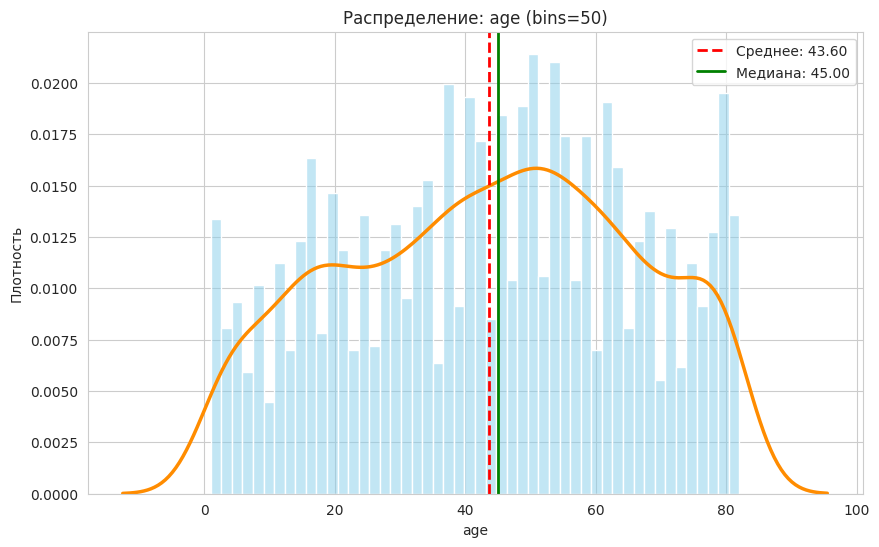

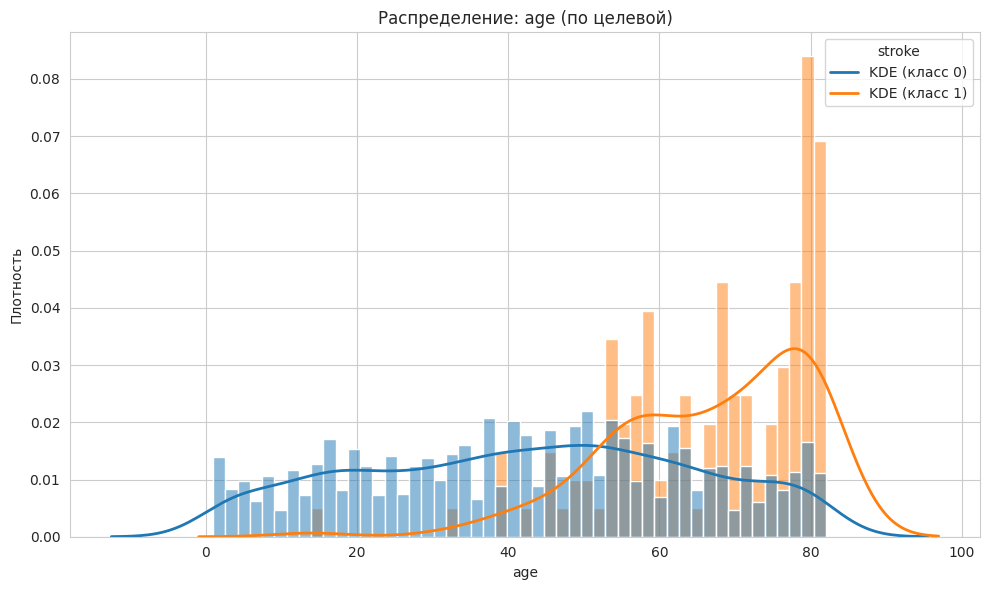


  📊 [2/3] avg_glucose_level


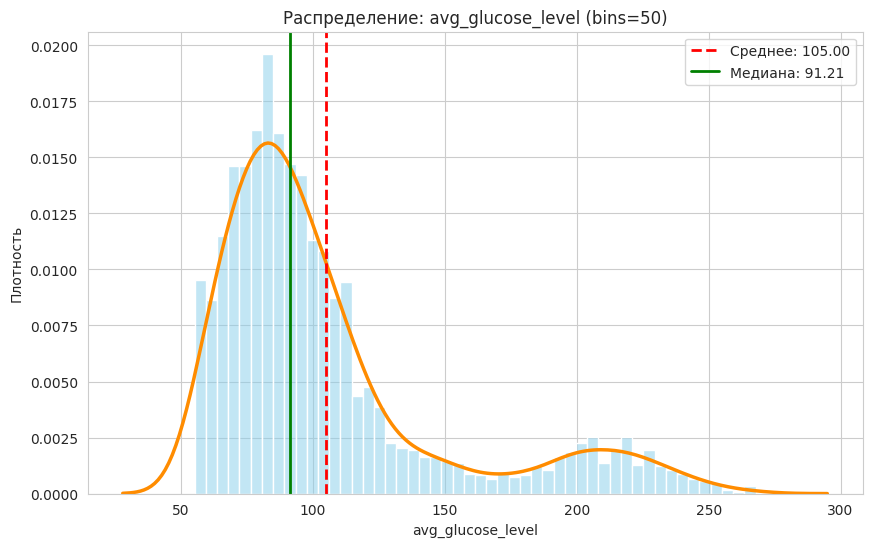

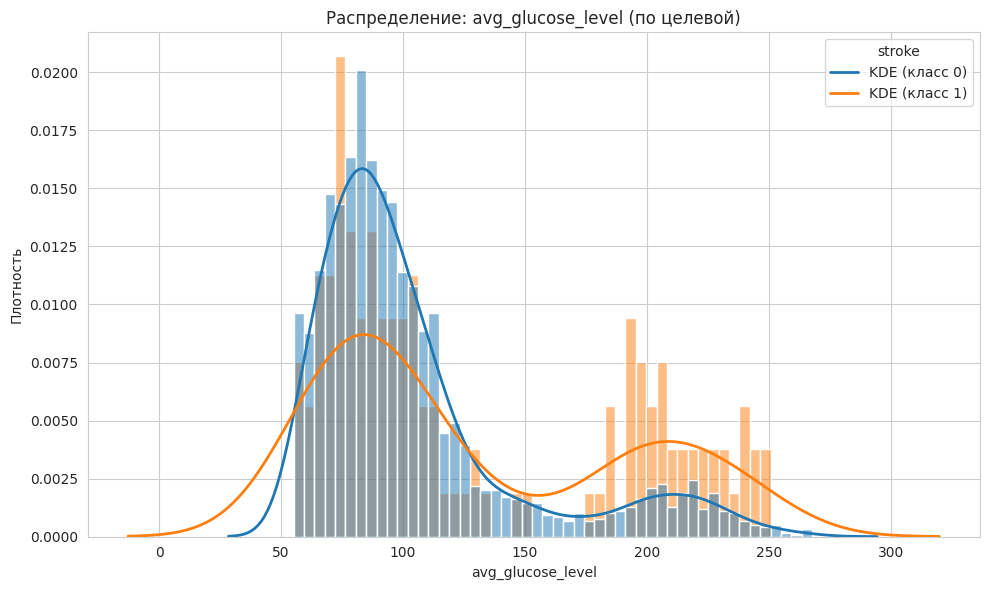


  📊 [3/3] bmi


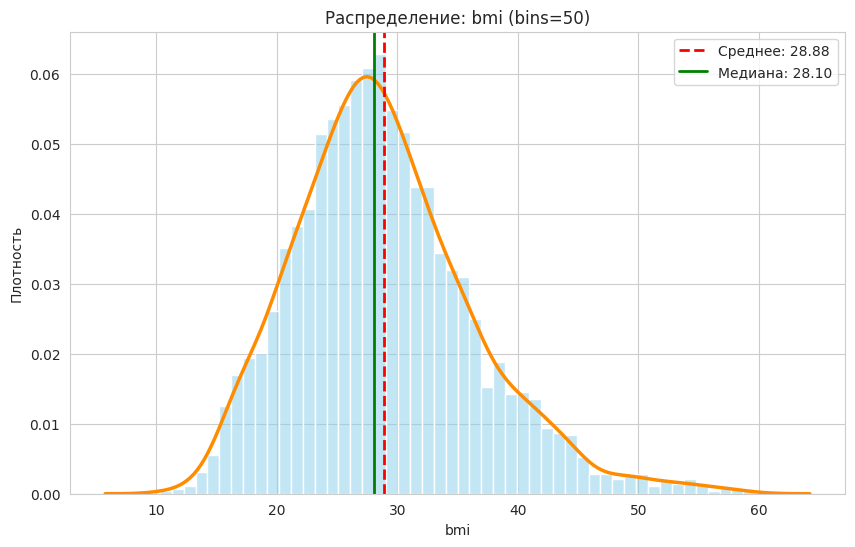

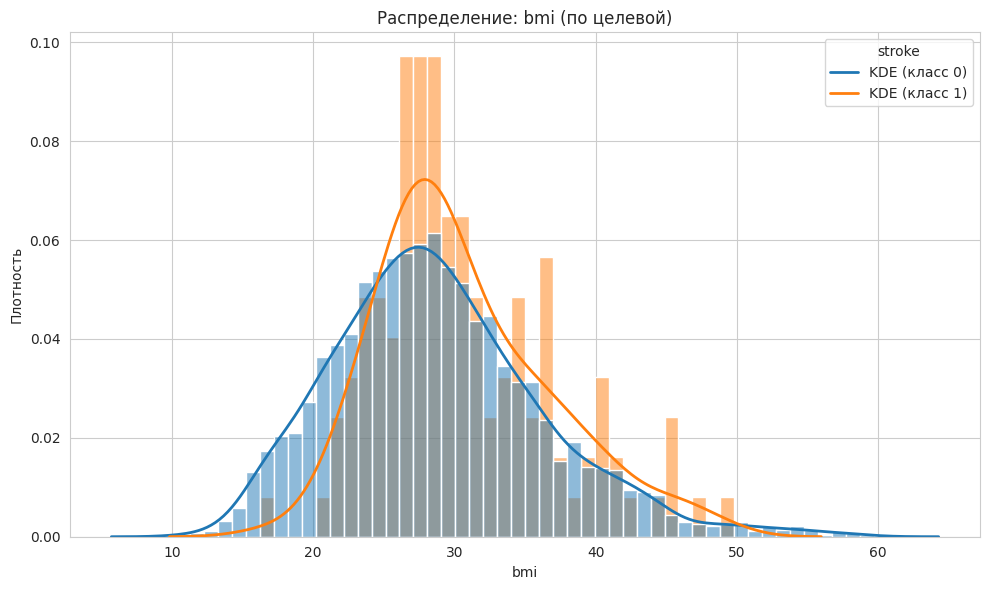


✅ Графики сохранены в: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots

✓ Визуализация числовых признаков завершена



In [12]:
# 2.4 ВИЗУАЛИЗАЦИЯ ЧИСЛОВЫХ КОЛОНОК (непрерывные)

print("\n" + "="*50)
print("📊 ВИЗУАЛИЗАЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Рекомендация по bins
    auto_bins = int(np.sqrt(len(X_train)))
    print(f"\n📐 AUTO_BINS: {auto_bins} (√{len(X_train)})")
    print(f"🔧 Используется BINS: {BINS}")

    # Определяем непрерывные колонки
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()
    continuous_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]

    if len(continuous_cols) == 0:
        print("\n⚠️ Нет непрерывных числовых колонок для визуализации")
    else:
        print(f"\n📌 Непрерывные признаки ({len(continuous_cols)}): {continuous_cols}")
        print(f"\n💾 Графики сохраняются в: {PLOTS_PATH}")

        for i, col in enumerate(continuous_cols, 1):
            mean_val = X_train[col].mean()
            median_val = X_train[col].median()

            print(f"\n  📊 [{i}/{len(continuous_cols)}] {col}")

            # --------------------------------------------
            # График 1: Общее распределение
            # --------------------------------------------
            plt.figure(figsize=(10, 6))

            sns.histplot(X_train[col], bins=BINS, color='skyblue', alpha=0.5, stat='density')
            sns.kdeplot(X_train[col], color='darkorange', linewidth=2.5)

            plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
            plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Медиана: {median_val:.2f}')

            plt.title(f'Распределение: {col} (bins={BINS})')
            plt.xlabel(col)
            plt.ylabel('Плотность')
            plt.legend()

            plot_path = os.path.join(PLOTS_PATH, f'distribution_{col}.png')
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.show()
            plt.close()

            # --------------------------------------------
            # График 2: С разделением по целевой
            # --------------------------------------------
            if HUE_BY_TARGET and TASK_TYPE == 'classification' and y_train is not None:
                plt.figure(figsize=(10, 6))

                plot_df = pd.DataFrame({col: X_train[col], TARGET_COLUMN: y_train})

                sns.histplot(data=plot_df, x=col, hue=TARGET_COLUMN, bins=BINS,
                            alpha=0.5, stat='density', common_norm=False)

                for target_val in y_train.unique():
                    subset = plot_df[plot_df[TARGET_COLUMN] == target_val]
                    if len(subset) > 1:
                        sns.kdeplot(data=subset, x=col, linewidth=2, label=f'KDE (класс {target_val})')

                plt.title(f'Распределение: {col} (по целевой)')
                plt.xlabel(col)
                plt.ylabel('Плотность')
                plt.legend(title=TARGET_COLUMN)
                plt.tight_layout()

                plot_path_hue = os.path.join(PLOTS_PATH, f'distribution_{col}_by_target.png')
                plt.savefig(plot_path_hue, dpi=150, bbox_inches='tight')
                plt.show()
                plt.close()

        print(f"\n✅ Графики сохранены в: {PLOTS_PATH}")

print("\n" + "="*50)
print("✓ Визуализация числовых признаков завершена")
print("="*50 + "\n")

# Viz label


🎯 ВИЗУАЛИЗАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

📊 Распределение классов:
   0:   2786 ( 95.7%)
   1:    125 (  4.3%)

⚠️ Дисбаланс классов: 22.3:1
   → RF_CLASS_WEIGHT = 'balanced' уже установлено


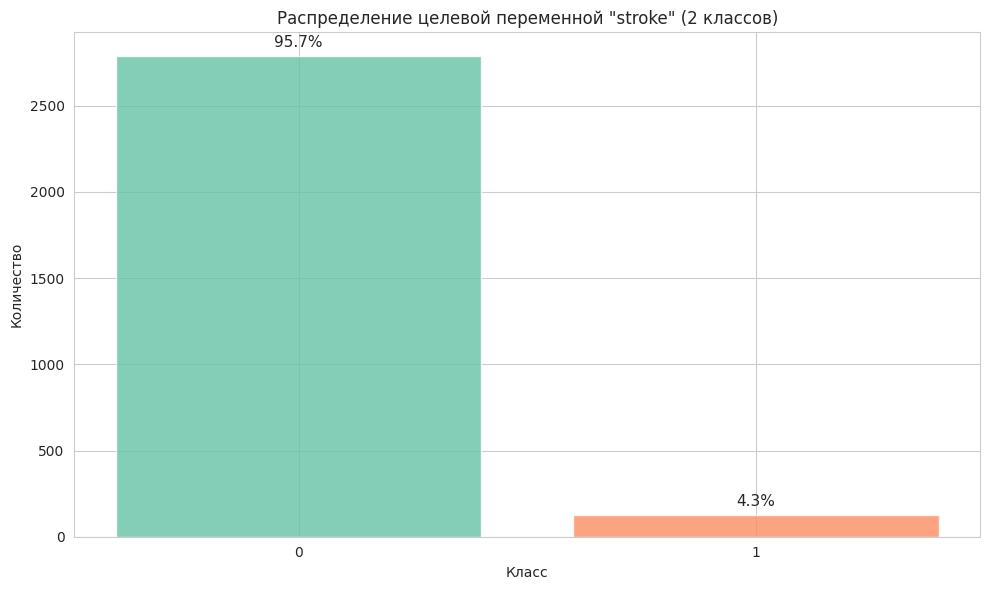


✅ График сохранён: plots/target_distribution.png

✓ Визуализация целевой переменной завершена



In [13]:
# 2.5 ВИЗУАЛИЗАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

print("\n" + "="*50)
print("🎯 ВИЗУАЛИЗАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*50)

if y_train is None:
    print("\n⚠️ y_train не загружен. Пропускаем.")
else:
    plt.figure(figsize=(10, 6))

    if TASK_TYPE == 'classification':
        # Для классификации — столбчатая диаграмма
        class_counts = y_train.value_counts()
        colors = plt.cm.Set2(range(len(class_counts)))

        bars = plt.bar(range(len(class_counts)), class_counts.values, color=colors, alpha=0.8)
        plt.xticks(range(len(class_counts)), class_counts.index)
        plt.title(f'Распределение целевой переменной "{TARGET_COLUMN}" ({len(class_counts)} классов)')
        plt.xlabel('Класс')
        plt.ylabel('Количество')

        # Подписи с процентами
        for i, (cls, count) in enumerate(class_counts.items()):
            percentage = count / len(y_train) * 100
            plt.text(i, count + max(class_counts.values) * 0.02,
                    f'{percentage:.1f}%', ha='center', fontsize=11)

        print("\n📊 Распределение классов:")
        for cls, count in class_counts.items():
            pct = count / len(y_train) * 100
            print(f"   {cls}: {count:>6} ({pct:>5.1f}%)")

        # Краткое напоминание о дисбалансе
        min_class_pct = class_counts.min() / len(y_train) * 100
        if min_class_pct < 10:
            imbalance_ratio = class_counts.max() / class_counts.min()
            print(f"\n⚠️ Дисбаланс классов: {imbalance_ratio:.1f}:1")
            print(f"   → RF_CLASS_WEIGHT = 'balanced' уже установлено")

    else:
        # Для регрессии — гистограмма + KDE + статистика
        mean_val = y_train.mean()
        median_val = y_train.median()

        print(f"\n📊 Статистика целевой переменной:")
        print(f"   Среднее: {mean_val:.2f}")
        print(f"   Медиана: {median_val:.2f}")
        print(f"   Мин: {y_train.min():.2f}")
        print(f"   Макс: {y_train.max():.2f}")
        print(f"   Станд. отклонение: {y_train.std():.2f}")

        # Гистограмма с KDE
        sns.histplot(y_train, bins=BINS, stat='density',
                    color='skyblue', alpha=0.5, label='Гистограмма')
        sns.kdeplot(y_train, color='darkorange', linewidth=2.5, label='KDE')

        # Линии среднего и медианы
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                   label=f'Среднее: {mean_val:.2f}')
        plt.axvline(median_val, color='green', linestyle='-', linewidth=2,
                   label=f'Медиана: {median_val:.2f}')

        plt.title(f'Распределение целевой переменной "{TARGET_COLUMN}" (регрессия)')
        plt.xlabel('Значение')
        plt.ylabel('Плотность')
        plt.legend()

    plt.tight_layout()
    plot_path = os.path.join(PLOTS_PATH, 'target_distribution.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✅ График сохранён: plots/target_distribution.png")

print("\n" + "="*50)
print("✓ Визуализация целевой переменной завершена")
print("="*50 + "\n")


🔘 АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ

📊 Найдено бинарных признаков: 2
   ['hypertension', 'heart_disease']

----------------------------------------
📌 hypertension
----------------------------------------

📊 Распределение:
   Нет (0): 2633 (90.5%)
   Да (1): 278 (9.5%)

📊 Связь с stroke:
   Нет (0): 3.5% класса 1
   Да (1): 12.2% класса 1


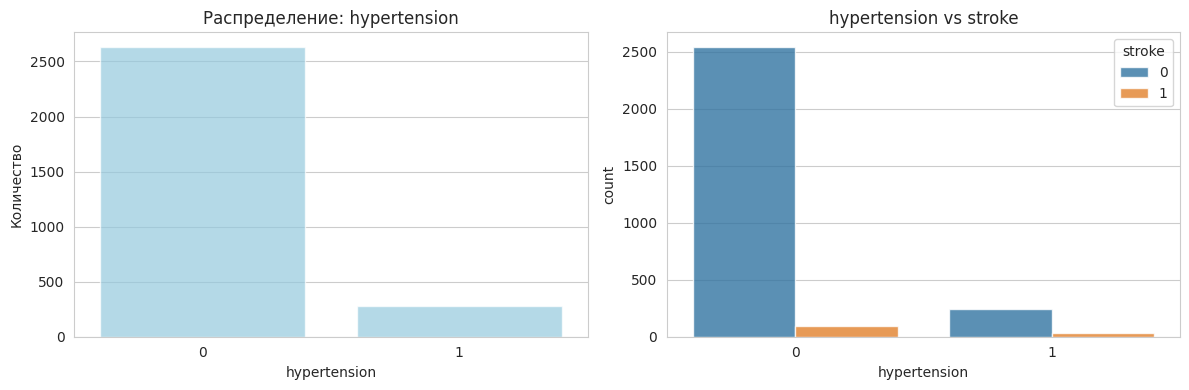


   ✓ График сохранён: plots/binary_hypertension.png

----------------------------------------
📌 heart_disease
----------------------------------------

📊 Распределение:
   Нет (0): 2766 (95.0%)
   Да (1): 145 (5.0%)

📊 Связь с stroke:
   Нет (0): 3.7% класса 1
   Да (1): 16.6% класса 1


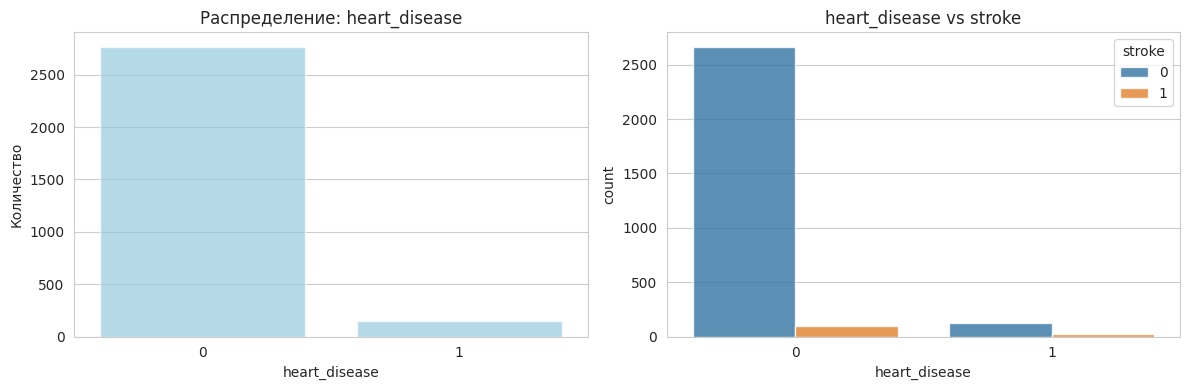


   ✓ График сохранён: plots/binary_heart_disease.png

📊 СВОДНАЯ ТАБЛИЦА БИНАРНЫХ ПРИЗНАКОВ


,Признак,% 1,stroke при 0,stroke при 1,Lift
0,hypertension,9.5%,3.5%,12.2%,🟢 3.5x
1,heart_disease,5.0%,3.7%,16.6%,🟢 4.5x



💡 Интерпретация Lift:
   🟢 >2.0x — сильное влияние
   🟡 1.5-2.0x — умеренное влияние
   🔴 <1.5x — слабое влияние

✓ Анализ бинарных признаков завершён



In [14]:
# 2.6 АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ

print("\n" + "="*50)
print("🔘 АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ")
print("="*50)

if X_train is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Находим бинарные колонки
    binary_cols = []
    for col in X_train.columns:
        if X_train[col].dtype in ['int64', 'Int64', 'float64', 'bool']:
            if X_train[col].nunique() <= 2:
                binary_cols.append(col)

    if len(binary_cols) == 0:
        print("\n⚠️ Бинарных признаков не обнаружено")
    else:
        print(f"\n📊 Найдено бинарных признаков: {len(binary_cols)}")
        print(f"   {binary_cols}")

        for col in binary_cols:
            print(f"\n" + "-"*40)
            print(f"📌 {col}")
            print("-"*40)

            # Распределение
            print(f"\n📊 Распределение:")
            value_counts = X_train[col].value_counts()
            for val, cnt in value_counts.items():
                pct = cnt / len(X_train) * 100
                val_name = "Да" if val == 1 else ("Нет" if val == 0 else str(val))
                print(f"   {val_name} ({val}): {cnt} ({pct:.1f}%)")

            # Связь с целевой
            if TASK_TYPE == 'classification':
                cross_tab = pd.crosstab(X_train[col], y_train, normalize='index') * 100
                print(f"\n📊 Связь с {TARGET_COLUMN}:")
                for idx in cross_tab.index:
                    val_name = "Да" if idx == 1 else ("Нет" if idx == 0 else str(idx))
                    if 1 in cross_tab.columns:
                        target_pct = cross_tab.loc[idx, 1]
                        print(f"   {val_name} ({idx}): {target_pct:.1f}% класса 1")
            else:
                # Для регрессии — среднее целевой
                print(f"\n📊 Связь с {TARGET_COLUMN} (среднее):")
                for val in value_counts.index:
                    subset = y_train[X_train[col] == val]
                    val_name = "Да" if val == 1 else ("Нет" if val == 0 else str(val))
                    print(f"   {val_name} ({val}): {subset.mean():.2f}")

            # Визуализация
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            # График 1: распределение
            sns.countplot(x=X_train[col], ax=axes[0], color='skyblue', alpha=0.7)
            axes[0].set_title(f'Распределение: {col}')
            axes[0].set_xlabel(col)
            axes[0].set_ylabel('Количество')

            # График 2: связь с целевой
            plot_df = pd.DataFrame({col: X_train[col], TARGET_COLUMN: y_train})
            if TASK_TYPE == 'classification':
                sns.countplot(data=plot_df, x=col, hue=TARGET_COLUMN, ax=axes[1], alpha=0.8)
            else:
                sns.boxplot(data=plot_df, x=col, y=TARGET_COLUMN, ax=axes[1])
            axes[1].set_title(f'{col} vs {TARGET_COLUMN}')
            axes[1].set_xlabel(col)
            axes[1].legend(title=TARGET_COLUMN) if TASK_TYPE == 'classification' else None

            plt.tight_layout()
            plot_path = os.path.join(PLOTS_PATH, f'binary_{col}.png')
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.show()
            print(f"\n   ✓ График сохранён: plots/binary_{col}.png")

        # Сводная таблица
        if TASK_TYPE == 'classification':
            print("\n" + "="*50)
            print("📊 СВОДНАЯ ТАБЛИЦА БИНАРНЫХ ПРИЗНАКОВ")
            print("="*50)

            summary_data = []
            for col in binary_cols:
                total_1 = (X_train[col] == 1).sum()
                pct_1 = total_1 / len(X_train) * 100
                target_rate_1 = y_train[X_train[col] == 1].mean() * 100 if total_1 > 0 else 0
                target_rate_0 = y_train[X_train[col] == 0].mean() * 100

                lift = target_rate_1 / target_rate_0 if target_rate_0 > 0 else float('inf')
                if lift > 2:
                    indicator = "🟢"
                elif lift > 1.5:
                    indicator = "🟡"
                else:
                    indicator = "🔴"

                summary_data.append({
                    'Признак': col,
                    '% 1': f'{pct_1:.1f}%',
                    f'{TARGET_COLUMN} при 0': f'{target_rate_0:.1f}%',
                    f'{TARGET_COLUMN} при 1': f'{target_rate_1:.1f}%',
                    'Lift': f'{indicator} {lift:.1f}x' if lift != float('inf') else '—'
                })

            summary_df = pd.DataFrame(summary_data)
            display(summary_df)

            print("\n💡 Интерпретация Lift:")
            print("   🟢 >2.0x — сильное влияние")
            print("   🟡 1.5-2.0x — умеренное влияние")
            print("   🔴 <1.5x — слабое влияние")

print("\n" + "="*50)
print("✓ Анализ бинарных признаков завершён")
print("="*50 + "\n")

# БЛОК 3. Пустоты

In [15]:
# 3.1 ПОИСК ВСЕХ ВИДОВ ПУСТОТ

print("\n" + "="*50)
print("🔍 ПОИСК ВСЕХ ВИДОВ ПУСТОТ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
    empty_info = {}
else:
    def find_all_empty(df, col):
        """Находит все виды пустот в колонке"""
        empty_mask = pd.Series(False, index=df.index)

        # 1. Стандартные NaN
        empty_mask = empty_mask | df[col].isna()

        # 2. Строковые маркеры
        if df[col].dtype == 'object':
            col_str = df[col].astype(str).str.lower()
            for marker in EMPTY_MARKERS_STR:
                empty_mask = empty_mask | (col_str == marker.lower())

        # 3. Числовые маркеры
        if pd.api.types.is_numeric_dtype(df[col]):
            for marker in EMPTY_MARKERS_NUM:
                empty_mask = empty_mask | (df[col] == marker)

        return empty_mask

    # Копия для анализа (оригинал не трогаем)
    X_train_analysis = X_train.copy()

    # Словарь для хранения информации
    empty_info = {}

    print("\n🔍 Поиск пустот в X_train:\n")

    for col in X_train_analysis.columns:
        empty_mask = find_all_empty(X_train_analysis, col)
        empty_count = empty_mask.sum()

        if empty_count > 0:
            # Определяем уровень проблемы
            pct = empty_count / len(X_train_analysis) * 100
            if pct > 60:
                level = "🔴"
            elif pct > 20:
                level = "🟠"
            elif pct > 5:
                level = "🟡"
            else:
                level = "🟢"

            empty_info[col] = {
                'count': empty_count,
                'percent': pct,
                'mask': empty_mask,
                'level': level
            }

            print(f"{level} {col}: {empty_count} ({pct:.1f}%)")

            # Примеры найденных значений
            empty_values = X_train_analysis.loc[empty_mask, col].unique()[:5].tolist()
            print(f"   Примеры: {empty_values}")

    # Сводная таблица
    if empty_info:
        print("\n" + "-"*50)
        print("📊 СВОДНАЯ ТАБЛИЦА ПУСТОТ:")
        print("-"*50)

        summary_data = []
        for col, info in empty_info.items():
            summary_data.append({
                'Колонка': col,
                'Пропусков': info['count'],
                'Процент': f"{info['percent']:.1f}%",
                'Уровень': info['level']
            })

        summary_df = pd.DataFrame(summary_data).sort_values('Пропусков', ascending=False)
        display(summary_df)
    else:
        print("\n✅ Пустот (включая скрытые) не обнаружено")

    # Проверка y_train (целевую НЕ копируем, только смотрим)
    print("\n" + "-"*50)
    print("🎯 ПРОВЕРКА y_train:")
    print("-"*50)

    y_empty_mask = find_all_empty(pd.DataFrame({'y': y_train}), 'y')
    y_empty_count = y_empty_mask.sum()

    if y_empty_count > 0:
        print(f"⚠️ В y_train найдено {y_empty_count} пустот")
        print(f"   Примеры: {y_train[y_empty_mask].head(5).tolist()}")
    else:
        print("✅ В y_train пустот не обнаружено")

    # Рекомендации
    if empty_info:
        print("\n📋 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ:")
        print("-"*50)

        for col, info in empty_info.items():
            pct = info['percent']
            level = info['level']

            if pct > 60:
                rec = "🗑️ УДАЛИТЬ колонку"
            elif pct > 20:
                rec = "⚠️ СОЗДАТЬ ФЛАГ + заполнить"
            elif pct > 5:
                rec = "📝 ЗАПОЛНИТЬ или создать флаг"
            else:
                rec = "✅ ЗАПОЛНИТЬ (мода/медиана)"

            print(f"   {level} {col}: {pct:.1f}% → {rec}")

print("\n" + "="*50)
print("✓ Поиск пустот завершён")
print("="*50 + "\n")


🔍 ПОИСК ВСЕХ ВИДОВ ПУСТОТ

🔍 Поиск пустот в X_train:

🟠 smoking_status: 832 (28.6%)
   Примеры: ['unknown']

--------------------------------------------------
📊 СВОДНАЯ ТАБЛИЦА ПУСТОТ:
--------------------------------------------------


,Колонка,Пропусков,Процент,Уровень
0,smoking_status,832,28.6%,🟠



--------------------------------------------------
🎯 ПРОВЕРКА y_train:
--------------------------------------------------
✅ В y_train пустот не обнаружено

📋 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ:
--------------------------------------------------
   🟠 smoking_status: 28.6% → ⚠️ СОЗДАТЬ ФЛАГ + заполнить

✓ Поиск пустот завершён



In [16]:
# 3.2 СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ

print("\n" + "="*50)
print("📋 СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    if missing_strategy:
        print("\n📊 Выбранные стратегии:\n")

        # Статистика по стратегиям
        strategy_counts = {}
        valid_cols = []
        invalid_cols = []

        for col, (strategy, param) in missing_strategy.items():
            if col in X_train.columns:
                valid_cols.append(col)
                strategy_counts[strategy] = strategy_counts.get(strategy, 0) + 1

                if param:
                    print(f"   • {col}: {strategy} (параметр: {param})")
                else:
                    print(f"   • {col}: {strategy}")
            else:
                invalid_cols.append(col)

        # Предупреждение о несуществующих колонках
        if invalid_cols:
            print(f"\n⚠️ Колонки не найдены в X_train: {invalid_cols}")

        # Сводка
        print(f"\n📊 Сводка по стратегиям:")
        for strategy, count in strategy_counts.items():
            print(f"   {strategy}: {count} колонок")

        # Проверка: есть ли колонки с пропусками без стратегии
        if empty_info:
            cols_with_empty = set(empty_info.keys())
            cols_with_strategy = set(valid_cols)
            missing_strategy_cols = cols_with_empty - cols_with_strategy

            if missing_strategy_cols:
                print(f"\n⚠️ Колонки с пропусками БЕЗ стратегии:")
                for col in missing_strategy_cols:
                    pct = empty_info[col]['percent']
                    print(f"   • {col}: {pct:.1f}% пропусков")
                print(f"\n💡 Добавьте их в missing_strategy в блоке 1.2")

    else:
        print("\n⚠️ Словарь missing_strategy пуст.")
        print("   Заполните его в блоке 1.2 на основе анализа:")

        if empty_info:
            print(f"\n   Найдено колонок с пропусками: {len(empty_info)}")
            for col, info in list(empty_info.items())[:5]:
                print(f"   • {col}: {info['percent']:.1f}%")
            if len(empty_info) > 5:
                print(f"   ... и ещё {len(empty_info) - 5}")

        print(f"\n   📝 Пример заполнения:")
        print(f"   missing_strategy = {{")
        if empty_info:
            first_col = list(empty_info.keys())[0]
            print(f"       '{first_col}': ('median', None),")
        print(f"       # 'колонка': ('стратегия', 'параметр')")
        print(f"   }}")

print("\n" + "="*50)
print("✓ Анализ стратегии завершён")
print("="*50 + "\n")


📋 СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ

📊 Выбранные стратегии:

   • smoking_status: constant (параметр: unknown)

📊 Сводка по стратегиям:
   constant: 1 колонок

✓ Анализ стратегии завершён



In [17]:
# 3.3 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ПРОПУСКОВ

print("\n" + "="*50)
print("🔧 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ПРОПУСКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
    X_train_clean = None
    flag_columns = []
else:
    # Создаём копию для очищенных данных
    X_train_clean = X_train.copy()
    flag_columns = []

    # Сначала заменяем скрытые пустоты на NaN (используем empty_info из блока 3.1)
    if empty_info:
        print("\n🔄 Замена скрытых пустот на NaN...")
        for col, info in empty_info.items():
            if col in X_train_clean.columns:
                X_train_clean.loc[info['mask'], col] = np.nan
                print(f"   ✓ {col}: {info['count']} значений → NaN")

    # Применяем стратегии
    if missing_strategy:
        print("\n📌 Применение стратегий:\n")

        for col, (strategy, param) in missing_strategy.items():
            if col not in X_train_clean.columns:
                print(f"⚠️ Колонка '{col}' не найдена, пропускаем")
                continue

            print(f"   📍 {col}: ", end="")

            if strategy == 'drop_column':
                X_train_clean.drop(columns=[col], inplace=True)
                print(f"колонка удалена")

            elif strategy == 'mode':
                mode_val = X_train_clean[col].mode()[0] if not X_train_clean[col].mode().empty else 'unknown'
                X_train_clean[col].fillna(mode_val, inplace=True)
                print(f"заполнено модой '{mode_val}'")

            elif strategy == 'median':
                median_val = X_train_clean[col].median()
                X_train_clean[col].fillna(median_val, inplace=True)
                print(f"заполнено медианой {median_val:.2f}")

            elif strategy == 'mean':
                mean_val = X_train_clean[col].mean()
                X_train_clean[col].fillna(mean_val, inplace=True)
                print(f"заполнено средним {mean_val:.2f}")

            elif strategy == 'constant':
                constant_val = param if param is not None else 'unknown'
                X_train_clean[col].fillna(constant_val, inplace=True)
                print(f"заполнено константой '{constant_val}'")

            elif strategy == 'flag':
                # Создаём флаг
                flag_col = f'{col}_missing_flag'
                X_train_clean[flag_col] = X_train_clean[col].isna().astype(int)
                flag_columns.append(flag_col)

                # Определяем значение для заполнения
                if param == 'mode':
                    fill_val = X_train_clean[col].mode()[0] if not X_train_clean[col].mode().empty else 'unknown'
                elif param == 'median':
                    fill_val = X_train_clean[col].median()
                elif param == 'mean':
                    fill_val = X_train_clean[col].mean()
                elif param is not None:
                    fill_val = param
                else:
                    fill_val = 'unknown'

                X_train_clean[col].fillna(fill_val, inplace=True)
                print(f"флаг {flag_col} + заполнено '{fill_val}'")

            else:
                print(f"⚠️ неизвестная стратегия '{strategy}'")

        print(f"\n✅ Обработка пропусков завершена")

        if flag_columns:
            print(f"   Созданы флаги: {', '.join(flag_columns)}")

        # Проверка результата
        remaining_nulls = X_train_clean.isnull().sum().sum()
        if remaining_nulls > 0:
            print(f"\n⚠️ Осталось пропусков: {remaining_nulls}")
            print("   Проверьте колонки без стратегии или скрытые пустоты")
        else:
            print(f"\n✓ Пропусков не осталось")

    else:
        print("\n⚠️ Словарь missing_strategy пуст, обработка не выполнена")

print("\n" + "="*50)
print("✓ Применение стратегий завершено")
print("="*50 + "\n")


🔧 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ПРОПУСКОВ

🔄 Замена скрытых пустот на NaN...
   ✓ smoking_status: 832 значений → NaN

📌 Применение стратегий:

   📍 smoking_status: заполнено константой 'unknown'

✅ Обработка пропусков завершена

✓ Пропусков не осталось

✓ Применение стратегий завершено



In [18]:
# 3.4 ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ ПРОПУСКОВ

print("\n" + "="*50)
print("✅ ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ")
print("="*50)

if 'X_train_clean' not in locals() or X_train_clean is None:
    print("\n⚠️ X_train_clean не найден. Выполните блок 3.3.")
else:
    # Сравнение с оригиналом
    print(f"\n📊 Сравнение с оригиналом:")
    print(f"   До:  {X_train.shape[0]} строк, {X_train.shape[1]} колонок")
    print(f"   После: {X_train_clean.shape[0]} строк, {X_train_clean.shape[1]} колонок")

    if X_train.shape[1] != X_train_clean.shape[1]:
        removed = set(X_train.columns) - set(X_train_clean.columns)
        added = set(X_train_clean.columns) - set(X_train.columns)
        if removed:
            print(f"   Удалены: {list(removed)}")
        if added:
            print(f"   Добавлены (флаги): {list(added)}")

    # Проверка оставшихся NaN
    remaining_nan = X_train_clean.isnull().sum().sum()

    if remaining_nan > 0:
        print(f"\n⚠️ Осталось NaN: {remaining_nan}")
        print("   Колонки с NaN:")
        missing_cols = X_train_clean.columns[X_train_clean.isnull().any()].tolist()
        for col in missing_cols:
            count = X_train_clean[col].isnull().sum()
            pct = count / len(X_train_clean) * 100
            print(f"      • {col}: {count} ({pct:.1f}%)")
    else:
        print(f"\n✅ NaN не осталось")

    # Проверка скрытых пустот (быстрая)
    hidden_empty_found = False
    for col in X_train_clean.select_dtypes(include=['object']).columns:
        col_str = X_train_clean[col].astype(str).str.lower()
        for marker in EMPTY_MARKERS_STR[:3]:  # проверяем основные
            if (col_str == marker).any():
                count = (col_str == marker).sum()
                print(f"\n⚠️ Найдены скрытые пустоты: {col} содержит '{marker}' ({count} раз)")
                hidden_empty_found = True
                break

    if not hidden_empty_found and remaining_nan == 0:
        print(f"\n🎉 Данные полностью очищены от пропусков!")

    # Информация о флагах
    if 'flag_columns' in globals() and flag_columns:
        print(f"\n🚩 Созданные флаги пропусков:")
        for flag in flag_columns:
            ones = X_train_clean[flag].sum()
            pct = ones / len(X_train_clean) * 100
            print(f"   • {flag}: {ones} единиц ({pct:.1f}%)")

print("\n" + "="*50)
print("✓ Проверка завершена")
print("="*50 + "\n")


✅ ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ

📊 Сравнение с оригиналом:
   До:  2911 строк, 10 колонок
   После: 2911 строк, 10 колонок

✅ NaN не осталось

🎉 Данные полностью очищены от пропусков!

✓ Проверка завершена



In [19]:
# 3.5 СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ

print("\n" + "="*50)
print("💾 СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ")
print("="*50)

if 'X_train_clean' not in locals() or X_train_clean is None:
    print("\n⚠️ X_train_clean не найден. Выполните блоки 3.3 и 3.4.")
else:
    # Сохраняем в checkpoints
    cleaned_path = os.path.join(CHECKPOINT_PATH, '03_missing_handled.csv')
    X_train_clean.to_csv(cleaned_path, index=False)

    print(f"\n✓ Сохранено: checkpoints/03_missing_handled.csv")
    print(f"   Размер: {X_train_clean.shape[0]} строк, {X_train_clean.shape[1]} колонок")

    # Сводка изменений
    print(f"\n📊 Изменения:")
    print(f"   Колонок было: {X_train.shape[1]}")
    print(f"   Колонок стало: {X_train_clean.shape[1]}")

    removed = set(X_train.columns) - set(X_train_clean.columns)
    added = set(X_train_clean.columns) - set(X_train.columns)

    if removed:
        print(f"   Удалены: {list(removed)}")
    if added:
        print(f"   Добавлены (флаги): {list(added)}")

    # Обновляем X_train для следующих блоков
    X_train = X_train_clean.copy()
    print(f"\n✓ X_train обновлён для следующих блоков")

    # Сохраняем информацию о стратегиях
    if missing_strategy:
        strategy_log_path = os.path.join(CHECKPOINT_PATH, '03_missing_strategy.json')
        strategy_log = {
            'applied_strategies': {k: [v[0], v[1]] for k, v in missing_strategy.items()},
            'flag_columns': flag_columns if 'flag_columns' in globals() else [],
            'removed_columns': list(removed) if removed else [],
            'date_processed': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        with open(strategy_log_path, 'w', encoding='utf-8') as f:
            json.dump(strategy_log, f, indent=2, ensure_ascii=False)
        print(f"✓ Лог стратегий сохранён: checkpoints/03_missing_strategy.json")

print("\n" + "="*50)
print("✓ Сохранение завершено")
print("="*50 + "\n")


💾 СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ

✓ Сохранено: checkpoints/03_missing_handled.csv
   Размер: 2911 строк, 10 колонок

📊 Изменения:
   Колонок было: 10
   Колонок стало: 10

✓ X_train обновлён для следующих блоков
✓ Лог стратегий сохранён: checkpoints/03_missing_strategy.json

✓ Сохранение завершено



# БЛОК 4. Выбросы


📊 ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)

📊 Все числовые колонки: 5
   Бинарные (исключены): ['hypertension', 'heart_disease']
   Непрерывные (анализ): ['age', 'avg_glucose_level', 'bmi']

💾 Сохраняем графики в: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots
   ✓ boxplot_age.png
   ✓ boxplot_avg_glucose_level.png
   ✓ boxplot_bmi.png


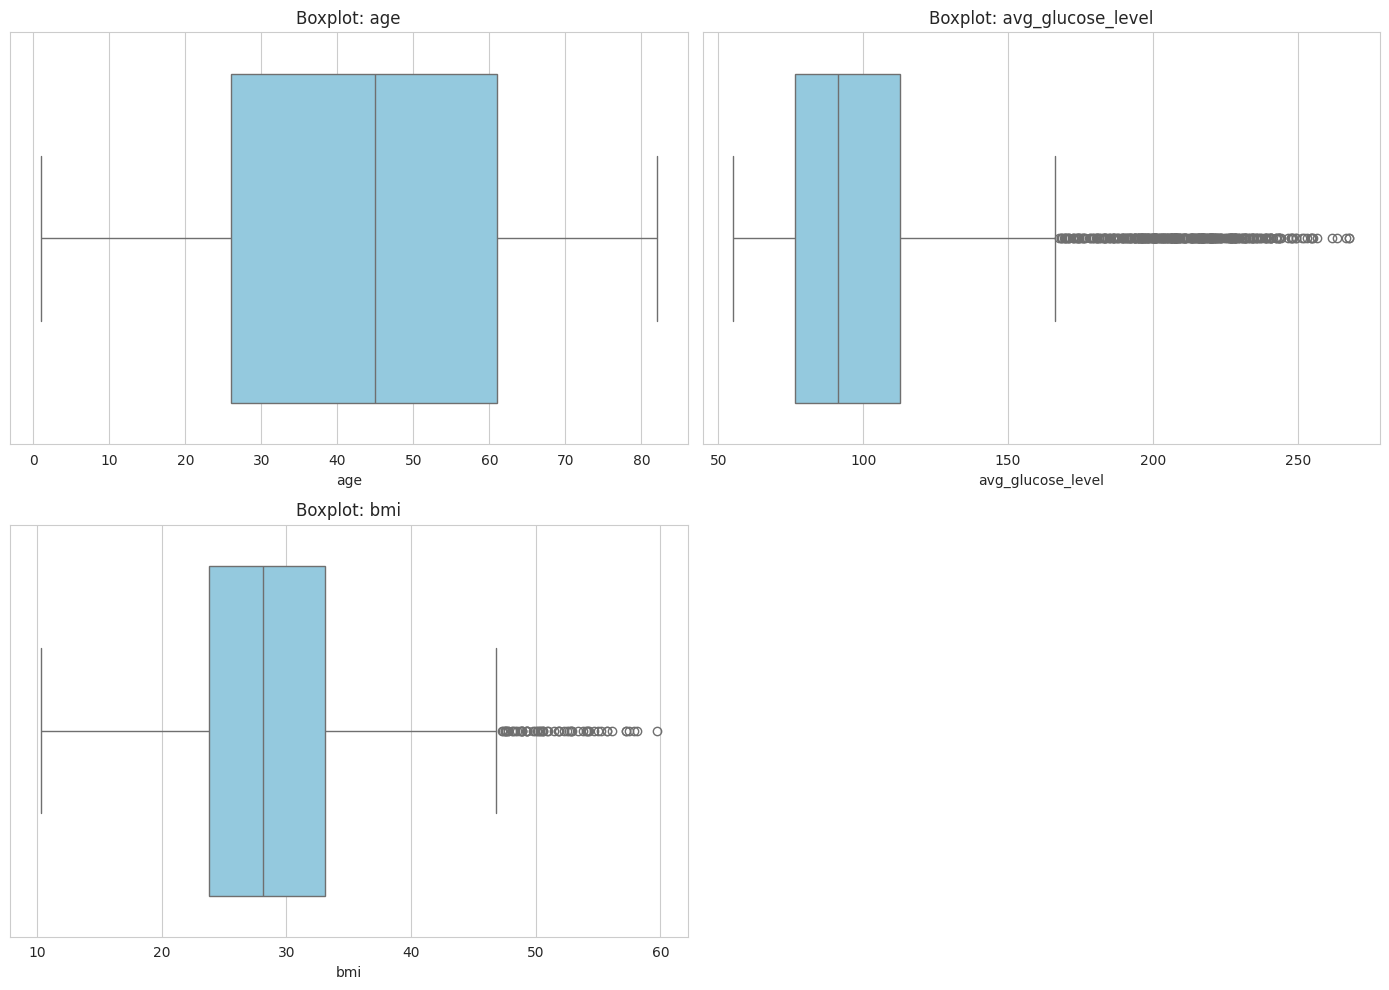


✅ Графики сохранены:
   • all_boxplots.png (все вместе)
   • boxplot_[col].png (по отдельности)
   • boxplot_[col]_by_target.png (с разделением по целевой)

✓ Визуализация выбросов завершена



In [20]:
# 4.1 ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)

print("\n" + "="*50)
print("📊 ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Определяем числовые колонки
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()

    # Исключаем бинарные
    binary_cols = [col for col in numeric_cols if X_train[col].nunique() <= 2]
    continuous_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]

    print(f"\n📊 Все числовые колонки: {len(numeric_cols)}")
    print(f"   Бинарные (исключены): {binary_cols if binary_cols else 'нет'}")
    print(f"   Непрерывные (анализ): {continuous_cols if continuous_cols else 'нет'}")

    if len(continuous_cols) == 0:
        print("\n⚠️ Нет непрерывных колонок для анализа выбросов")
    else:
        print(f"\n💾 Сохраняем графики в: {PLOTS_PATH}")

        # Сетка графиков
        n_cols = len(continuous_cols)
        n_rows = (n_cols + 1) // 2

        fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
        axes = axes.flatten() if n_cols > 1 else [axes]

        for i, col in enumerate(continuous_cols):
            # Boxplot
            sns.boxplot(x=X_train[col], ax=axes[i], color='skyblue')
            axes[i].set_title(f'Boxplot: {col}')
            axes[i].set_xlabel(col)

            # Сохраняем отдельный график
            plt.figure(figsize=(10, 4))
            sns.boxplot(x=X_train[col], color='skyblue')
            plt.title(f'Boxplot: {col}')
            plt.xlabel(col)

            plot_path = os.path.join(PLOTS_PATH, f'boxplot_{col}.png')
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f"   ✓ boxplot_{col}.png")

            # Дополнительно: boxplot с hue по целевой (для классификации)
            if HUE_BY_TARGET and TASK_TYPE == 'classification' and y_train is not None:
                plt.figure(figsize=(10, 4))
                plot_df = pd.DataFrame({col: X_train[col], TARGET_COLUMN: y_train})
                sns.boxplot(data=plot_df, x=TARGET_COLUMN, y=col, palette='Set2')
                plt.title(f'Boxplot: {col} vs {TARGET_COLUMN}')

                hue_path = os.path.join(PLOTS_PATH, f'boxplot_{col}_by_target.png')
                plt.savefig(hue_path, dpi=150, bbox_inches='tight')
                plt.close()

        # Скрываем пустые подграфики
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        all_path = os.path.join(PLOTS_PATH, 'all_boxplots.png')
        plt.savefig(all_path, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\n✅ Графики сохранены:")
        print(f"   • all_boxplots.png (все вместе)")
        print(f"   • boxplot_[col].png (по отдельности)")
        if HUE_BY_TARGET and TASK_TYPE == 'classification':
            print(f"   • boxplot_[col]_by_target.png (с разделением по целевой)")

print("\n" + "="*50)
print("✓ Визуализация выбросов завершена")
print("="*50 + "\n")

In [21]:
# 4.2 СТАТИСТИКА ВЫБРОСОВ ПО МЕТОДУ IQR

print("\n" + "="*50)
print("📐 СТАТИСТИКА ВЫБРОСОВ (МЕТОД IQR)")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Выбираем непрерывные числовые колонки
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()
    continuous_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]

    if len(continuous_cols) == 0:
        print("\n⚠️ Нет непрерывных числовых колонок для анализа выбросов")
    else:
        print(f"\n📊 Анализируемые колонки: {continuous_cols}")
        print(f"\n🔍 Метод: Q1 - 1.5×IQR / Q3 + 1.5×IQR\n")

        outliers_info = []

        for col in continuous_cols:
            Q1 = X_train[col].quantile(0.25)
            Q3 = X_train[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers_lower = X_train[X_train[col] < lower_bound][col]
            outliers_upper = X_train[X_train[col] > upper_bound][col]

            total_outliers = len(outliers_lower) + len(outliers_upper)
            outlier_percent = total_outliers / len(X_train) * 100

            # Определяем уровень
            if outlier_percent == 0:
                level = "🟢"
            elif outlier_percent < 5:
                level = "🟢"
            elif outlier_percent < 10:
                level = "🟡"
            else:
                level = "🔴"

            outliers_info.append({
                'Колонка': col,
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'Нижняя': lower_bound,
                'Верхняя': upper_bound,
                'Выбросов': total_outliers,
                '%': outlier_percent,
                'Уровень': level
            })

            print(f"{level} {col}:")
            print(f"   Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
            print(f"   Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
            print(f"   Выбросов: {total_outliers} ({outlier_percent:.1f}%)")

            if total_outliers > 0:
                if len(outliers_lower) > 0:
                    print(f"   Низкие: {outliers_lower.head(3).tolist()}")
                if len(outliers_upper) > 0:
                    print(f"   Высокие: {outliers_upper.head(3).tolist()}")
            print()

        # Сводная таблица
        print("\n" + "-"*60)
        print("📊 СВОДНАЯ ТАБЛИЦА ВЫБРОСОВ:")
        print("-"*60)

        summary_data = []
        for info in outliers_info:
            summary_data.append({
                '': info['Уровень'],
                'Колонка': info['Колонка'],
                'Q1': f"{info['Q1']:.2f}",
                'Q3': f"{info['Q3']:.2f}",
                'IQR': f"{info['IQR']:.2f}",
                'Выбросов': info['Выбросов'],
                '%': f"{info['%']:.1f}%"
            })

        display(pd.DataFrame(summary_data))

        # Рекомендации
        print("\n💡 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ ВЫБРОСОВ:")
        print("-"*60)

        for info in outliers_info:
            col = info['Колонка']
            pct = info['%']

            if pct == 0:
                print(f"   🟢 {col}: выбросов нет — оставить как есть")
            elif pct < 5:
                print(f"   🟢 {col}: {pct:.1f}% — можно оставить")
            elif pct < 10:
                print(f"   🟡 {col}: {pct:.1f}% — рассмотреть clipping (cap)")
            else:
                print(f"   🔴 {col}: {pct:.1f}% — проверить данные, использовать RobustScaler или cap")

        # Подсказка для outliers_strategy
        print(f"\n📝 Пример для outliers_strategy (блок 1.2):")
        print(f"   outliers_strategy = {{")
        for info in outliers_info[:3]:
            if info['%'] > 5:
                print(f"       '{info['Колонка']}': ('cap', ({info['Нижняя']:.2f}, {info['Верхняя']:.2f})),")
            else:
                print(f"       '{info['Колонка']}': ('keep', None),")
        print(f"   }}")

print("\n" + "="*50)
print("✓ Анализ выбросов завершён")
print("="*50 + "\n")


📐 СТАТИСТИКА ВЫБРОСОВ (МЕТОД IQR)

📊 Анализируемые колонки: ['age', 'avg_glucose_level', 'bmi']

🔍 Метод: Q1 - 1.5×IQR / Q3 + 1.5×IQR

🟢 age:
   Q1=26.00, Q3=61.00, IQR=35.00
   Границы: [-26.50, 113.50]
   Выбросов: 0 (0.0%)

🔴 avg_glucose_level:
   Q1=76.35, Q3=112.80, IQR=36.45
   Границы: [21.67, 167.47]
   Выбросов: 347 (11.9%)
   Высокие: [217.39, 213.22, 210.23]

🟢 bmi:
   Q1=23.80, Q3=33.10, IQR=9.30
   Границы: [9.85, 47.05]
   Выбросов: 60 (2.1%)
   Высокие: [57.5, 50.6, 49.3]


------------------------------------------------------------
📊 СВОДНАЯ ТАБЛИЦА ВЫБРОСОВ:
------------------------------------------------------------


,,Колонка,Q1,Q3,IQR,Выбросов,%
0,🟢,age,26.00,61.00,35.00,0,0.0%
1,🔴,avg_glucose_level,76.35,112.80,36.45,347,11.9%
2,🟢,bmi,23.80,33.10,9.30,60,2.1%



💡 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ ВЫБРОСОВ:
------------------------------------------------------------
   🟢 age: выбросов нет — оставить как есть
   🔴 avg_glucose_level: 11.9% — проверить данные, использовать RobustScaler или cap
   🟢 bmi: 2.1% — можно оставить

📝 Пример для outliers_strategy (блок 1.2):
   outliers_strategy = {
       'age': ('keep', None),
       'avg_glucose_level': ('cap', (21.67, 167.47)),
       'bmi': ('keep', None),
   }

✓ Анализ выбросов завершён



In [22]:
# 4.3 СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ

print("\n" + "="*50)
print("📋 СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    if outliers_strategy:
        print("\n📊 Выбранные стратегии:\n")

        strategy_counts = {}
        valid_cols = []
        invalid_cols = []

        for col, (strategy, param) in outliers_strategy.items():
            if col in X_train.columns:
                valid_cols.append(col)
                strategy_counts[strategy] = strategy_counts.get(strategy, 0) + 1

                if param:
                    print(f"   • {col}: {strategy} (параметр: {param})")
                else:
                    print(f"   • {col}: {strategy}")
            else:
                invalid_cols.append(col)

        if invalid_cols:
            print(f"\n⚠️ Колонки не найдены в X_train: {invalid_cols}")

        # Сводка
        print(f"\n📊 Сводка по стратегиям:")
        for strategy, count in strategy_counts.items():
            if strategy == 'keep':
                desc = "оставить как есть"
            elif strategy == 'cap':
                desc = "обрезать по границам"
            elif strategy == 'remove':
                desc = "удалить строки"
            elif strategy == 'log':
                desc = "логарифмировать"
            elif strategy == 'flag':
                desc = "создать флаг"
            else:
                desc = ""
            print(f"   {strategy}: {count} колонок — {desc}")

        # Проверка: есть ли колонки с выбросами без стратегии
        if 'outliers_info' in globals() and outliers_info:
            cols_with_outliers = set([info['Колонка'] for info in outliers_info if info['Выбросов'] > 0])
            cols_with_strategy = set(valid_cols)
            missing_strategy_cols = cols_with_outliers - cols_with_strategy

            if missing_strategy_cols:
                print(f"\n⚠️ Колонки с выбросами БЕЗ стратегии:")
                for col in missing_strategy_cols:
                    info = next((x for x in outliers_info if x['Колонка'] == col), None)
                    if info:
                        print(f"   • {col}: {info['Выбросов']} выбросов ({info['%']:.1f}%)")
                print(f"\n💡 Добавьте их в outliers_strategy в блоке 1.2")

    else:
        print("\n⚠️ Словарь outliers_strategy пуст.")
        print("   Заполните его в блоке 1.2 на основе анализа:\n")

        if 'outliers_info' in globals() and outliers_info:
            print("   Найдены выбросы в колонках:")
            for info in outliers_info:
                if info['Выбросов'] > 0:
                    print(f"   • {info['Колонка']}: {info['Выбросов']} ({info['%']:.1f}%) — {info['Уровень']}")

        print(f"\n💡 Стратегии обработки:")
        print("   • keep   — оставить как есть (выбросы реальные)")
        print("   • cap    — обрезать по границам (винзоризация)")
        print("   • remove — удалить строки с выбросами")
        print("   • log    — логарифмическое преобразование")
        print("   • flag   — создать флаг выброса")

        print(f"\n📝 Пример заполнения:")
        print(f"   outliers_strategy = {{")
        print(f"       'avg_glucose_level': ('cap', (50, 250)),")
        print(f"       'bmi': ('log', None),")
        print(f"       'age': ('keep', None),")
        print(f"   }}")

print("\n" + "="*50)
print("✓ Анализ стратегии завершён")
print("="*50 + "\n")


📋 СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ

📊 Выбранные стратегии:

   • age: keep
   • avg_glucose_level: keep
   • bmi: keep

📊 Сводка по стратегиям:
   keep: 3 колонок — оставить как есть

✓ Анализ стратегии завершён



In [23]:
# 4.4 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ВЫБРОСОВ

print("\n" + "="*50)
print("🔧 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ВЫБРОСОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
    X_train_clean = None
    y_train_clean = None
    outlier_flags = []
else:
    # Копии для обработки
    X_train_clean = X_train.copy()
    y_train_clean = y_train.copy() if y_train is not None else None
    outlier_flags = []
    rows_to_remove = []

    if outliers_strategy:
        print("\n📌 Применение стратегий:\n")

        for col, (strategy, param) in outliers_strategy.items():
            if col not in X_train_clean.columns:
                print(f"⚠️ Колонка '{col}' не найдена, пропускаем")
                continue

            print(f"   📍 {col}: ", end="")

            # Вычисляем IQR-границы (если нужны)
            Q1 = X_train_clean[col].quantile(0.25)
            Q3 = X_train_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            if strategy == 'keep':
                print("оставлено без изменений")

            elif strategy == 'cap':
                # Если param задан как (min, max) — используем его
                if param and isinstance(param, (tuple, list)) and len(param) == 2:
                    cap_lower, cap_upper = param
                else:
                    cap_lower, cap_upper = lower_bound, upper_bound

                X_train_clean[col] = X_train_clean[col].clip(cap_lower, cap_upper)
                print(f"обрезано [{cap_lower:.2f}, {cap_upper:.2f}]")

            elif strategy == 'remove':
                outlier_mask = (X_train_clean[col] < lower_bound) | (X_train_clean[col] > upper_bound)
                outlier_indices = X_train_clean.index[outlier_mask].tolist()
                rows_to_remove.extend(outlier_indices)
                print(f"помечено {len(outlier_indices)} строк к удалению")

            elif strategy == 'log':
                if (X_train_clean[col] <= 0).any():
                    X_train_clean[col] = np.log1p(X_train_clean[col])
                    print("log1p (x+1)")
                else:
                    X_train_clean[col] = np.log(X_train_clean[col])
                    print("log")

            elif strategy == 'flag':
                flag_col = f'{col}_outlier_flag'
                outlier_mask = (X_train_clean[col] < lower_bound) | (X_train_clean[col] > upper_bound)
                X_train_clean[flag_col] = outlier_mask.astype(int)
                outlier_flags.append(flag_col)
                print(f"флаг {flag_col} ({outlier_mask.sum()} выбросов)")

            else:
                print(f"⚠️ неизвестная стратегия '{strategy}'")

        # Удаляем строки с выбросами (синхронно из X и y)
        if rows_to_remove:
            rows_to_remove = list(set(rows_to_remove))
            X_train_clean = X_train_clean.drop(index=rows_to_remove)
            if y_train_clean is not None:
                y_train_clean = y_train_clean.drop(index=rows_to_remove)

            print(f"\n🗑️ Удалено строк с выбросами: {len(rows_to_remove)}")
            print(f"   Новая форма: {X_train_clean.shape}")

            # Сброс индекса
            X_train_clean.reset_index(drop=True, inplace=True)
            if y_train_clean is not None:
                y_train_clean.reset_index(drop=True, inplace=True)

        print(f"\n✅ Обработка выбросов завершена")
        if outlier_flags:
            print(f"   Созданы флаги: {', '.join(outlier_flags)}")

    else:
        print("\n⚠️ Словарь outliers_strategy пуст, обработка не выполнена")

print("\n" + "="*50)
print("✓ Применение стратегий завершено")
print("="*50 + "\n")


🔧 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ВЫБРОСОВ

📌 Применение стратегий:

   📍 age: оставлено без изменений
   📍 avg_glucose_level: оставлено без изменений
   📍 bmi: оставлено без изменений

✅ Обработка выбросов завершена

✓ Применение стратегий завершено



In [24]:
# 4.5 ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ ВЫБРОСОВ

print("\n" + "="*50)
print("✅ ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ ВЫБРОСОВ")
print("="*50)

if 'X_train_clean' not in locals() or X_train_clean is None:
    print("\n⚠️ X_train_clean не найден. Выполните блок 4.4.")
else:
    # Сравнение с оригиналом
    print(f"\n📊 Сравнение с оригиналом:")
    print(f"   До:  {X_train.shape[0]} строк, {X_train.shape[1]} колонок")
    print(f"   После: {X_train_clean.shape[0]} строк, {X_train_clean.shape[1]} колонок")

    if X_train.shape[0] != X_train_clean.shape[0]:
        removed_rows = X_train.shape[0] - X_train_clean.shape[0]
        print(f"   🗑️ Удалено строк: {removed_rows} ({removed_rows/X_train.shape[0]*100:.1f}%)")

    if X_train.shape[1] != X_train_clean.shape[1]:
        added_cols = set(X_train_clean.columns) - set(X_train.columns)
        if added_cols:
            print(f"   🚩 Добавлены флаги: {list(added_cols)}")

    # Проверка синхронизации с y_train
    if 'y_train_clean' in locals() and y_train_clean is not None:
        if len(X_train_clean) == len(y_train_clean):
            print(f"   ✓ y_train синхронизирован ({len(y_train_clean)} значений)")
        else:
            print(f"   ⚠️ X_train и y_train не совпадают! {len(X_train_clean)} vs {len(y_train_clean)}")

    # Проверка оставшихся выбросов
    print(f"\n🔍 Проверка оставшихся выбросов:")

    numeric_cols = X_train_clean.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()
    continuous_cols = [col for col in numeric_cols if X_train_clean[col].nunique() > 2]

    if continuous_cols:
        remaining_outliers = []

        for col in continuous_cols:
            Q1 = X_train_clean[col].quantile(0.25)
            Q3 = X_train_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers_lower = (X_train_clean[col] < lower_bound).sum()
            outliers_upper = (X_train_clean[col] > upper_bound).sum()
            total = outliers_lower + outliers_upper

            if total > 0:
                remaining_outliers.append((col, total))

        if remaining_outliers:
            print(f"\n   ⚠️ Остались выбросы:")
            for col, count in remaining_outliers:
                print(f"      • {col}: {count}")
            print(f"\n   💡 Эти колонки не были обработаны (стратегия 'keep' или не указаны)")
        else:
            print(f"\n   ✅ Выбросов не осталось (в обработанных колонках)")
    else:
        print(f"\n   ℹ️ Нет непрерывных колонок для проверки")

    # Информация о флагах
    if 'outlier_flags' in globals() and outlier_flags:
        print(f"\n🚩 Созданные флаги выбросов:")
        for flag in outlier_flags:
            if flag in X_train_clean.columns:
                ones = X_train_clean[flag].sum()
                pct = ones / len(X_train_clean) * 100
                print(f"   • {flag}: {ones} ({pct:.1f}%)")

print("\n" + "="*50)
print("✓ Проверка завершена")
print("="*50 + "\n")


✅ ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ ВЫБРОСОВ

📊 Сравнение с оригиналом:
   До:  2911 строк, 10 колонок
   После: 2911 строк, 10 колонок
   ✓ y_train синхронизирован (2911 значений)

🔍 Проверка оставшихся выбросов:

   ⚠️ Остались выбросы:
      • avg_glucose_level: 347
      • bmi: 60

   💡 Эти колонки не были обработаны (стратегия 'keep' или не указаны)

✓ Проверка завершена



In [25]:
# 4.6 СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ (ПОСЛЕ ВЫБРОСОВ)

print("\n" + "="*50)
print("💾 СОХРАНЕНИЕ ДАННЫХ ПОСЛЕ ОБРАБОТКИ ВЫБРОСОВ")
print("="*50)

if 'X_train_clean' not in locals() or X_train_clean is None:
    print("\n⚠️ X_train_clean не найден. Выполните блоки 4.4 и 4.5.")
else:
    # Сохраняем X_train_clean
    cleaned_x_path = os.path.join(CHECKPOINT_PATH, '04_outliers_handled_X.csv')
    X_train_clean.to_csv(cleaned_x_path, index=False)

    print(f"\n✓ X_train сохранён: checkpoints/04_outliers_handled_X.csv")
    print(f"   Размер: {X_train_clean.shape[0]} строк, {X_train_clean.shape[1]} колонок")

    # Сохраняем y_train_clean (если был изменён)
    if 'y_train_clean' in locals() and y_train_clean is not None:
        cleaned_y_path = os.path.join(CHECKPOINT_PATH, '04_outliers_handled_y.csv')
        y_train_clean.to_csv(cleaned_y_path, index=False, header=True)
        print(f"✓ y_train сохранён: checkpoints/04_outliers_handled_y.csv")
        print(f"   Размер: {len(y_train_clean)} значений")

    # Сводка изменений
    print(f"\n📊 Изменения:")
    print(f"   Строк было: {X_train.shape[0]}")
    print(f"   Строк стало: {X_train_clean.shape[0]}")

    if X_train.shape[0] != X_train_clean.shape[0]:
        removed = X_train.shape[0] - X_train_clean.shape[0]
        print(f"   Удалено строк: {removed} ({removed/X_train.shape[0]*100:.1f}%)")

    if X_train.shape[1] != X_train_clean.shape[1]:
        added = set(X_train_clean.columns) - set(X_train.columns)
        if added:
            print(f"   Добавлены флаги: {list(added)}")

    # Обновляем X_train и y_train для следующих блоков
    X_train = X_train_clean.copy()
    if 'y_train_clean' in locals() and y_train_clean is not None:
        y_train = y_train_clean.copy()
        print(f"\n✓ X_train и y_train обновлены для следующих блоков")
    else:
        print(f"\n✓ X_train обновлён для следующих блоков")

    # Сохраняем лог стратегий
    if outliers_strategy:
        strategy_log_path = os.path.join(CHECKPOINT_PATH, '04_outliers_strategy.json')
        strategy_log = {
            'applied_strategies': {k: [v[0], v[1]] for k, v in outliers_strategy.items()},
            'outlier_flags': outlier_flags if 'outlier_flags' in globals() else [],
            'rows_removed': X_train.shape[0] - X_train_clean.shape[0] if X_train.shape[0] != X_train_clean.shape[0] else 0,
            'date_processed': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        with open(strategy_log_path, 'w', encoding='utf-8') as f:
            json.dump(strategy_log, f, indent=2, ensure_ascii=False)
        print(f"✓ Лог стратегий сохранён: checkpoints/04_outliers_strategy.json")

print("\n" + "="*50)
print("✓ Сохранение завершено")
print("="*50 + "\n")


💾 СОХРАНЕНИЕ ДАННЫХ ПОСЛЕ ОБРАБОТКИ ВЫБРОСОВ

✓ X_train сохранён: checkpoints/04_outliers_handled_X.csv
   Размер: 2911 строк, 10 колонок
✓ y_train сохранён: checkpoints/04_outliers_handled_y.csv
   Размер: 2911 значений

📊 Изменения:
   Строк было: 2911
   Строк стало: 2911

✓ X_train и y_train обновлены для следующих блоков
✓ Лог стратегий сохранён: checkpoints/04_outliers_strategy.json

✓ Сохранение завершено



# БЛОК 5. Feature Engineering

In [26]:
# 5.1 СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ (FEATURE ENGINEERING)

print("\n" + "="*50)
print("🔧 СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    print("\n💡 ВНИМАНИЕ: Этот блок нужно переписать под конкретный датасет!")
    print("   Ниже приведён ПРИМЕР для Stroke Prediction.\n")
    print("   📝 Зафиксируй новые признаки в блоке 1.2: NEW_FEATURES = []!")
    print()

    # ============================================
    # ЗДЕСЬ ПИШЕМ КОД ДЛЯ КОНКРЕТНОГО ДАТАСЕТА
    # ============================================

    # Пример 1: Гипертония ИЛИ Сердечные заболевания
    X_train['cardio_risk'] = ((X_train['hypertension'] == 1) | (X_train['heart_disease'] == 1)).astype(int)
    print("✓ cardio_risk = hypertension OR heart_disease")

    # Пример 2.1: Старше 60 и 3 вида работ
    X_train['senior_work'] = (
        (X_train['age'] > 60) &
        (X_train['work_type'].isin(['self-employed', 'private', 'govt_job']))
    ).astype(int)
    print("✓ senior_work = (age > 60) AND (3 вида work)")

    # Пример 2.2: Старше 60 и 2 вида работ
    X_train['senior_work_2'] = (
        (X_train['age'] > 60) &
        (X_train['work_type'].isin(['self-employed', 'private']))
    ).astype(int)
    print("✓ senior_work_2 = (age > 60) AND (2 вида work)")

    # Пример 2.3: Старше 60 и 2 вида работ
    X_train['senior_work_1'] = (
        (X_train['age'] > 60) &
        (X_train['work_type'].isin(['self-employed']))
    ).astype(int)
    print("✓ senior_work_1 = (age > 60) AND (1 вид work)")

    # Пример 3: 3 группы: младше 60, сташе 60 женатые, старше 60 неженатые
    def get_marriage_risk(row):
        if row['age'] <= 60:
            return 'young'
        elif row['ever_married'] == 'yes':
            return 'senior_married'
        else:
            return 'senior_unmarried'

    X_train['marriage_risk'] = X_train.apply(get_marriage_risk, axis=1)
    print("✓ marriage_risk = young / senior_married / senior_unmarried")

    # ============================================
    # КОНЕЦ КАСТОМНОГО КОДА
    # ============================================

    # Зафиксируй новые признаки в блоке 1.2 NEW_FEATURES = []!

    print(f"\n📊 Создано признаков: {len(NEW_FEATURES)}")
    print(f"   {NEW_FEATURES}")

    # Проверяем, что все созданные признаки существуют
    missing = [f for f in NEW_FEATURES if f not in X_train.columns]
    if missing:
        print(f"\n⚠️ Не найдены: {missing}")

    print("\n💡 ПОДСКАЗКИ ДЛЯ FEATURE ENGINEERING:")
    print("   • Комбинируйте существующие признаки (+, -, *, /, AND, OR)")
    print("   • Создавайте флаги на основе порогов (age > 60)")
    print("   • Группируйте редкие категории в 'other'")
    print("   • Извлекайте компоненты из дат (год, месяц, день недели)")
    print("   • Используйте агрегаты по группам (средний чек по городу)")
    print("   • Создавайте признаки взаимодействия (A * B)")

print("\n" + "="*50)
print("✓ Feature engineering завершён")
print("="*50 + "\n")


🔧 СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ

💡 ВНИМАНИЕ: Этот блок нужно переписать под конкретный датасет!
   Ниже приведён ПРИМЕР для Stroke Prediction.

   📝 Зафиксируй новые признаки в блоке 1.2: NEW_FEATURES = []!

✓ cardio_risk = hypertension OR heart_disease
✓ senior_work = (age > 60) AND (3 вида work)
✓ senior_work_2 = (age > 60) AND (2 вида work)
✓ senior_work_1 = (age > 60) AND (1 вид work)
✓ marriage_risk = young / senior_married / senior_unmarried

📊 Создано признаков: 5
   ['cardio_risk', 'senior_work', 'marriage_risk', 'senior_work_1', 'senior_work_2']

💡 ПОДСКАЗКИ ДЛЯ FEATURE ENGINEERING:
   • Комбинируйте существующие признаки (+, -, *, /, AND, OR)
   • Создавайте флаги на основе порогов (age > 60)
   • Группируйте редкие категории в 'other'
   • Извлекайте компоненты из дат (год, месяц, день недели)
   • Используйте агрегаты по группам (средний чек по городу)
   • Создавайте признаки взаимодействия (A * B)

✓ Feature engineering завершён



# Приложение. Анализ признаков

In [27]:
# Анализ ever_married
print("=== ever_married vs stroke ===")

# 1. Таблица с процентами
cross_tab = pd.crosstab(X_train['ever_married'], y_train, normalize='index') * 100
print("Распределение инсультов по marital status (%):")
print(cross_tab.round(1))

# 2. Повышение риска
risk_never = cross_tab.loc['No', 1] if 'No' in cross_tab.index else 0
risk_yes = cross_tab.loc['Yes', 1] if 'Yes' in cross_tab.index else 0
if risk_never > 0:
    print(f"\n→ Повышение риска для женатых: {risk_yes / risk_never:.1f}x")

# 3. Абсолютные числа
print("\nАбсолютные числа:")
print(pd.crosstab(X_train['ever_married'], y_train))

=== ever_married vs stroke ===
Распределение инсультов по marital status (%):
stroke           0    1
ever_married           
no            98.4  1.6
yes           94.3  5.7

Абсолютные числа:
stroke           0    1
ever_married           
no             977   16
yes           1809  109


In [28]:
# Стратификация по возрасту
print("\n=== С учётом возраста ===")
df_temp = X_train.copy()
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 60, 100],
                               labels=['<40', '40-60', '60+'])

for group in ['<40', '40-60', '60+']:
    subset = df_temp[df_temp['age_group'] == group]
    if len(subset) > 0:
        cross = pd.crosstab(subset['ever_married'], y_train[subset.index], normalize='index') * 100
        print(f"\n{group}:")
        print(cross.round(1))


=== С учётом возраста ===

<40:
stroke           0    1
ever_married           
no            99.9  0.1
yes           99.0  1.0

40-60:
stroke           0    1
ever_married           
no            96.3  3.7
yes           95.9  4.1

60+:
stroke           0     1
ever_married            
no            78.9  21.1
yes           89.7  10.3


In [29]:
# Полный анализ: gender + ever_married + age_group + stroke

print("=" * 60)
print("АНАЛИЗ: ПОЛ × СЕМЕЙНОЕ ПОЛОЖЕНИЕ × ВОЗРАСТ")
print("=" * 60)

# Создаём возрастные группы
df_temp = X_train.copy()
df_temp['stroke'] = y_train
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 60, 100],
                               labels=['<40', '40-60', '60+'])

# 1. Сводная таблица: пол × семейное положение
print("\n📊 1. ОБЩАЯ СТАТИСТИКА (пол × семейное положение)")
print("-" * 40)

cross_all = pd.crosstab([df_temp['gender'], df_temp['ever_married']],
                         df_temp['stroke'], normalize='index') * 100
print(cross_all.round(1))

# 2. Детальный анализ по возрастным группам
print("\n" + "=" * 60)
print("📊 2. ДЕТАЛЬНЫЙ АНАЛИЗ ПО ВОЗРАСТНЫМ ГРУППАМ")
print("=" * 60)

for age_group in ['<40', '40-60', '60+']:
    subset = df_temp[df_temp['age_group'] == age_group]
    if len(subset) > 0:
        print(f"\n{'='*40}")
        print(f"ВОЗРАСТ: {age_group} (n={len(subset)})")
        print('='*40)

        # Таблица: пол × семейное положение
        cross = pd.crosstab([subset['gender'], subset['ever_married']],
                            subset['stroke'], normalize='index') * 100
        print(cross.round(1))

        # Абсолютные числа
        print("\nАбсолютные числа:")
        abs_cross = pd.crosstab([subset['gender'], subset['ever_married']],
                                subset['stroke'])
        print(abs_cross)


АНАЛИЗ: ПОЛ × СЕМЕЙНОЕ ПОЛОЖЕНИЕ × ВОЗРАСТ

📊 1. ОБЩАЯ СТАТИСТИКА (пол × семейное положение)
----------------------------------------
stroke                  0    1
gender ever_married           
female no            98.1  1.9
       yes           94.5  5.5
male   no            98.8  1.2
       yes           94.0  6.0

📊 2. ДЕТАЛЬНЫЙ АНАЛИЗ ПО ВОЗРАСТНЫМ ГРУППАМ

ВОЗРАСТ: <40 (n=1273)
stroke                   0    1
gender ever_married            
female no             99.8  0.2
       yes            98.5  1.5
male   no            100.0  0.0
       yes           100.0  0.0

Абсолютные числа:
stroke                 0  1
gender ever_married        
female no            496  1
       yes           271  4
male   no            358  0
       yes           143  0

ВОЗРАСТ: 40-60 (n=884)
stroke                  0    1
gender ever_married           
female no            95.6  4.4
       yes           96.0  4.0
male   no            97.2  2.8
       yes           95.7  4.3

Абсолютные числа:
stro

ВОЗРАСТ И ИНСУЛЬТ: СРАВНЕНИЕ МУЖЧИН И ЖЕНЩИН

📊 Распределение инсультов по полу и возрасту (%):
----------------------------------------
stroke                0     1
gender age_group             
female <40         99.4   0.6
       40-49       98.6   1.4
       50-59       93.1   6.9
       60-69       92.8   7.2
       70+         85.3  14.7
male   <40        100.0   0.0
       40-49       98.1   1.9
       50-59       94.0   6.0
       60-69       91.6   8.4
       70+         86.4  13.6

📊 Абсолютные числа:
stroke              0   1
gender age_group         
female <40        767   5
       40-49      274   4
       50-59      229  17
       60-69      194  15
       70+        192  33
male   <40        501   0
       40-49      158   3
       50-59      187  12
       60-69      131  12
       70+        153  24


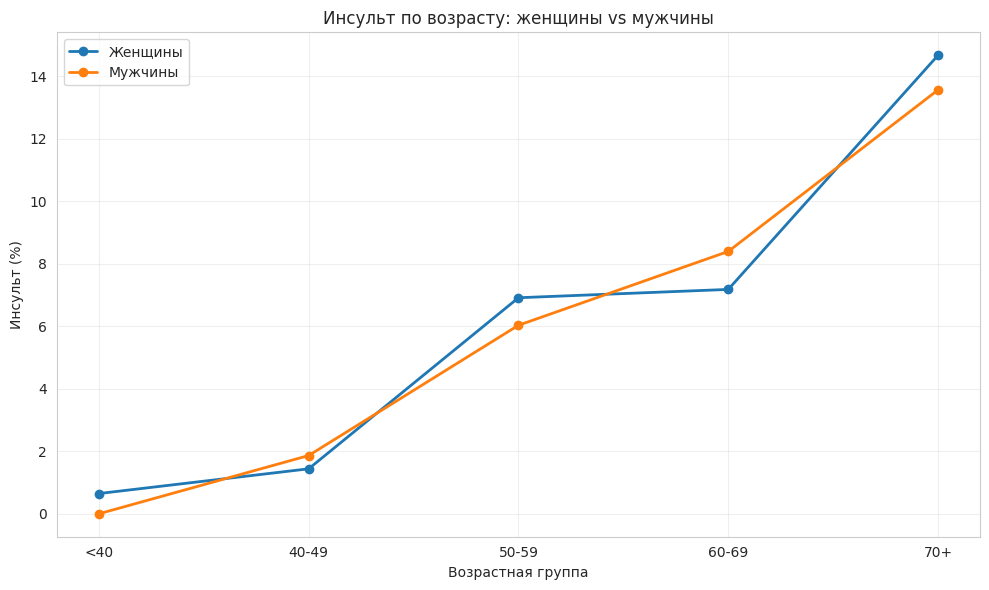


✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/stroke_by_age_gender.png

📝 КЛЮЧЕВЫЕ ВЫВОДЫ

🔹 <40:
   Женщины: 0.6% инсультов (n=772)
   Мужчины: 0.0% инсультов (n=501)

🔹 40-49:
   Женщины: 1.4% инсультов (n=278)
   Мужчины: 1.9% инсультов (n=161)

🔹 50-59:
   Женщины: 6.9% инсультов (n=246)
   Мужчины: 6.0% инсультов (n=199)

🔹 60-69:
   Женщины: 7.2% инсультов (n=209)
   Мужчины: 8.4% инсультов (n=143)

🔹 70+:
   Женщины: 14.7% инсультов (n=225)
   Мужчины: 13.6% инсультов (n=177)


In [30]:
# Анализ: возраст и инсульт в разрезе пола
print("=" * 60)
print("ВОЗРАСТ И ИНСУЛЬТ: СРАВНЕНИЕ МУЖЧИН И ЖЕНЩИН")
print("=" * 60)

# Создаём возрастные группы
df_temp = X_train.copy()
df_temp['stroke'] = y_train
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 50, 60, 70, 100],
                               labels=['<40', '40-49', '50-59', '60-69', '70+'])

# Таблица: пол × возрастная группа × инсульт
print("\n📊 Распределение инсультов по полу и возрасту (%):")
print("-" * 40)

cross = pd.crosstab([df_temp['gender'], df_temp['age_group']],
                     df_temp['stroke'], normalize='index') * 100
print(cross.round(1))

# Абсолютные числа
print("\n📊 Абсолютные числа:")
abs_cross = pd.crosstab([df_temp['gender'], df_temp['age_group']],
                         df_temp['stroke'])
print(abs_cross)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных для графика
plot_data = []
for gender in ['female', 'male']:
    for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
        subset = df_temp[(df_temp['gender'] == gender) & (df_temp['age_group'] == age_group)]
        if len(subset) > 0:
            stroke_rate = subset['stroke'].mean() * 100
            plot_data.append({
                'gender': 'Женщины' if gender == 'female' else 'Мужчины',
                'age_group': age_group,
                'stroke_rate': stroke_rate
            })

plot_df = pd.DataFrame(plot_data)

# Рисуем линии
for gender in ['Женщины', 'Мужчины']:
    data = plot_df[plot_df['gender'] == gender]
    ax.plot(data['age_group'], data['stroke_rate'], marker='o', linewidth=2, label=gender)

ax.set_xlabel('Возрастная группа')
ax.set_ylabel('Инсульт (%)')
ax.set_title('Инсульт по возрасту: женщины vs мужчины')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/stroke_by_age_gender.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ График сохранён: {PLOTS_PATH}/stroke_by_age_gender.png")

# Ключевые выводы
print("\n" + "=" * 60)
print("📝 КЛЮЧЕВЫЕ ВЫВОДЫ")
print("=" * 60)

for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
    female_subset = df_temp[(df_temp['gender'] == 'female') & (df_temp['age_group'] == age_group)]
    male_subset = df_temp[(df_temp['gender'] == 'male') & (df_temp['age_group'] == age_group)]

    female_rate = female_subset['stroke'].mean() * 100 if len(female_subset) > 0 else 0
    male_rate = male_subset['stroke'].mean() * 100 if len(male_subset) > 0 else 0

    print(f"\n🔹 {age_group}:")
    print(f"   Женщины: {female_rate:.1f}% инсультов (n={len(female_subset)})")
    print(f"   Мужчины: {male_rate:.1f}% инсультов (n={len(male_subset)})")

In [31]:
# ============================================
# ПРОВЕРКА ГИПОТЕЗЫ: МЕТАБОЛИЧЕСКИЙ СИНДРОМ
# (глюкоза > 126 И bmi > 30)
# ============================================

print("=" * 60)
print("АНАЛИЗ: ВЫСОКИЙ МЕТАБОЛИЧЕСКИЙ РИСК")
print("=" * 60)

# Создаём новый признак
X_train['high_risk_metabolic'] = ((X_train['avg_glucose_level'] > 126) & (X_train['bmi'] > 30)).astype(int)

print("\n📊 Распределение нового признака:")
print(X_train['high_risk_metabolic'].value_counts())
print(f"\n   Доля группы высокого риска: {X_train['high_risk_metabolic'].mean() * 100:.1f}%")

print("\n📊 Распределение инсультов по группам (%):")
print(pd.crosstab(X_train['high_risk_metabolic'], y_train, normalize='index') * 100)

# Повышение риска
risk_0 = (y_train[X_train['high_risk_metabolic'] == 0].mean() * 100) if len(y_train[X_train['high_risk_metabolic'] == 0]) > 0 else 0
risk_1 = (y_train[X_train['high_risk_metabolic'] == 1].mean() * 100) if len(y_train[X_train['high_risk_metabolic'] == 1]) > 0 else 0

print(f"\n📊 Повышение риска:")
print(f"   Низкий риск: {risk_0:.1f}% инсультов")
print(f"   Высокий риск: {risk_1:.1f}% инсультов")
if risk_0 > 0:
    print(f"   → Повышение риска в {risk_1 / risk_0:.1f}x")

# Корреляция с целевой
corr = X_train['high_risk_metabolic'].corr(y_train)
print(f"\n📊 Корреляция с целевой: {corr:.3f}")

# Сравнение с исходными признаками
print("\n📊 Сравнение корреляции с целевой:")
print(f"   avg_glucose_level: {X_train['avg_glucose_level'].corr(y_train):.3f}")
print(f"   bmi: {X_train['bmi'].corr(y_train):.3f}")
print(f"   high_risk_metabolic: {corr:.3f}")

АНАЛИЗ: ВЫСОКИЙ МЕТАБОЛИЧЕСКИЙ РИСК

📊 Распределение нового признака:
high_risk_metabolic
0    2628
1     283
Name: count, dtype: int64

   Доля группы высокого риска: 9.7%

📊 Распределение инсультов по группам (%):
stroke                       0         1
high_risk_metabolic                     
0                    96.270928  3.729072
1                    90.459364  9.540636

📊 Повышение риска:
   Низкий риск: 3.7% инсультов
   Высокий риск: 9.5% инсультов
   → Повышение риска в 2.6x

📊 Корреляция с целевой: 0.085

📊 Сравнение корреляции с целевой:
   avg_glucose_level: 0.112
   bmi: 0.051
   high_risk_metabolic: 0.085


In [32]:
# ============================================
# ПРОВЕРКА ГИПОТЕЗЫ: КАРДИО-РИСК
# (гипертония ИЛИ сердечные заболевания)
# ============================================

print("=" * 60)
print("АНАЛИЗ: КАРДИО-РИСК")
print("=" * 60)

# Создаём новый признак
X_train['cardio_risk'] = ((X_train['hypertension'] == 1) | (X_train['heart_disease'] == 1)).astype(int)

print("\n📊 Распределение нового признака:")
print(X_train['cardio_risk'].value_counts())
print(f"\n   Доля группы риска: {X_train['cardio_risk'].mean() * 100:.1f}%")

print("\n📊 Распределение инсультов по группам (%):")
print(pd.crosstab(X_train['cardio_risk'], y_train, normalize='index') * 100)

# Повышение риска
risk_0 = (y_train[X_train['cardio_risk'] == 0].mean() * 100)
risk_1 = (y_train[X_train['cardio_risk'] == 1].mean() * 100)

print(f"\n📊 Повышение риска:")
print(f"   Нет cardio_risk: {risk_0:.1f}% инсультов")
print(f"   Есть cardio_risk: {risk_1:.1f}% инсультов")
print(f"   → Повышение риска в {risk_1 / risk_0:.1f}x")

# Корреляция с целевой
corr = X_train['cardio_risk'].corr(y_train)
print(f"\n📊 Корреляция с целевой: {corr:.3f}")

# Сравнение с исходными признаками
print("\n📊 Сравнение корреляции с целевой:")
print(f"   hypertension: {X_train['hypertension'].corr(y_train):.3f}")
print(f"   heart_disease: {X_train['heart_disease'].corr(y_train):.3f}")
print(f"   cardio_risk: {corr:.3f}")

АНАЛИЗ: КАРДИО-РИСК

📊 Распределение нового признака:
cardio_risk
0    2526
1     385
Name: count, dtype: int64

   Доля группы риска: 13.2%

📊 Распределение инсультов по группам (%):
stroke               0          1
cardio_risk                      
0            97.030879   2.969121
1            87.012987  12.987013

📊 Повышение риска:
   Нет cardio_risk: 3.0% инсультов
   Есть cardio_risk: 13.0% инсультов
   → Повышение риска в 4.4x

📊 Корреляция с целевой: 0.167

📊 Сравнение корреляции с целевой:
   hypertension: 0.127
   heart_disease: 0.138
   cardio_risk: 0.167


In [33]:
# ============================================
# ПРОВЕРКА: СТАТУС КУРЕНИЯ
# ============================================

print("=" * 60)
print("АНАЛИЗ: СТАТУС КУРЕНИЯ")
print("=" * 60)

print("\n📊 Распределение инсультов по категориям (%):")
print(pd.crosstab(X_train['smoking_status'], y_train, normalize='index') * 100)

# Абсолютные числа
print("\n📊 Абсолютные числа:")
print(pd.crosstab(X_train['smoking_status'], y_train))

# Корреляция (закодируем label)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
smoking_encoded = le.fit_transform(X_train['smoking_status'])
corr = pd.Series(smoking_encoded).corr(y_train)
print(f"\n📊 Корреляция с целевой (Label Encoding): {corr:.3f}")

# Проверка, можно ли объединить unknown с never smoked
unknown_vs_never = pd.crosstab(X_train['smoking_status'], y_train, normalize='index') * 100
if 'unknown' in unknown_vs_never.index and 'never smoked' in unknown_vs_never.index:
    unknown_stroke = unknown_vs_never.loc['unknown', 1] if 1 in unknown_vs_never.columns else 0
    never_stroke = unknown_vs_never.loc['never smoked', 1] if 1 in unknown_vs_never.columns else 0

    print(f"\n📊 Сравнение 'unknown' и 'never smoked':")
    print(f"   unknown: {unknown_stroke:.1f}% инсультов")
    print(f"   never smoked: {never_stroke:.1f}% инсультов")

    if abs(unknown_stroke - never_stroke) < 2:
        print("   → Группы близки по риску. Можно объединить.")
    else:
        print("   → Группы различаются. Оставляем как есть.")

АНАЛИЗ: СТАТУС КУРЕНИЯ

📊 Распределение инсультов по категориям (%):
stroke                   0         1
smoking_status                      
formerly_smoked  94.059406  5.940594
never_smoked     95.258999  4.741001
smokes           95.172414  4.827586
unknown          97.596154  2.403846

📊 Абсолютные числа:
stroke              0   1
smoking_status           
formerly_smoked   475  30
never_smoked     1085  54
smokes            414  21
unknown           812  20

📊 Корреляция с целевой (Label Encoding): -0.059


In [34]:
# ============================================
# ПРОВЕРКА: ТИП РАБОТЫ (work_type)
# ============================================

print("=" * 60)
print("АНАЛИЗ: ТИП РАБОТЫ")
print("=" * 60)

print("\n📊 Распределение инсультов по категориям (%):")
print(pd.crosstab(X_train['work_type'], y_train, normalize='index') * 100)

print("\n📊 Абсолютные числа:")
print(pd.crosstab(X_train['work_type'], y_train))

# Корреляция (закодируем label)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
work_encoded = le.fit_transform(X_train['work_type'])
corr = pd.Series(work_encoded).corr(y_train)
print(f"\n📊 Корреляция с целевой (Label Encoding): {corr:.3f}")

АНАЛИЗ: ТИП РАБОТЫ

📊 Распределение инсультов по категориям (%):
stroke                  0         1
work_type                          
children        99.718310  0.281690
govt_job        96.078431  3.921569
never_worked   100.000000  0.000000
private         95.372596  4.627404
self-employed   93.446089  6.553911

📊 Абсолютные числа:
stroke            0   1
work_type              
children        354   1
govt_job        392  16
never_worked     11   0
private        1587  77
self-employed   442  31

📊 Корреляция с целевой (Label Encoding): 0.077


In [35]:
# ============================================
# ПРОВЕРКА: ТИП ПРОЖИВАНИЯ (residence_type)
# ============================================

print("=" * 60)
print("АНАЛИЗ: ТИП ПРОЖИВАНИЯ")
print("=" * 60)

print("\n📊 Распределение инсультов по категориям (%):")
print(pd.crosstab(X_train['residence_type'], y_train, normalize='index') * 100)

print("\n📊 Абсолютные числа:")
print(pd.crosstab(X_train['residence_type'], y_train))

# Корреляция
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
residence_encoded = le.fit_transform(X_train['residence_type'])
corr = pd.Series(residence_encoded).corr(y_train)
print(f"\n📊 Корреляция с целевой: {corr:.3f}")

АНАЛИЗ: ТИП ПРОЖИВАНИЯ

📊 Распределение инсультов по категориям (%):
stroke                  0         1
residence_type                     
rural           95.847751  4.152249
urban           95.566166  4.433834

📊 Абсолютные числа:
stroke             0   1
residence_type          
rural           1385  60
urban           1401  65

📊 Корреляция с целевой: 0.007


АНАЛИЗ: ТИП РАБОТЫ В РАЗРЕЗЕ ПОЛА

ПОЛ: MALE (n=1181)

📊 Инсульт по типу работы (%):
stroke             0    1
work_type                
children       100.0  0.0
govt_job        96.2  3.8
never_worked   100.0  0.0
private         94.9  5.1
self-employed   93.6  6.4

📊 Абсолютные числа:
stroke           0   1
work_type             
children       179   0
govt_job       154   6
never_worked     5   0
private        632  34
self-employed  160  11

📊 Доля self-employed: 14.5%

ПОЛ: FEMALE (n=1730)

📊 Инсульт по типу работы (%):
stroke             0    1
work_type                
children        99.4  0.6
govt_job        96.0  4.0
never_worked   100.0  0.0
private         95.7  4.3
self-employed   93.4  6.6

📊 Абсолютные числа:
stroke           0   1
work_type             
children       175   1
govt_job       238  10
never_worked     6   0
private        955  43
self-employed  282  20

📊 Доля self-employed: 17.5%

📊 ВИЗУАЛИЗАЦИЯ: риск инсульта по типу работы и полу


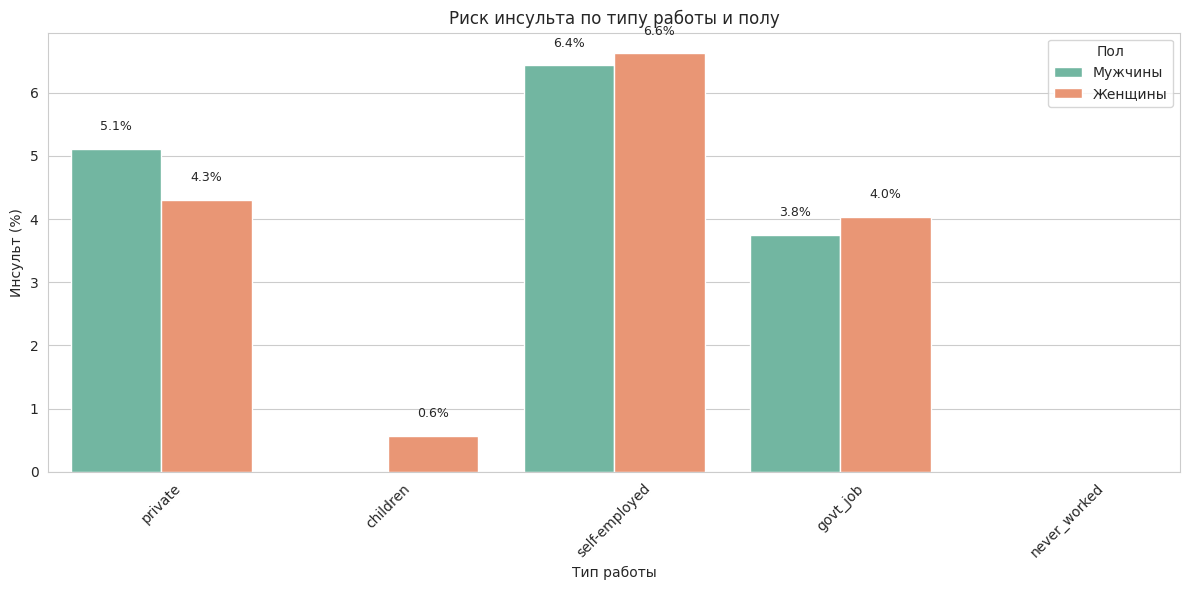


✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/work_type_by_gender.png


In [36]:
# ============================================
# ПРОВЕРКА: ТИП РАБОТЫ × ПОЛ
# ============================================

print("=" * 60)
print("АНАЛИЗ: ТИП РАБОТЫ В РАЗРЕЗЕ ПОЛА")
print("=" * 60)

# Создаём копию с целевой
df_temp = X_train.copy()
df_temp['stroke'] = y_train

# Анализ по полу
for gender in ['male', 'female']:
    subset = df_temp[df_temp['gender'] == gender]
    if len(subset) > 0:
        print(f"\n{'='*40}")
        print(f"ПОЛ: {gender.upper()} (n={len(subset)})")
        print('='*40)

        # Таблица: тип работы × инсульт (%)
        cross = pd.crosstab(subset['work_type'], subset['stroke'], normalize='index') * 100
        print("\n📊 Инсульт по типу работы (%):")
        print(cross.round(1))

        # Абсолютные числа
        print("\n📊 Абсолютные числа:")
        abs_cross = pd.crosstab(subset['work_type'], subset['stroke'])
        print(abs_cross)

        # Доля self-employed среди мужчин и женщин
        self_employed_pct = (subset['work_type'] == 'self-employed').mean() * 100
        print(f"\n📊 Доля self-employed: {self_employed_pct:.1f}%")

# Визуализация
print("\n" + "=" * 60)
print("📊 ВИЗУАЛИЗАЦИЯ: риск инсульта по типу работы и полу")
print("=" * 60)

# Подготовка данных для графика
plot_data = []
for gender in ['male', 'female']:
    for work_type in X_train['work_type'].unique():
        subset = df_temp[(df_temp['gender'] == gender) & (df_temp['work_type'] == work_type)]
        if len(subset) > 0:
            stroke_rate = subset['stroke'].mean() * 100
            plot_data.append({
                'gender': 'Мужчины' if gender == 'male' else 'Женщины',
                'work_type': work_type,
                'stroke_rate': stroke_rate,
                'n': len(subset)
            })

plot_df = pd.DataFrame(plot_data)

# Группированный барплот
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='work_type', y='stroke_rate', hue='gender', palette='Set2')
plt.title('Риск инсульта по типу работы и полу')
plt.xlabel('Тип работы')
plt.ylabel('Инсульт (%)')
plt.legend(title='Пол')
plt.xticks(rotation=45)

# Добавляем значения на столбцы
for i, bar in enumerate(plt.gca().patches):
    height = bar.get_height()
    if height > 0:
        plt.gca().text(bar.get_x() + bar.get_width()/2., height + 0.3,
                       f'{height:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/work_type_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ График сохранён: {PLOTS_PATH}/work_type_by_gender.png")

In [37]:
# ============================================
# ПРОВЕРКА: РАСШИРЕНИЕ senior_stress
# ============================================

print("=" * 60)
print("ПРОВЕРКА: SENIOR_STRESS С РАЗНЫМИ ТИПАМИ РАБОТ")
print("=" * 60)

# Вариант 1: только self-employed + private (текущий)
X_train['senior_stress_1'] = (
    (X_train['age'] > 60) &
    (X_train['work_type'].isin(['self-employed', 'private']))
).astype(int)

# Вариант 2: + govt_job
X_train['senior_stress_2'] = (
    (X_train['age'] > 60) &
    (X_train['work_type'].isin(['self-employed', 'private', 'govt_job']))
).astype(int)

# Вариант 3: все работающие (исключая children и never_worked)
X_train['senior_stress_3'] = (
    (X_train['age'] > 60) &
    (X_train['work_type'].isin(['self-employed', 'private', 'govt_job']))
).astype(int)  # по сути то же, что вариант 2

print("\n📊 Вариант 1 (self-employed + private):")
print(pd.crosstab(X_train['senior_stress_1'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['senior_stress_1'].corr(y_train):.3f}")
print(f"Доля группы: {X_train['senior_stress_1'].mean() * 100:.1f}%")

print("\n📊 Вариант 2 (+ govt_job):")
print(pd.crosstab(X_train['senior_stress_2'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['senior_stress_2'].corr(y_train):.3f}")
print(f"Доля группы: {X_train['senior_stress_2'].mean() * 100:.1f}%")

# Сравнение
print("\n" + "=" * 60)
print("📊 СРАВНЕНИЕ:")
print("=" * 60)
print(f"   Вариант 1 (self-employed + private): корреляция = {X_train['senior_stress_1'].corr(y_train):.3f}")
print(f"   Вариант 2 (+ govt_job): корреляция = {X_train['senior_stress_2'].corr(y_train):.3f}")

ПРОВЕРКА: SENIOR_STRESS С РАЗНЫМИ ТИПАМИ РАБОТ

📊 Вариант 1 (self-employed + private):
stroke                   0          1
senior_stress_1                      
0                97.708242   2.291758
1                88.629283  11.370717
Корреляция: 0.186
Доля группы: 22.1%

📊 Вариант 2 (+ govt_job):
stroke                   0          1
senior_stress_2                      
0                98.099212   1.900788
1                88.859416  11.140584
Корреляция: 0.200
Доля группы: 25.9%

📊 СРАВНЕНИЕ:
   Вариант 1 (self-employed + private): корреляция = 0.186
   Вариант 2 (+ govt_job): корреляция = 0.200


АНАЛИЗ: СТАТУС КУРЕНИЯ ПО ВОЗРАСТНЫМ ГРУППАМ

ВОЗРАСТ: <40 (n=1273)
stroke               0    1
smoking_status             
formerly_smoked  100.0  0.0
never_smoked      99.8  0.2
smokes            98.2  1.8
unknown           99.8  0.2

Абсолютные числа:
stroke             0  1
smoking_status         
formerly_smoked  108  0
never_smoked     458  1
smokes           166  3
unknown          536  1

ВОЗРАСТ: 40-49 (n=439)
stroke               0    1
smoking_status             
formerly_smoked   97.4  2.6
never_smoked      98.0  2.0
smokes           100.0  0.0
unknown           98.8  1.2

Абсолютные числа:
stroke             0  1
smoking_status         
formerly_smoked   75  2
never_smoked     193  4
smokes            85  0
unknown           79  1

ВОЗРАСТ: 50-59 (n=445)
stroke              0    1
smoking_status            
formerly_smoked  92.2  7.8
never_smoked     95.6  4.4
smokes           90.6  9.4
unknown          93.4  6.6

Абсолютные числа:
stroke             0  1
smoking_status   

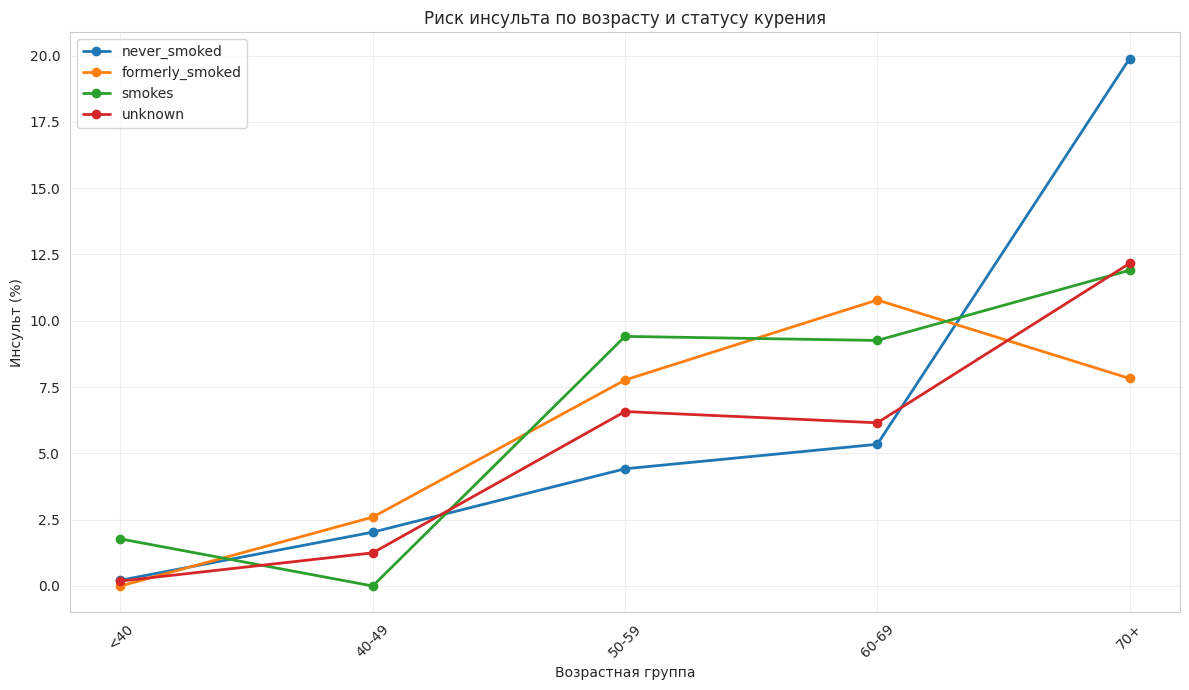


✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/smoking_by_age.png

📝 КЛЮЧЕВЫЕ ВЫВОДЫ

🔹 <40:
   never_smoked: 0.2% (n=459)
   formerly_smoked: 0.0% (n=108)
   smokes: 1.8% (n=169)
   unknown: 0.2% (n=537)

🔹 40-49:
   never_smoked: 2.0% (n=197)
   formerly_smoked: 2.6% (n=77)
   smokes: 0.0% (n=85)
   unknown: 1.2% (n=80)

🔹 50-59:
   never_smoked: 4.4% (n=181)
   formerly_smoked: 7.8% (n=103)
   smokes: 9.4% (n=85)
   unknown: 6.6% (n=76)

🔹 60-69:
   never_smoked: 5.3% (n=131)
   formerly_smoked: 10.8% (n=102)
   smokes: 9.3% (n=54)
   unknown: 6.2% (n=65)

🔹 70+:
   never_smoked: 19.9% (n=171)
   formerly_smoked: 7.8% (n=115)
   smokes: 11.9% (n=42)
   unknown: 12.2% (n=74)


In [38]:
# ============================================
# ПРОВЕРКА: КУРЕНИЕ × ВОЗРАСТНЫЕ ГРУППЫ
# ============================================

print("=" * 60)
print("АНАЛИЗ: СТАТУС КУРЕНИЯ ПО ВОЗРАСТНЫМ ГРУППАМ")
print("=" * 60)

# Создаём возрастные группы
df_temp = X_train.copy()
df_temp['stroke'] = y_train
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 50, 60, 70, 100],
                               labels=['<40', '40-49', '50-59', '60-69', '70+'])

# Анализ по возрастным группам
for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
    subset = df_temp[df_temp['age_group'] == age_group]
    if len(subset) > 0:
        print(f"\n{'='*40}")
        print(f"ВОЗРАСТ: {age_group} (n={len(subset)})")
        print('='*40)

        # Таблица: статус курения × инсульт
        cross = pd.crosstab(subset['smoking_status'], subset['stroke'], normalize='index') * 100
        print(cross.round(1))

        # Абсолютные числа
        print("\nАбсолютные числа:")
        abs_cross = pd.crosstab(subset['smoking_status'], subset['stroke'])
        print(abs_cross)

# Визуализация
print("\n" + "=" * 60)
print("📊 ВИЗУАЛИЗАЦИЯ: риск инсульта по возрасту и статусу курения")
print("=" * 60)

# Подготовка данных для графика
plot_data = []
for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
    subset = df_temp[df_temp['age_group'] == age_group]
    for smoking in ['never_smoked', 'formerly_smoked', 'smokes', 'unknown']:
        subsubset = subset[subset['smoking_status'] == smoking]
        if len(subsubset) > 0:
            stroke_rate = subsubset['stroke'].mean() * 100
            plot_data.append({
                'age_group': age_group,
                'smoking_status': smoking,
                'stroke_rate': stroke_rate,
                'n': len(subsubset)
            })

plot_df = pd.DataFrame(plot_data)

# Рисуем линии для каждого статуса курения
plt.figure(figsize=(12, 7))
for smoking in ['never_smoked', 'formerly_smoked', 'smokes', 'unknown']:
    data = plot_df[plot_df['smoking_status'] == smoking]
    if len(data) > 0:
        plt.plot(data['age_group'], data['stroke_rate'], marker='o', linewidth=2, label=smoking)

plt.xlabel('Возрастная группа')
plt.ylabel('Инсульт (%)')
plt.title('Риск инсульта по возрасту и статусу курения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/smoking_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ График сохранён: {PLOTS_PATH}/smoking_by_age.png")

# Выводы
print("\n" + "=" * 60)
print("📝 КЛЮЧЕВЫЕ ВЫВОДЫ")
print("=" * 60)

for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
    subset = df_temp[df_temp['age_group'] == age_group]
    if len(subset) > 0:
        print(f"\n🔹 {age_group}:")
        for smoking in ['never_smoked', 'formerly_smoked', 'smokes', 'unknown']:
            subsubset = subset[subset['smoking_status'] == smoking]
            if len(subsubset) > 0:
                stroke_pct = subsubset['stroke'].mean() * 100
                n = len(subsubset)
                print(f"   {smoking}: {stroke_pct:.1f}% (n={n})")

In [39]:
# Бинарный признак: работа в частном секторе или своё дело
X_train['is_high_risk_work'] = X_train['work_type'].isin(['self-employed', 'private']).astype(int)

print("\n📊 Распределение нового признака is_high_risk_work:")
print(X_train['is_high_risk_work'].value_counts())
print(f"\n   Доля группы риска: {X_train['is_high_risk_work'].mean() * 100:.1f}%")

print("\n📊 Распределение инсультов по группам (%):")
print(pd.crosstab(X_train['is_high_risk_work'], y_train, normalize='index') * 100)

# Корреляция
corr = X_train['is_high_risk_work'].corr(y_train)
print(f"\n📊 Корреляция с целевой: {corr:.3f}")


📊 Распределение нового признака is_high_risk_work:
is_high_risk_work
1    2137
0     774
Name: count, dtype: int64

   Доля группы риска: 73.4%

📊 Распределение инсультов по группам (%):
stroke                     0         1
is_high_risk_work                     
0                  97.803618  2.196382
1                  94.946186  5.053814

📊 Корреляция с целевой: 0.062


In [40]:
# ============================================
# ПРОВЕРКА: КОМБИНАЦИИ work_type С ДРУГИМИ ПРИЗНАКАМИ
# ============================================

print("=" * 60)
print("АНАЛИЗ КОМБИНАЦИЙ work_type")
print("=" * 60)

# 1. Стресс + кардио
X_train['stress_cardio'] = (
    (X_train['work_type'].isin(['self-employed', 'private'])) &
    (X_train['cardio_risk'] == 1)
).astype(int)

print("\n📊 stress_cardio:")
print(pd.crosstab(X_train['stress_cardio'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['stress_cardio'].corr(y_train):.3f}")

# 2. Стресс + пожилой возраст
X_train['senior_stress'] = (
    (X_train['age'] > 60) &
    (X_train['work_type'].isin(['self-employed', 'private']))
).astype(int)

print("\n📊 senior_stress:")
print(pd.crosstab(X_train['senior_stress'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['senior_stress'].corr(y_train):.3f}")

# 3. Нет поддержки + стресс
X_train['no_support_stress'] = (
    (X_train['marriage_risk'] == 'senior_unmarried') &
    (X_train['work_type'].isin(['self-employed', 'private']))
).astype(int)

print("\n📊 no_support_stress:")
print(pd.crosstab(X_train['no_support_stress'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['no_support_stress'].corr(y_train):.3f}")

# 4. Сравнение с исходным work_type (one-hot)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
work_encoded = le.fit_transform(X_train['work_type'])
print(f"\n📊 Оригинальный work_type (Label Encoding): {pd.Series(work_encoded).corr(y_train):.3f}")


АНАЛИЗ КОМБИНАЦИЙ work_type

📊 stress_cardio:
stroke                 0          1
stress_cardio                      
0              96.866538   3.133462
1              86.503067  13.496933
Корреляция: 0.161

📊 senior_stress:
stroke                 0          1
senior_stress                      
0              97.708242   2.291758
1              88.629283  11.370717
Корреляция: 0.186

📊 no_support_stress:
stroke                     0          1
no_support_stress                      
0                  95.983234   4.016766
1                  79.166667  20.833333
Корреляция: 0.106

📊 Оригинальный work_type (Label Encoding): 0.077


# Удаление признаков после создания

In [41]:
# 5.2 УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ FEATURE ENGINEERING

print("\n" + "="*50)
print("🗑️ УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ FEATURE ENGINEERING")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    if columns_to_drop_fe:
        existing_cols = [col for col in columns_to_drop_fe if col in X_train.columns]
        missing_cols = [col for col in columns_to_drop_fe if col not in X_train.columns]

        if existing_cols:
            X_train.drop(columns=existing_cols, inplace=True)
            print(f"\n🗑️ Удалены признаки ({len(existing_cols)}):")
            for col in existing_cols:
                print(f"   • {col}")
        else:
            print("\n⚠️ Указанные признаки не найдены в X_train")

        if missing_cols:
            print(f"\n⚠️ Не найдены ({len(missing_cols)}):")
            for col in missing_cols:
                print(f"   • {col}")
    else:
        print("\n✓ Нет признаков для удаления (columns_to_drop_fe пуст)")

    # Итоговая форма
    print(f"\n📊 Форма X_train: {X_train.shape[0]} строк, {X_train.shape[1]} колонок")

    # Список всех признаков
    print(f"\n📋 Текущие признаки ({len(X_train.columns)}):")
    print(f"   {X_train.columns.tolist()}")

    # Сохраняем checkpoint
    feature_eng_path = os.path.join(CHECKPOINT_PATH, '05_feature_engineering.csv')
    X_train.to_csv(feature_eng_path, index=False)
    print(f"\n✓ Сохранено: checkpoints/05_feature_engineering.csv")

print("\n" + "="*50)
print("✓ Удаление признаков завершено")
print("="*50 + "\n")


🗑️ УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ FEATURE ENGINEERING

🗑️ Удалены признаки (15):
   • ever_married
   • hypertension
   • heart_disease
   • work_type
   • gender
   • residence_type
   • smoking_status
   • senior_stress
   • is_high_risk_work
   • high_risk_metabolic
   • senior_stress_1
   • senior_stress_2
   • senior_stress_3
   • stress_cardio
   • no_support_stress

📊 Форма X_train: 2911 строк, 8 колонок

📋 Текущие признаки (8):
   ['age', 'avg_glucose_level', 'bmi', 'cardio_risk', 'senior_work', 'senior_work_2', 'senior_work_1', 'marriage_risk']

✓ Сохранено: checkpoints/05_feature_engineering.csv

✓ Удаление признаков завершено



In [42]:
# 5.3 СВОДНЫЙ АНАЛИЗ НОВЫХ ПРИЗНАКОВ

print("\n" + "="*50)
print("📊 СВОДНЫЙ АНАЛИЗ НОВЫХ ПРИЗНАКОВ")
print("="*50)

if X_train is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Используем список из настроек
    new_features = NEW_FEATURES if NEW_FEATURES else []

    # Проверяем, какие из них реально существуют
    existing_features = [f for f in new_features if f in X_train.columns]
    missing_features = [f for f in new_features if f not in X_train.columns]

    if missing_features:
        print(f"\n⚠️ Указаны, но не найдены: {missing_features}")

    if not existing_features:
        print("\n⚠️ Нет новых признаков для анализа.")
        print("   Заполните NEW_FEATURES в блоке 1.2")
    else:
        print(f"\n📋 Анализируемые признаки ({len(existing_features)}):")
        print(f"   {existing_features}")

        # Сравнительная таблица
        print("\n" + "-"*60)
        print("📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА НОВЫХ ПРИЗНАКОВ")
        print("-"*60)

        comparison_data = []

        for col in existing_features:
            # Тип признака
            if X_train[col].dtype in ['int64', 'Int64', 'float64', 'int32', 'float32']:
                col_type = 'Числовой'
                unique_count = X_train[col].nunique()

                if unique_count <= 2:
                    risk_pct = X_train[col].mean() * 100
                    stats = f"доля 1: {risk_pct:.1f}%"
                else:
                    stats = f"[{X_train[col].min():.2f}, {X_train[col].max():.2f}]"
            else:
                col_type = 'Категориальный'
                unique_count = X_train[col].nunique()
                stats = f"категорий: {unique_count}"

            # Корреляция с целевой
            if TASK_TYPE == 'classification':
                if X_train[col].dtype in ['int64', 'Int64', 'float64']:
                    corr = X_train[col].corr(y_train)
                else:
                    le = LabelEncoder()
                    encoded = le.fit_transform(X_train[col].astype(str))
                    corr = pd.Series(encoded).corr(y_train)

                # Цветовая индикация
                if abs(corr) > 0.3:
                    corr_str = f"🟢 {corr:.3f}"
                elif abs(corr) > 0.15:
                    corr_str = f"🟡 {corr:.3f}"
                else:
                    corr_str = f"🔴 {corr:.3f}"
            else:
                corr_str = "—"

            comparison_data.append({
                'Признак': col,
                'Тип': col_type,
                'Уник': unique_count,
                'Статистика': stats,
                f'Корр с {TARGET_COLUMN}': corr_str
            })

        comparison_df = pd.DataFrame(comparison_data)
        display(comparison_df)

        # Детальный анализ
        print("\n" + "="*50)
        print("🔍 ДЕТАЛЬНЫЙ АНАЛИЗ")
        print("="*50)

        for col in existing_features:
            print(f"\n{'─'*40}")
            print(f"📌 {col}")
            print('─'*40)

            if X_train[col].dtype in ['int64', 'Int64', 'float64', 'int32', 'float32']:
                print(f"   Тип: числовой")
                print(f"   Уникальных: {X_train[col].nunique()}")
                print(f"   Среднее: {X_train[col].mean():.3f}")
                print(f"   Медиана: {X_train[col].median():.3f}")
                print(f"   Пропусков: {X_train[col].isnull().sum()}")

                if X_train[col].nunique() <= 2:
                    print(f"\n   📊 Связь с {TARGET_COLUMN}:")
                    cross = pd.crosstab(X_train[col], y_train, normalize='index') * 100
                    for idx in cross.index:
                        val_name = "Да" if idx == 1 else ("Нет" if idx == 0 else str(idx))
                        if 1 in cross.columns:
                            target_pct = cross.loc[idx, 1]
                            print(f"      {val_name}: {target_pct:.1f}% класса 1")
            else:
                print(f"   Тип: категориальный")
                print(f"   Уникальных: {X_train[col].nunique()}")
                print(f"   Пропусков: {X_train[col].isnull().sum()}")

                print(f"\n   📊 Связь с {TARGET_COLUMN} (%):")
                cross = pd.crosstab(X_train[col], y_train, normalize='index') * 100
                display(cross.round(1))

        # Сила связи
        if TASK_TYPE == 'classification':
            print("\n💡 Сила связи:")
            print("   🟢 |r| > 0.3 — сильная связь (важный признак)")
            print("   🟡 |r| > 0.15 — умеренная связь")
            print("   🔴 |r| ≤ 0.15 — слабая связь (кандидат на удаление)")

print("\n" + "="*50)
print("✓ Анализ новых признаков завершён")
print("="*50 + "\n")


📊 СВОДНЫЙ АНАЛИЗ НОВЫХ ПРИЗНАКОВ

📋 Анализируемые признаки (5):
   ['cardio_risk', 'senior_work', 'marriage_risk', 'senior_work_1', 'senior_work_2']

------------------------------------------------------------
📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА НОВЫХ ПРИЗНАКОВ
------------------------------------------------------------


,Признак,Тип,Уник,Статистика,Корр с stroke
0,cardio_risk,Числовой,2,доля 1: 13.2%,🟡 0.167
1,senior_work,Числовой,2,доля 1: 25.9%,🟡 0.200
2,marriage_risk,Категориальный,3,категорий: 3,🟡 -0.186
3,senior_work_1,Числовой,2,доля 1: 9.0%,🔴 0.087
4,senior_work_2,Числовой,2,доля 1: 22.1%,🟡 0.186



🔍 ДЕТАЛЬНЫЙ АНАЛИЗ

────────────────────────────────────────
📌 cardio_risk
────────────────────────────────────────
   Тип: числовой
   Уникальных: 2
   Среднее: 0.132
   Медиана: 0.000
   Пропусков: 0

   📊 Связь с stroke:
      Нет: 3.0% класса 1
      Да: 13.0% класса 1

────────────────────────────────────────
📌 senior_work
────────────────────────────────────────
   Тип: числовой
   Уникальных: 2
   Среднее: 0.259
   Медиана: 0.000
   Пропусков: 0

   📊 Связь с stroke:
      Нет: 1.9% класса 1
      Да: 11.1% класса 1

────────────────────────────────────────
📌 marriage_risk
────────────────────────────────────────
   Тип: категориальный
   Уникальных: 3
   Пропусков: 0

   📊 Связь с stroke (%):


stroke,0,1
marriage_risk,,
senior_married,89.7,10.3
senior_unmarried,78.9,21.1
young,98.1,1.9



────────────────────────────────────────
📌 senior_work_1
────────────────────────────────────────
   Тип: числовой
   Уникальных: 2
   Среднее: 0.090
   Медиана: 0.000
   Пропусков: 0

   📊 Связь с stroke:
      Нет: 3.7% класса 1
      Да: 9.9% класса 1

────────────────────────────────────────
📌 senior_work_2
────────────────────────────────────────
   Тип: числовой
   Уникальных: 2
   Среднее: 0.221
   Медиана: 0.000
   Пропусков: 0

   📊 Связь с stroke:
      Нет: 2.3% класса 1
      Да: 11.4% класса 1

💡 Сила связи:
   🟢 |r| > 0.3 — сильная связь (важный признак)
   🟡 |r| > 0.15 — умеренная связь
   🔴 |r| ≤ 0.15 — слабая связь (кандидат на удаление)

✓ Анализ новых признаков завершён



# БЛОК 6. category info

In [43]:
# 6.1 АНАЛИЗ КАТЕГОРИАЛЬНЫХ КОЛОНОК ПЕРЕД КОДИРОВАНИЕМ

print("\n" + "="*50)
print("🏷️ АНАЛИЗ КАТЕГОРИАЛЬНЫХ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Определяем категориальные колонки (включая bool)
    categorical_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    if len(categorical_cols) == 0:
        print("\n⚠️ Нет категориальных колонок для анализа")
    else:
        print(f"\n📋 Категориальные колонки ({len(categorical_cols)}):")
        print(f"   {categorical_cols}")

        categorical_info = []

        for col in categorical_cols:
            unique_count = X_train[col].nunique()
            top_values = X_train[col].value_counts().head(3)

            # Редкие категории (<1%)
            value_counts = X_train[col].value_counts()
            rare_threshold = max(len(X_train) * 0.01, 1)
            rare_categories = value_counts[value_counts < rare_threshold]

            # Определяем рекомендуемый метод кодирования
            if unique_count == 2:
                method = "🟢 LabelEncoder"
            elif unique_count <= 10:
                method = "🟢 OneHotEncoder"
            elif unique_count <= 50:
                method = "🟡 TargetEncoder"
            else:
                method = "🔴 TargetEncoder / FeatureHasher"

            categorical_info.append({
                'Колонка': col,
                'Уник': unique_count,
                'Топ-1': f"{top_values.index[0]}" if len(top_values) > 0 else '-',
                'Топ-1 %': f"{(top_values.iloc[0]/len(X_train)*100):.1f}%" if len(top_values) > 0 else '-',
                'Редких': len(rare_categories),
                'Метод': method
            })

            print(f"\n🏷️ {col}:")
            print(f"   Уникальных: {unique_count}")
            print(f"   Топ-3 значений:")
            for val, cnt in top_values.items():
                pct = cnt / len(X_train) * 100
                print(f"      {val}: {cnt:>6} ({pct:>5.1f}%)")

            if len(rare_categories) > 0:
                print(f"   ⚠️ Редких категорий (<1%): {len(rare_categories)}")
                print(f"      Примеры: {list(rare_categories.head(3).index)}")

        # Сводная таблица
        print("\n" + "-"*60)
        print("📊 СВОДНАЯ ТАБЛИЦА:")
        print("-"*60)
        categorical_df = pd.DataFrame(categorical_info)
        display(categorical_df)

        # Рекомендации по кодированию
        print("\n💡 РЕКОМЕНДАЦИИ ПО КОДИРОВАНИЮ:")
        print("-"*60)
        print("   🟢 LabelEncoder — для бинарных (2 значения)")
        print("   🟢 OneHotEncoder — для низкокардинальных (≤10)")
        print("   🟡 TargetEncoder — для среднекардинальных (11-50)")
        print("   🔴 TargetEncoder/FeatureHasher — для высококардинальных (>50)")

        print("\n📝 Пример для encoding_config (блок 1.2):")
        print("   encoding_config = {")
        for info in categorical_info[:3]:
            col = info['Колонка']
            if info['Уник'] == 2:
                print(f"       '{col}': ('label', None),")
            elif info['Уник'] <= 10:
                print(f"       '{col}': ('one_hot', None),")
            else:
                print(f"       '{col}': ('target', None),")
        print("   }")

        # Предупреждение о редких категориях
        cols_with_rare = [info['Колонка'] for info in categorical_info if info['Редких'] > 0]
        if cols_with_rare:
            print(f"\n⚠️ Колонки с редкими категориями: {cols_with_rare}")
            print("   Рассмотрите объединение редких категорий в 'other'")

print("\n" + "="*50)
print("✓ Анализ категориальных колонок завершён")
print("="*50 + "\n")


🏷️ АНАЛИЗ КАТЕГОРИАЛЬНЫХ КОЛОНОК

📋 Категориальные колонки (1):
   ['marriage_risk']

🏷️ marriage_risk:
   Уникальных: 3
   Топ-3 значений:
      young:   2157 ( 74.1%)
      senior_married:    697 ( 23.9%)
      senior_unmarried:     57 (  2.0%)

------------------------------------------------------------
📊 СВОДНАЯ ТАБЛИЦА:
------------------------------------------------------------


,Колонка,Уник,Топ-1,Топ-1 %,Редких,Метод
0,marriage_risk,3,young,74.1%,0,🟢 OneHotEncoder



💡 РЕКОМЕНДАЦИИ ПО КОДИРОВАНИЮ:
------------------------------------------------------------
   🟢 LabelEncoder — для бинарных (2 значения)
   🟢 OneHotEncoder — для низкокардинальных (≤10)
   🟡 TargetEncoder — для среднекардинальных (11-50)
   🔴 TargetEncoder/FeatureHasher — для высококардинальных (>50)

📝 Пример для encoding_config (блок 1.2):
   encoding_config = {
       'marriage_risk': ('one_hot', None),
   }

✓ Анализ категориальных колонок завершён



# Viz categorical_cols


📊 ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ КОЛОНОК

📋 Категориальные колонки (1):
   ['marriage_risk']

💾 Сохраняем графики в: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots



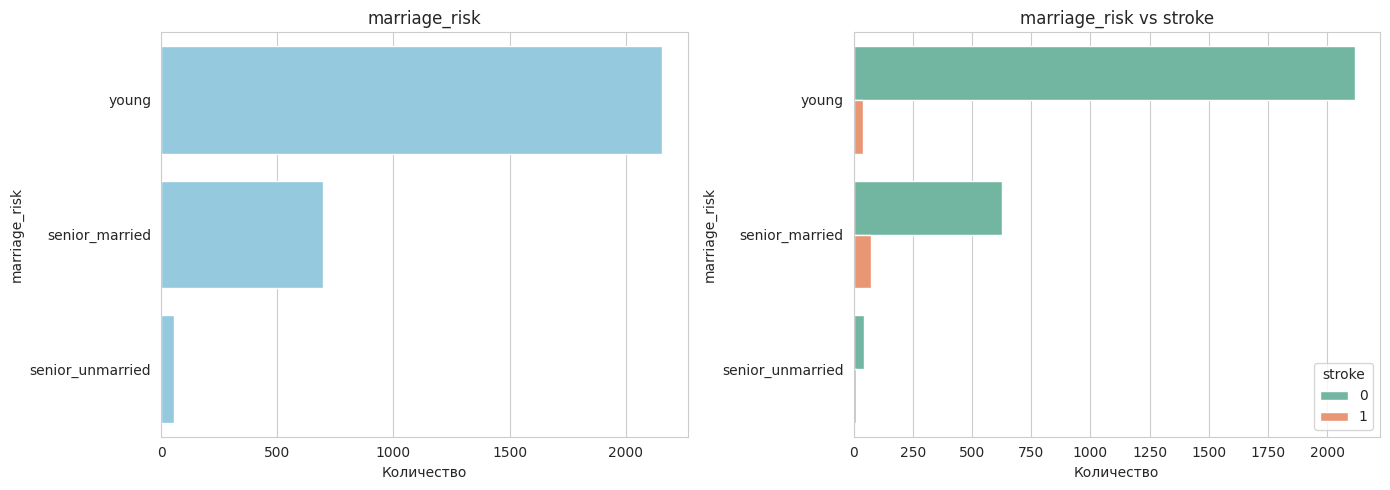

   ✓ marriage_risk

✅ Графики сохранены в: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots

✓ Визуализация категориальных колонок завершена



In [44]:
# 6.2 ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ КОЛОНОК

print("\n" + "="*50)
print("📊 ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Определяем категориальные колонки
    categorical_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    if len(categorical_cols) == 0:
        print("\n⚠️ Нет категориальных колонок для визуализации")
    else:
        print(f"\n📋 Категориальные колонки ({len(categorical_cols)}):")
        print(f"   {categorical_cols}")
        print(f"\n💾 Сохраняем графики в: {PLOTS_PATH}\n")

        for col in categorical_cols:
            try:
                # Определяем, нужен ли hue
                use_hue = HUE_BY_TARGET and TASK_TYPE == 'classification' and y_train is not None

                if use_hue:
                    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                    # График 1: общее распределение
                    value_counts = X_train[col].value_counts()
                    if len(value_counts) > 20:
                        plot_data = value_counts.head(15)
                        title1 = f'{col} (топ-15 из {len(value_counts)})'
                    else:
                        plot_data = value_counts
                        title1 = col

                    sns.barplot(x=plot_data.values, y=plot_data.index, ax=axes[0], color='skyblue')
                    axes[0].set_title(title1)
                    axes[0].set_xlabel('Количество')

                    # График 2: с разделением по целевой
                    plot_df = pd.DataFrame({col: X_train[col], TARGET_COLUMN: y_train})
                    if len(X_train[col].unique()) > 10:
                        top_cats = X_train[col].value_counts().head(10).index
                        plot_df = plot_df[plot_df[col].isin(top_cats)]
                        title2 = f'{col} vs {TARGET_COLUMN} (топ-10)'
                    else:
                        title2 = f'{col} vs {TARGET_COLUMN}'

                    sns.countplot(data=plot_df, y=col, hue=TARGET_COLUMN, ax=axes[1], palette='Set2')
                    axes[1].set_title(title2)
                    axes[1].set_xlabel('Количество')
                    axes[1].legend(title=TARGET_COLUMN)

                else:
                    # Только общее распределение
                    plt.figure(figsize=(8, max(4, X_train[col].nunique() * 0.3)))

                    value_counts = X_train[col].value_counts()
                    if len(value_counts) > 20:
                        plot_data = value_counts.head(15)
                        title = f'{col} (топ-15 из {len(value_counts)})'
                    else:
                        plot_data = value_counts
                        title = col

                    ax = sns.barplot(x=plot_data.values, y=plot_data.index, color='skyblue')
                    plt.title(title)
                    plt.xlabel('Количество')

                    # Добавляем проценты
                    total = len(X_train)
                    for i, (val, count) in enumerate(plot_data.items()):
                        pct = count / total * 100
                        ax.text(count + max(plot_data.values) * 0.01, i, f'{pct:.1f}%', va='center')

                plt.tight_layout()
                plot_path = os.path.join(PLOTS_PATH, f'categorical_{col}.png')
                plt.savefig(plot_path, dpi=150, bbox_inches='tight')
                plt.show()
                plt.close()

                print(f"   ✓ {col}")

            except Exception as e:
                print(f"   ⚠️ Ошибка для {col}: {e}")

        print(f"\n✅ Графики сохранены в: {PLOTS_PATH}")

print("\n" + "="*50)
print("✓ Визуализация категориальных колонок завершена")
print("="*50 + "\n")

# БЛОК 7. Корреляция

In [45]:
# 7.1 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

print("\n" + "="*50)
print("🔧 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
    X_train_encoded = None
    encoders = {}
else:
    # Приводим Int64 к int64
    for col in X_train.select_dtypes(include=['Int64']).columns:
        X_train[col] = X_train[col].astype('int64')
        print(f"   ✓ {col}: Int64 → int64")

    # Копия для кодирования
    X_train_encoded = X_train.copy()
    encoders = {}

    if encoding_config:
        print("\n📊 Применяем кодирование:\n")

        for col, (method, params) in encoding_config.items():
            if col not in X_train.columns:
                print(f"   ⚠️ {col}: не найдена, пропускаем")
                continue

            if method == 'one_hot':
    # ОПЦИОНАЛЬНО: задать порядок категорий для контроля референсной
                if col == 'marriage_risk':
                     X_train[col] = pd.Categorical(
                     X_train[col],
                     categories=['young', 'senior_married', 'senior_unmarried'],
                     ordered=False
                     )

                dummies = pd.get_dummies(X_train[col], prefix=col, drop_first=True, dtype=int)
                X_train_encoded = pd.concat([X_train_encoded, dummies], axis=1)
                X_train_encoded.drop(columns=[col], inplace=True)

                encoders[col] = {
                    'method': 'one_hot',
                    'columns': list(dummies.columns),
                    'drop_first': True
                }
                print(f"   ✓ {col}: ONE-HOT → {len(dummies.columns)} колонок (drop_first=True)")

            elif method == 'label':
                le = LabelEncoder()
                X_train_encoded[col] = le.fit_transform(X_train[col].astype(str))
                encoders[col] = {'method': 'label', 'encoder': le, 'classes': le.classes_.tolist()}
                print(f"   ✓ {col}: LABEL → {len(le.classes_)} классов")

            elif method == 'target':
                # Target Encoding с сглаживанием
                global_mean = y_train.mean()
                agg = y_train.groupby(X_train[col]).agg(['mean', 'count'])
                agg.columns = ['mean', 'count']

                # Сглаживание
                smoothing = 10
                agg['smooth'] = (agg['count'] * agg['mean'] + smoothing * global_mean) / (agg['count'] + smoothing)

                X_train_encoded[f'{col}_target'] = X_train[col].map(agg['smooth'])
                X_train_encoded.drop(columns=[col], inplace=True)

                encoders[col] = {
                    'method': 'target',
                    'mapping': agg['smooth'].to_dict(),
                    'global_mean': global_mean
                }
                print(f"   ✓ {col}: TARGET → {col}_target")

            elif method == 'frequency':
                # Frequency Encoding
                freq = X_train[col].value_counts(normalize=True)
                X_train_encoded[f'{col}_freq'] = X_train[col].map(freq)
                X_train_encoded.drop(columns=[col], inplace=True)

                encoders[col] = {'method': 'frequency', 'mapping': freq.to_dict()}
                print(f"   ✓ {col}: FREQUENCY → {col}_freq")

            elif method == 'none':
                print(f"   ✓ {col}: без кодирования")
                encoders[col] = {'method': 'none'}

            else:
                print(f"   ⚠️ {col}: неизвестный метод '{method}'")

        print(f"\n✅ Кодирование завершено")
        print(f"   Исходная форма: {X_train.shape}")
        print(f"   После кодирования: {X_train_encoded.shape}")

        # Новые колонки
        new_cols = set(X_train_encoded.columns) - set(X_train.columns)
        if new_cols:
            print(f"\n📋 Новые колонки ({len(new_cols)}):")
            for c in sorted(new_cols):
                print(f"   • {c}")

        # Сохраняем энкодеры
        encoders_path = os.path.join(TRANSFORMERS_PATH, 'encoders.pkl')
        joblib.dump(encoders, encoders_path)
        print(f"\n✓ Энкодеры сохранены: transformers/encoders.pkl")

    else:
        print("\n⚠️ encoding_config пуст, кодирование не применяется")

print("\n" + "="*50)
print("✓ Кодирование завершено")
print("="*50 + "\n")


🔧 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
   ✓ cardio_risk: Int64 → int64
   ✓ senior_work: Int64 → int64
   ✓ senior_work_2: Int64 → int64
   ✓ senior_work_1: Int64 → int64

📊 Применяем кодирование:

   ✓ marriage_risk: ONE-HOT → 2 колонок (drop_first=True)

✅ Кодирование завершено
   Исходная форма: (2911, 8)
   После кодирования: (2911, 9)

📋 Новые колонки (2):
   • marriage_risk_senior_married
   • marriage_risk_senior_unmarried

✓ Энкодеры сохранены: transformers/encoders.pkl

✓ Кодирование завершено




📈 КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ

📊 Числовых колонок: 9

📊 Матрица корреляции:


,age,avg_glucose_level,bmi,cardio_risk,senior_work,senior_work_2,senior_work_1,marriage_risk_senior_married,marriage_risk_senior_unmarried
age,1.00,0.22,0.32,0.36,0.74,0.67,0.42,0.70,0.20
avg_glucose_level,0.22,1.00,0.19,0.24,0.19,0.17,0.11,0.19,0.03
bmi,0.32,0.19,1.00,0.15,0.07,0.05,0.02,0.06,0.03
cardio_risk,0.36,0.24,0.15,1.00,0.34,0.33,0.21,0.32,0.09
senior_work,0.74,0.19,0.07,0.34,1.00,0.90,0.53,0.95,0.24
senior_work_2,0.67,0.17,0.05,0.33,0.90,1.00,0.59,0.85,0.21
senior_work_1,0.42,0.11,0.02,0.21,0.53,0.59,1.00,0.50,0.15
marriage_risk_senior_married,0.70,0.19,0.06,0.32,0.95,0.85,0.50,1.00,-0.08
marriage_risk_senior_unmarried,0.20,0.03,0.03,0.09,0.24,0.21,0.15,-0.08,1.00


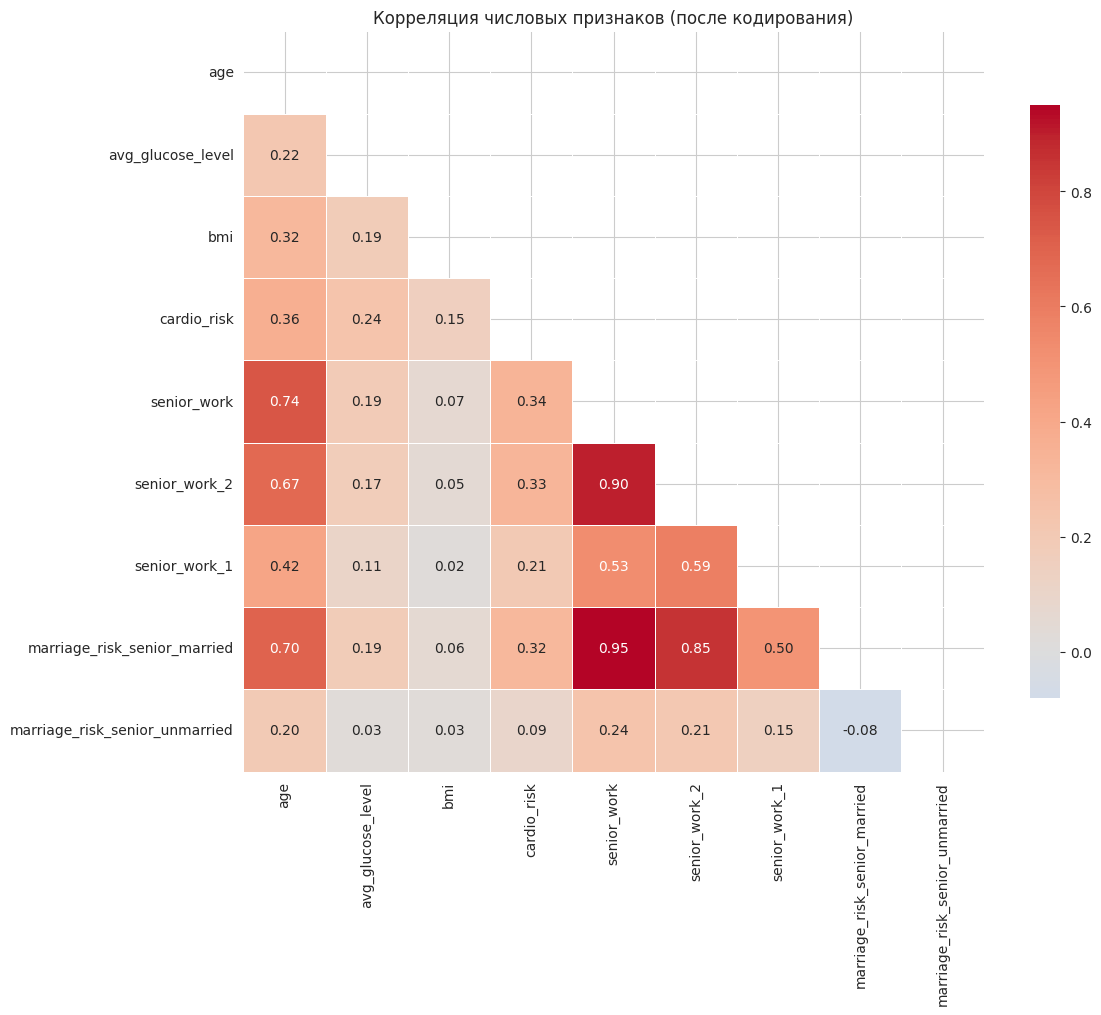


✓ Тепловая карта сохранена: plots/correlation_heatmap_encoded.png

🔍 Сильные корреляции (|r| > 0.7):

   Найдено пар: 4


,,Признак 1,Признак 2,Корреляция
2,🔴,senior_work,marriage_risk_senior_married,+0.95
1,🟠,senior_work,senior_work_2,+0.90
3,🟠,senior_work_2,marriage_risk_senior_married,+0.85
0,🟡,age,senior_work,+0.74



💡 Рекомендация: рассмотрите удаление одного из пары

✓ Корреляционный анализ завершён



In [46]:
# 7.2 КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ (ПОСЛЕ КОДИРОВАНИЯ)

print("\n" + "="*50)
print("📈 КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*50)

# Используем X_train_encoded, если доступен, иначе X_train
data_for_corr = X_train_encoded if 'X_train_encoded' in locals() and X_train_encoded is not None else X_train

if data_for_corr is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Определяем числовые колонки
    numeric_cols = data_for_corr.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()

    if len(numeric_cols) < 2:
        print("\n⚠️ Недостаточно числовых колонок для корреляции")
    else:
        print(f"\n📊 Числовых колонок: {len(numeric_cols)}")

        # Матрица корреляции
        corr_matrix = data_for_corr[numeric_cols].corr()

        print("\n📊 Матрица корреляции:")
        display(corr_matrix.round(2))

        # Тепловая карта
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                    fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title('Корреляция числовых признаков (после кодирования)')
        plt.tight_layout()

        plot_path = os.path.join(PLOTS_PATH, 'correlation_heatmap_encoded.png')
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✓ Тепловая карта сохранена: plots/correlation_heatmap_encoded.png")

        # Поиск сильных корреляций
        print("\n🔍 Сильные корреляции (|r| > 0.7):")

        strong_corr = []

        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.7:
                    col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]

                    # Цветовая индикация
                    if abs(corr_val) > 0.9:
                        level = "🔴"
                    elif abs(corr_val) > 0.8:
                        level = "🟠"
                    else:
                        level = "🟡"

                    strong_corr.append({
                        '': level,
                        'Признак 1': col1,
                        'Признак 2': col2,
                        'Корреляция': f"{corr_val:+.2f}"
                    })

        if strong_corr:
            print(f"\n   Найдено пар: {len(strong_corr)}")
            strong_df = pd.DataFrame(strong_corr).sort_values('Корреляция', ascending=False)
            display(strong_df)
            print("\n💡 Рекомендация: рассмотрите удаление одного из пары")
        else:
            print("\n   ✅ Сильных корреляций не обнаружено")

        # Топ-5 корреляций с целевой (если целевая числовая)
        if TARGET_COLUMN in data_for_corr.columns:
            print(f"\n🎯 Топ-5 корреляций с {TARGET_COLUMN}:")
            target_corr = corr_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
            for col, corr in target_corr.head(5).items():
                level = "🔴" if abs(corr) > 0.3 else ("🟡" if abs(corr) > 0.15 else "🟢")
                print(f"   {level} {col}: {corr:+.3f}")

print("\n" + "="*50)
print("✓ Корреляционный анализ завершён")
print("="*50 + "\n")


🎯 СВЯЗЬ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

📊 Числовых признаков: 9

📊 ANOVA F-value (классификация):



,Признак,F-value,p-value,Значимость
0,age,151.8147,0.0000,🟢
4,senior_work,120.8006,0.0000,🟢
5,senior_work_2,103.8801,0.0000,🟢
3,cardio_risk,83.8773,0.0000,🟢
7,marriage_risk_senior_married,83.5167,0.0000,🟢
8,marriage_risk_senior_unmarried,40.2532,0.0000,🟢
1,avg_glucose_level,36.8222,0.0000,🟢
6,senior_work_1,22.3582,0.0000,🟢
2,bmi,7.4739,0.0063,🟢


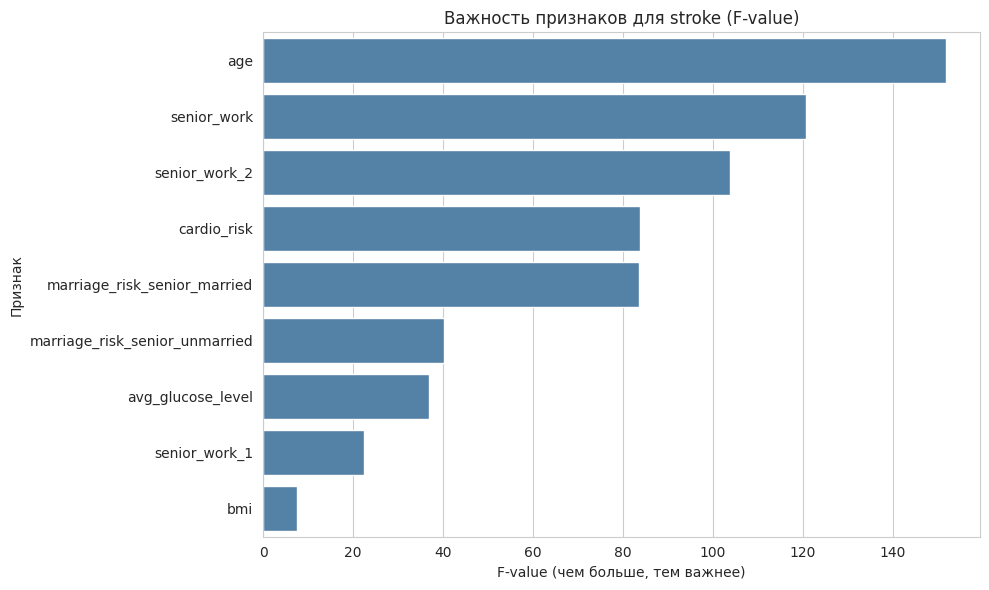


✓ График сохранён: plots/target_fvalue.png

💡 Интерпретация:
   🟢 p < 0.01 — высокая значимость
   🟡 0.01 ≤ p < 0.05 — значим
   🔴 p ≥ 0.05 — статистически незначим (проверьте нелинейность!)

✓ Анализ связи с целевой завершён



In [47]:
# 7.3 СВЯЗЬ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

print("\n" + "="*50)
print("🎯 СВЯЗЬ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*50)

# Используем закодированные данные
data_for_analysis = X_train_encoded if 'X_train_encoded' in locals() and X_train_encoded is not None else X_train

if data_for_analysis is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Числовые колонки
    numeric_cols = data_for_analysis.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()

    if len(numeric_cols) == 0:
        print("\n⚠️ Нет числовых колонок для анализа")
    else:
        print(f"\n📊 Числовых признаков: {len(numeric_cols)}")

        if TASK_TYPE == 'regression':
            # Корреляция Пирсона
            print("\n📈 Корреляция Пирсона с целевой переменной:\n")

            target_corr = {}
            for col in numeric_cols:
                corr_val = data_for_analysis[col].corr(y_train)
                target_corr[col] = corr_val

            target_corr_df = pd.DataFrame({
                'Признак': list(target_corr.keys()),
                'Корреляция': list(target_corr.values())
            }).sort_values('Корреляция', key=abs, ascending=False)

            # Добавляем уровень (красный — требует внимания)
            target_corr_df['Уровень'] = target_corr_df['Корреляция'].apply(
                lambda x: '🔴' if abs(x) < 0.1 else ('🟡' if abs(x) < 0.15 else '🟢')
            )

            display(target_corr_df)

            # Визуализация
            plt.figure(figsize=(10, max(6, len(numeric_cols) * 0.3)))
            colors = ['green' if x > 0 else 'red' for x in target_corr_df['Корреляция']]
            sns.barplot(x='Корреляция', y='Признак', data=target_corr_df, palette=colors)
            plt.title(f'Корреляция признаков с {TARGET_COLUMN}')
            plt.xlabel('Коэффициент корреляции Пирсона')
            plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
            plt.tight_layout()

            plot_path = os.path.join(PLOTS_PATH, 'target_correlation.png')
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.show()
            print(f"\n✓ График сохранён: plots/target_correlation.png")

            # Признаки без линейной связи (требуют внимания)
            weak_features = target_corr_df[abs(target_corr_df['Корреляция']) < 0.1]
            if len(weak_features) > 0:
                print(f"\n🔴 Признаки без линейной связи (|r| < 0.1):")
                for _, row in weak_features.iterrows():
                    print(f"   • {row['Признак']}: {row['Корреляция']:+.3f}")
                print(f"\n   ⚠️ Это НЕ значит, что признаки бесполезны!")
                print(f"      • Проверьте scatter plot — возможна нелинейная зависимость")
                print(f"      • Для RF/XGBoost они могут быть важны")
                print(f"      • Дождитесь RF-важности (блок 8.3) перед удалением")

            print("\n💡 Интерпретация:")
            print("   🟢 |r| ≥ 0.15 — значимая линейная связь")
            print("   🟡 0.10 ≤ |r| < 0.15 — слабая линейная связь")
            print("   🔴 |r| < 0.10 — линейная связь отсутствует (проверьте нелинейность!)")

        else:  # classification
            # ANOVA F-value
            print("\n📊 ANOVA F-value (классификация):\n")

            f_values, p_values = f_classif(data_for_analysis[numeric_cols], y_train)

            f_corr_df = pd.DataFrame({
                'Признак': numeric_cols,
                'F-value': f_values,
                'p-value': p_values
            }).sort_values('F-value', ascending=False)

            # Добавляем уровень значимости (красный — требует внимания)
            f_corr_df['Значимость'] = f_corr_df['p-value'].apply(
                lambda x: '🔴' if x >= 0.05 else ('🟡' if x >= 0.01 else '🟢')
            )

            display(f_corr_df.round(4))

            # Визуализация
            plt.figure(figsize=(10, max(6, len(numeric_cols) * 0.3)))
            colors = ['lightgray' if p >= 0.05 else 'steelblue' for p in f_corr_df['p-value']]
            sns.barplot(x='F-value', y='Признак', data=f_corr_df, palette=colors)
            plt.title(f'Важность признаков для {TARGET_COLUMN} (F-value)')
            plt.xlabel('F-value (чем больше, тем важнее)')
            plt.tight_layout()

            plot_path = os.path.join(PLOTS_PATH, 'target_fvalue.png')
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.show()
            print(f"\n✓ График сохранён: plots/target_fvalue.png")

            # Статистически незначимые признаки (требуют внимания)
            insignificant = f_corr_df[f_corr_df['p-value'] >= 0.05]
            if len(insignificant) > 0:
                print(f"\n🔴 Статистически незначимые признаки (p ≥ 0.05):")
                for _, row in insignificant.iterrows():
                    print(f"   • {row['Признак']}: p={row['p-value']:.4f}")
                print(f"\n   ⚠️ Это НЕ значит, что признаки бесполезны!")
                print(f"      • ANOVA проверяет разницу средних между классами")
                print(f"      • Возможна нелинейная связь или взаимодействия")
                print(f"      • Проверьте boxplot по классам")
                print(f"      • Дождитесь RF-важности (блок 8.3) перед удалением")

            print("\n💡 Интерпретация:")
            print("   🟢 p < 0.01 — высокая значимость")
            print("   🟡 0.01 ≤ p < 0.05 — значим")
            print("   🔴 p ≥ 0.05 — статистически незначим (проверьте нелинейность!)")

print("\n" + "="*50)
print("✓ Анализ связи с целевой завершён")
print("="*50 + "\n")

In [48]:
# 7.4 УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ КОРРЕЛЯЦИОННОГО АНАЛИЗА

print("\n" + "="*50)
print("🗑️ УДАЛЕНИЕ ПРИЗНАКОВ (КОРРЕЛЯЦИОННЫЙ ОТБОР)")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    if features_to_drop:
        print(f"\n📋 Признаки для удаления ({len(features_to_drop)}):")
        print(f"   {features_to_drop}")

        # Удаляем из X_train
        existing_cols = [col for col in features_to_drop if col in X_train.columns]
        if existing_cols:
            X_train.drop(columns=existing_cols, inplace=True)
            print(f"\n   ✓ X_train: удалено {len(existing_cols)}")

        # Удаляем из X_train_encoded
        if 'X_train_encoded' in locals() and X_train_encoded is not None:
            existing_enc = [col for col in features_to_drop if col in X_train_encoded.columns]
            if existing_enc:
                X_train_encoded.drop(columns=existing_enc, inplace=True)
                print(f"   ✓ X_train_encoded: удалено {len(existing_enc)}")

        # Удаляем из X_val, X_test
        for var_name in ['X_val', 'X_test']:
            if var_name in locals() and locals()[var_name] is not None:
                df = locals()[var_name]
                existing = [col for col in features_to_drop if col in df.columns]
                if existing:
                    df.drop(columns=existing, inplace=True)
                    print(f"   ✓ {var_name}: удалено {len(existing)}")

        # Проверка
        not_found = [col for col in features_to_drop if col not in X_train.columns]
        if not_found:
            print(f"\n   ⚠️ Не найдены: {not_found}")

    else:
        print("\n⚠️ features_to_drop пуст.")
        print("   Заполните его в блоке 1.2 на основе:")
        print("   • Сильных корреляций между признаками (блок 7.2)")
        print("   • Слабой связи с целевой (блок 7.3)")
        print("\n📝 Пример:")
        print("   features_to_drop = ['highly_correlated_1', 'weak_feature_2']")

    # Итоговая форма
    print(f"\n📊 Форма X_train: {X_train.shape[0]} строк, {X_train.shape[1]} колонок")
    if 'X_train_encoded' in locals() and X_train_encoded is not None:
        print(f"📊 Форма X_train_encoded: {X_train_encoded.shape[0]} строк, {X_train_encoded.shape[1]} колонок")

    # Сохраняем checkpoint
    cleaned_path = os.path.join(CHECKPOINT_PATH, '06_features_selected.csv')
    X_train.to_csv(cleaned_path, index=False)
    print(f"\n✓ Сохранено: checkpoints/06_features_selected.csv")

print("\n" + "="*50)
print("✓ Удаление признаков завершено")
print("="*50 + "\n")


🗑️ УДАЛЕНИЕ ПРИЗНАКОВ (КОРРЕЛЯЦИОННЫЙ ОТБОР)

📋 Признаки для удаления (3):
   ['senior_work', 'senior_work_1', 'senior_work_2']

   ✓ X_train: удалено 3
   ✓ X_train_encoded: удалено 3

   ⚠️ Не найдены: ['senior_work', 'senior_work_1', 'senior_work_2']

📊 Форма X_train: 2911 строк, 5 колонок
📊 Форма X_train_encoded: 2911 строк, 6 колонок

✓ Сохранено: checkpoints/06_features_selected.csv

✓ Удаление признаков завершено



# БЛОК 8. Random Forest

In [49]:
# 8.1 ПОДГОТОВКА ДАННЫХ ДЛЯ RANDOM FOREST

print("\n" + "="*50)
print("🌲 ПОДГОТОВКА ДАННЫХ ДЛЯ RANDOM FOREST")
print("="*50)

if X_train is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
    X_rf = None
else:
    # Проверяем, есть ли закодированные данные
    if 'X_train_encoded' not in locals() or X_train_encoded is None:
        print("\n❌ X_train_encoded не найден!")
        print("   Random Forest требует числовые признаки.")
        print("   Сначала выполните блок 7.1 (Кодирование категориальных признаков).")
        X_rf = None
    else:
        # Все возможные числовые типы
        numeric_types = ['int16', 'int32', 'int64', 'Int64',
                         'float16', 'float32', 'float64',
                         'uint8', 'uint16', 'uint32', 'uint64',
                         'bool']

        numeric_cols_for_rf = X_train_encoded.select_dtypes(include=numeric_types).columns.tolist()
        X_rf = X_train_encoded[numeric_cols_for_rf]

        print(f"\n✓ Подготовлено признаков для RF: {X_rf.shape[1]}")
        print(f"   Всего признаков в X_train_encoded: {X_train_encoded.shape[1]}")

        # Исключённые колонки
        excluded = set(X_train_encoded.columns) - set(numeric_cols_for_rf)
        if excluded:
            print(f"\n⚠️ Исключены (не числовые):")
            for col in sorted(excluded):
                print(f"   • {col} ({X_train_encoded[col].dtype})")
            print(f"\n💡 Проверьте encoding_config — эти колонки не были закодированы!")

        print(f"\n📊 Размер данных для RF: {X_rf.shape}")
        print(f"   Целевая переменная: {y_train.shape}")

print("\n" + "="*50)
if X_rf is not None:
    print("✓ Подготовка завершена")
else:
    print("⚠️ Подготовка не выполнена")
print("="*50 + "\n")


🌲 ПОДГОТОВКА ДАННЫХ ДЛЯ RANDOM FOREST

✓ Подготовлено признаков для RF: 6
   Всего признаков в X_train_encoded: 6

📊 Размер данных для RF: (2911, 6)
   Целевая переменная: (2911,)

✓ Подготовка завершена




🌲 ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ (RANDOM FOREST)

📊 RandomForestClassifier
   n_estimators=100, class_weight=balanced

⏳ Обучение модели...
   ✓ Модель обучена

📊 Суммарная важность: 1.0000

📋 Распределение важности:
   🟢 Высокая (>0.05): 4 признаков
   🟡 Средняя (0.01-0.05): 2 признаков

🏆 ТОП-признаки:
   1. age: 0.3817 (38.2%)
   2. avg_glucose_level: 0.2559 (25.6%)
   3. bmi: 0.2532 (25.3%)
   4. marriage_risk_senior_married: 0.0542 (5.4%)
   5. cardio_risk: 0.0426 (4.3%)

📈 Накопленная важность:
   50% важности: 2 признаков
   80% важности: 3 признаков
   90% важности: 4 признаков
   95% важности: 5 признаков

💡 РЕКОМЕНДАЦИИ:


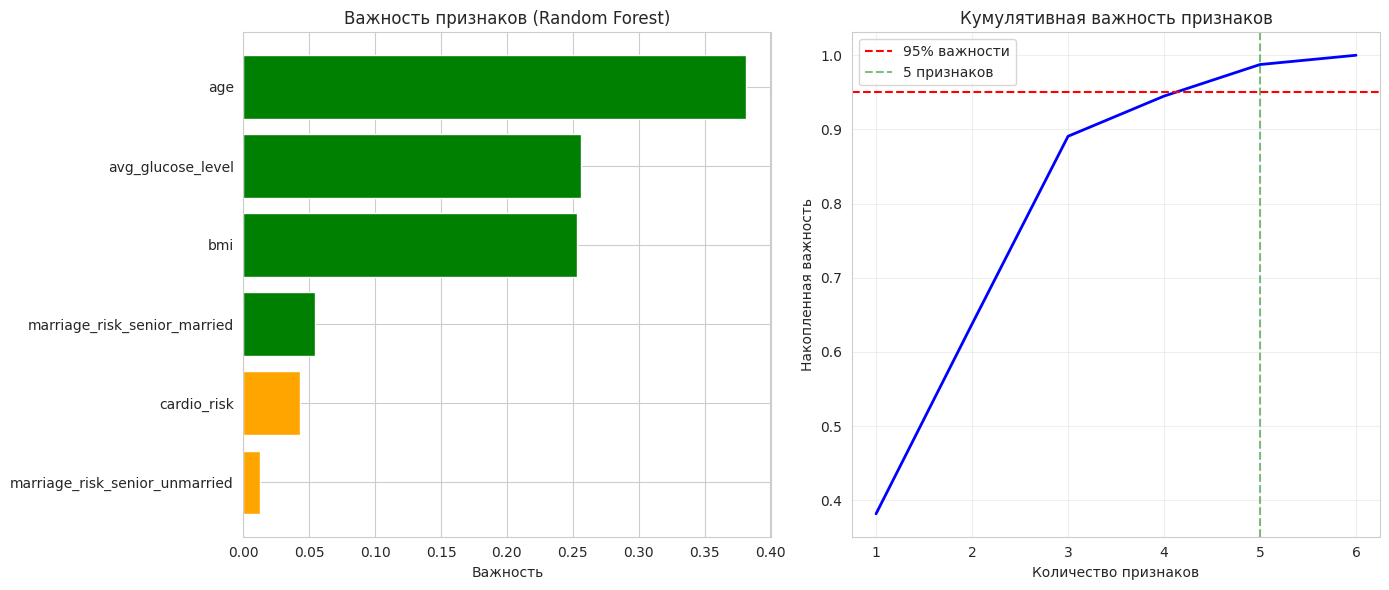


✓ График сохранён: plots/feature_importance_rf.png
✓ Модель сохранена: transformers/random_forest_importance.pkl

✓ Оценка важности завершена



In [50]:
# 8.2 ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ (RANDOM FOREST)

print("\n" + "="*50)
print("🌲 ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ (RANDOM FOREST)")
print("="*50)

if 'X_rf' not in locals() or X_rf is None:
    print("\n⚠️ X_rf не найден. Выполните блок 8.1.")
elif y_train is None:
    print("\n⚠️ y_train не загружен.")
else:
    # Выбор модели
    if TASK_TYPE == 'classification':
        rf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS if 'RF_N_ESTIMATORS' in globals() else 100,
        random_state=RANDOM_STATE if 'RANDOM_STATE' in globals() else 42,
            n_jobs=-1,
            class_weight=RF_CLASS_WEIGHT
        )
        print(f"\n📊 RandomForestClassifier")
        print(f"   n_estimators=100, class_weight={RF_CLASS_WEIGHT}")
    else:
        rf = RandomForestRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE if 'RANDOM_STATE' in globals() else 42,
            n_jobs=-1
        )
        print(f"\n📊 RandomForestRegressor")
        print(f"   n_estimators=100")

    # Обучение
    print("\n⏳ Обучение модели...")
    rf.fit(X_rf, y_train)
    print("   ✓ Модель обучена")

    # Важность признаков
    feature_importance = pd.DataFrame({
        'Признак': X_rf.columns,
        'Важность': rf.feature_importances_
    }).sort_values('Важность', ascending=False).reset_index(drop=True)

    feature_importance['Накопленная'] = feature_importance['Важность'].cumsum()

    # Суммарная важность
    total_importance = feature_importance['Важность'].sum()
    print(f"\n📊 Суммарная важность: {total_importance:.4f}")

    # Категории важности
    feature_importance['Категория'] = feature_importance['Важность'].apply(lambda x:
        '🟢 Высокая (>0.05)' if x > 0.05 else
        ('🟡 Средняя (0.01-0.05)' if x >= 0.01 else '🔴 Низкая (<0.01)'))

    category_counts = feature_importance['Категория'].value_counts()

    print(f"\n📋 Распределение важности:")
    for cat, count in category_counts.items():
        print(f"   {cat}: {count} признаков")

    # Топ-признаки
    print(f"\n🏆 ТОП-признаки:")
    for i, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
        print(f"   {i}. {row['Признак']}: {row['Важность']:.4f} ({row['Важность']/total_importance*100:.1f}%)")

    # Признаки с нулевой важностью
    zero_importance = feature_importance[feature_importance['Важность'] == 0]
    if len(zero_importance) > 0:
        print(f"\n⚠️ Признаки с НУЛЕВОЙ важностью ({len(zero_importance)}):")
        for _, row in zero_importance.iterrows():
            print(f"   • {row['Признак']}")
        print(f"\n   💡 Эти признаки НЕ влияют на модель — рекомендуются к удалению")

    # Признаки с низкой важностью
    low_importance = feature_importance[(feature_importance['Важность'] > 0) & (feature_importance['Важность'] < 0.01)]
    if len(low_importance) > 0:
        print(f"\n🔴 Признаки с низкой важностью (<0.01) ({len(low_importance)}):")
        for _, row in low_importance.head(10).iterrows():
            print(f"   • {row['Признак']}: {row['Важность']:.4f}")
        if len(low_importance) > 10:
            print(f"   ... и ещё {len(low_importance) - 10}")

    # Накопленная важность
    print(f"\n📈 Накопленная важность:")

    thresholds = [0.5, 0.8, 0.9, 0.95]
    for thresh in thresholds:
        mask = feature_importance['Накопленная'] >= thresh
        if mask.any():
            n_features = mask.idxmax() + 1
        else:
            n_features = len(feature_importance)
        pct = int(thresh * 100)
        print(f"   {pct}% важности: {n_features} признаков")

    # Рекомендации
    print(f"\n💡 РЕКОМЕНДАЦИИ:")

    candidates_to_drop = []
    if len(zero_importance) > 0:
        candidates_to_drop.extend(zero_importance['Признак'].tolist())
        print(f"   • Удалить признаки с нулевой важностью ({len(zero_importance)} шт.)")

    if len(low_importance) > 0:
        print(f"   • Рассмотреть удаление признаков с важностью <0.01 ({len(low_importance)} шт.)")
        candidates_to_drop.extend(low_importance['Признак'].tolist())

    if candidates_to_drop:
        print(f"\n📝 Кандидаты на удаление (всего {len(candidates_to_drop)}):")
        print(f"   features_to_drop_rf = {candidates_to_drop}")

    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # График 1: важность признаков
    colors = ['green' if x > 0.05 else ('orange' if x >= 0.01 else 'red') for x in feature_importance['Важность']]
    axes[0].barh(range(len(feature_importance)), feature_importance['Важность'].values, color=colors)
    axes[0].set_yticks(range(len(feature_importance)))
    axes[0].set_yticklabels(feature_importance['Признак'].values)
    axes[0].set_xlabel('Важность')
    axes[0].set_title('Важность признаков (Random Forest)')
    axes[0].invert_yaxis()

    # График 2: кумулятивная важность
    axes[1].plot(range(1, len(feature_importance) + 1),
                 feature_importance['Накопленная'].values,
                 'b-', linewidth=2)
    axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% важности')
    axes[1].set_xlabel('Количество признаков')
    axes[1].set_ylabel('Накопленная важность')
    axes[1].set_title('Кумулятивная важность признаков')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Количество признаков для 95% важности
    mask_95 = feature_importance['Накопленная'] >= 0.95
    n_95 = mask_95.idxmax() + 1 if mask_95.any() else len(feature_importance)
    axes[1].axvline(x=n_95, color='g', linestyle='--', alpha=0.5, label=f'{n_95} признаков')
    axes[1].legend()

    plt.tight_layout()
    plot_path = os.path.join(PLOTS_PATH, 'feature_importance_rf.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ График сохранён: plots/feature_importance_rf.png")

    # Сохраняем модель
    model_path = os.path.join(TRANSFORMERS_PATH, 'random_forest_importance.pkl')
    joblib.dump(rf, model_path)
    print(f"✓ Модель сохранена: transformers/random_forest_importance.pkl")

print("\n" + "="*50)
print("✓ Оценка важности завершена")
print("="*50 + "\n")

In [51]:
# 8.4 ОТБОР ПРИЗНАКОВ НА ОСНОВЕ RANDOM FOREST

print("\n" + "="*50)
print("🗑️ ОТБОР ПРИЗНАКОВ (RANDOM FOREST)")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    if features_to_drop_rf:
        print(f"\n📋 Признаки для удаления ({len(features_to_drop_rf)}):")
        print(f"   {features_to_drop_rf}")

        # Статистика до
        shape_before = X_train.shape

        # Удаляем из X_train
        existing_train = [f for f in features_to_drop_rf if f in X_train.columns]
        if existing_train:
            X_train.drop(columns=existing_train, inplace=True)
            print(f"\n   ✓ X_train: удалено {len(existing_train)}")

        # Удаляем из X_train_encoded
        if 'X_train_encoded' in locals() and X_train_encoded is not None:
            existing_enc = [f for f in features_to_drop_rf if f in X_train_encoded.columns]
            if existing_enc:
                X_train_encoded.drop(columns=existing_enc, inplace=True)
                print(f"   ✓ X_train_encoded: удалено {len(existing_enc)}")

        # Удаляем из X_val
        if 'X_val' in locals() and X_val is not None:
            existing_val = [f for f in features_to_drop_rf if f in X_val.columns]
            if existing_val:
                X_val.drop(columns=existing_val, inplace=True)
                print(f"   ✓ X_val: удалено {len(existing_val)}")

        # Удаляем из X_test
        if 'X_test' in locals() and X_test is not None:
            existing_test = [f for f in features_to_drop_rf if f in X_test.columns]
            if existing_test:
                X_test.drop(columns=existing_test, inplace=True)
                print(f"   ✓ X_test: удалено {len(existing_test)}")

        # Не найденные признаки
        not_found = [f for f in features_to_drop_rf if f not in X_train.columns]
        if not_found:
            print(f"\n   ⚠️ Не найдены: {not_found}")

        # Статистика после
        shape_after = X_train.shape
        print(f"\n📊 Изменения:")
        print(f"   Признаков было: {shape_before[1]}")
        print(f"   Признаков стало: {shape_after[1]}")
        print(f"   Удалено: {shape_before[1] - shape_after[1]}")

    else:
        print("\n✅ features_to_drop_rf пуст — удаление не требуется")
        print("   Заполните на основе анализа важности (блок 8.3)")

    # Сохраняем checkpoint
    cleaned_path = os.path.join(CHECKPOINT_PATH, '07_rf_selected.csv')
    X_train.to_csv(cleaned_path, index=False)
    print(f"\n✓ Сохранено: checkpoints/07_rf_selected.csv")

print("\n" + "="*50)
print("✓ Отбор признаков завершён")
print("="*50 + "\n")


🗑️ ОТБОР ПРИЗНАКОВ (RANDOM FOREST)

✅ features_to_drop_rf пуст — удаление не требуется
   Заполните на основе анализа важности (блок 8.3)

✓ Сохранено: checkpoints/07_rf_selected.csv

✓ Отбор признаков завершён



# БЛОК 9. Обучение трансформеров

In [52]:
# 9.1 ОПРЕДЕЛЕНИЕ ТИПОВ КОЛОНОК ДЛЯ МАСШТАБИРОВАНИЯ

print("\n" + "="*50)
print("🔍 ОПРЕДЕЛЕНИЕ ТИПОВ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
    df_for_analysis = None
else:
    # Выбираем правильный DataFrame
    if 'X_train_encoded' in locals() and X_train_encoded is not None:
        df_for_analysis = X_train_encoded
        source = "X_train_encoded"
    elif 'X_train_scaled' in locals() and X_train_scaled is not None:
        df_for_analysis = X_train_scaled
        source = "X_train_scaled"
    else:
        df_for_analysis = X_train
        source = "X_train"

    print(f"\n📌 Источник данных: {source}")
    print(f"   Размер: {df_for_analysis.shape}")

    # Определяем типы колонок
    numeric_types = ['int16', 'int32', 'int64', 'Int64',
                     'float16', 'float32', 'float64',
                     'uint8', 'uint16', 'uint32', 'uint64',
                     'bool']

    numeric_cols_final = df_for_analysis.select_dtypes(include=numeric_types).columns.tolist()
    categorical_cols_final = df_for_analysis.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    # Статистика
    print(f"\n📊 Состав признаков:")
    print(f"   Числовые: {len(numeric_cols_final)}")
    print(f"   Категориальные: {len(categorical_cols_final)}")

    # Детали по числовым
    if numeric_cols_final:
        # Разделяем на непрерывные и бинарные
        continuous = [c for c in numeric_cols_final if df_for_analysis[c].nunique() > 2]
        binary = [c for c in numeric_cols_final if df_for_analysis[c].nunique() <= 2]

        print(f"\n🔢 Числовые признаки:")
        print(f"   Непрерывные ({len(continuous)}): {continuous if len(continuous) <= 5 else continuous[:5] + ['...']}")
        print(f"   Бинарные ({len(binary)}): {binary if len(binary) <= 5 else binary[:5] + ['...']}")

        if continuous:
            print(f"\n💡 Непрерывные признаки требуют масштабирования")
            print(f"   Рекомендуемые методы:")
            print(f"   • StandardScaler — для нормально распределённых")
            print(f"   • RobustScaler — при наличии выбросов")
            print(f"   • MinMaxScaler — для нейронных сетей")

    # Категориальные
    if categorical_cols_final:
        print(f"\n🏷️ Категориальные признаки ({len(categorical_cols_final)}):")
        for col in categorical_cols_final[:10]:
            print(f"   • {col} ({df_for_analysis[col].nunique()} значений)")
        if len(categorical_cols_final) > 10:
            print(f"   ... и ещё {len(categorical_cols_final) - 10}")

        print(f"\n⚠️ Категориальные признаки НЕЛЬЗЯ использовать в линейных моделях!")
        print(f"   Выполните кодирование (блок 7.1) или используйте tree-based модели")

print("\n" + "="*50)
print("✓ Анализ типов завершён")
print("="*50 + "\n")


🔍 ОПРЕДЕЛЕНИЕ ТИПОВ КОЛОНОК

📌 Источник данных: X_train_encoded
   Размер: (2911, 6)

📊 Состав признаков:
   Числовые: 6
   Категориальные: 0

🔢 Числовые признаки:
   Непрерывные (3): ['age', 'avg_glucose_level', 'bmi']
   Бинарные (3): ['cardio_risk', 'marriage_risk_senior_married', 'marriage_risk_senior_unmarried']

💡 Непрерывные признаки требуют масштабирования
   Рекомендуемые методы:
   • StandardScaler — для нормально распределённых
   • RobustScaler — при наличии выбросов
   • MinMaxScaler — для нейронных сетей

✓ Анализ типов завершён



In [53]:
# 9.2 МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ

print("\n" + "="*50)
print("📐 МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*50)

# Выбираем данные для масштабирования
if 'X_train_encoded' in locals() and X_train_encoded is not None:
    data_to_scale = X_train_encoded.copy()
    source = "X_train_encoded"
elif X_train is not None:
    data_to_scale = X_train.copy()
    source = "X_train"
    print("\n⚠️ X_train_encoded не найден, используем X_train")
else:
    print("\n⚠️ Данные не загружены. Пропускаем.")
    data_to_scale = None

if data_to_scale is not None:
    X_train_scaled = data_to_scale.copy()
    scalers = {}

    if scaling_config:
        print(f"\n📊 Источник: {source}")
        print(f"   Применяем масштабирование:\n")

        for col, (method, params) in scaling_config.items():
            if col not in X_train_scaled.columns:
                print(f"   ⚠️ {col}: не найдена, пропускаем")
                continue

            if method == 'none':
                print(f"   • {col}: без масштабирования")
                continue

            # Выбор scaler'а
            if method == 'standard':
                scaler = StandardScaler()
                scaler_name = "StandardScaler"
            elif method == 'robust':
                scaler = RobustScaler()
                scaler_name = "RobustScaler"
            elif method == 'minmax':
                scaler = MinMaxScaler()
                scaler_name = "MinMaxScaler"
            else:
                print(f"   ⚠️ {col}: неизвестный метод '{method}'")
                continue

            # Статистика ДО
            mean_before = X_train_scaled[col].mean()
            std_before = X_train_scaled[col].std()

            # Масштабирование
            X_train_scaled[col] = scaler.fit_transform(X_train_scaled[[col]]).flatten()
            scalers[col] = scaler

            # Статистика ПОСЛЕ
            mean_after = X_train_scaled[col].mean()
            std_after = X_train_scaled[col].std()

            print(f"   ✓ {col}: {scaler_name}")
            print(f"      до: μ={mean_before:.3f}, σ={std_before:.3f}")
            print(f"      после: μ={mean_after:.3f}, σ={std_after:.3f}")

        # Сохраняем scaler'ы
        if scalers:
            scalers_path = os.path.join(TRANSFORMERS_PATH, 'scalers.pkl')
            joblib.dump(scalers, scalers_path)
            print(f"\n✅ Scaler'ы сохранены: transformers/scalers.pkl")
    else:
        print("\n⚠️ scaling_config пуст, масштабирование не применяется")
        print("   Заполните его в блоке 1.2")
        print("\n📝 Пример:")
        print("   scaling_config = {")
        print("       'age': ('standard', None),")
        print("       'bmi': ('robust', None),")
        print("   }")

    print(f"\n📊 Форма данных: {X_train_scaled.shape}")

    # Сохраняем масштабированные данные
    scaled_path = os.path.join(SPLITS_PATH, 'X_train_scaled.csv')
    X_train_scaled.to_csv(scaled_path, index=False)
    print(f"✓ Данные сохранены: splits/X_train_scaled.csv")

print("\n" + "="*50)
print("✓ Масштабирование завершено")
print("="*50 + "\n")


📐 МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ

📊 Источник: X_train_encoded
   Применяем масштабирование:

   ✓ age: StandardScaler
      до: μ=43.597, σ=22.163
      после: μ=0.000, σ=1.000
   ✓ avg_glucose_level: RobustScaler
      до: μ=105.000, σ=44.721
      после: μ=0.378, σ=1.227
   ✓ bmi: RobustScaler
      до: μ=28.879, σ=7.439
      после: μ=0.084, σ=0.800

✅ Scaler'ы сохранены: transformers/scalers.pkl

📊 Форма данных: (2911, 6)
✓ Данные сохранены: splits/X_train_scaled.csv

✓ Масштабирование завершено



In [54]:
# 9.3 ФИНАЛЬНОЕ УДАЛЕНИЕ ПРИЗНАКОВ

print("\n" + "="*50)
print("🗑️ ФИНАЛЬНОЕ УДАЛЕНИЕ ПРИЗНАКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    if columns_to_drop_final:
        print(f"\n📋 Признаки для удаления ({len(columns_to_drop_final)}):")
        print(f"   {columns_to_drop_final}")

        # Статистика до
        shape_before = X_train.shape

        # Удаляем из X_train
        existing_train = [col for col in columns_to_drop_final if col in X_train.columns]
        if existing_train:
            X_train.drop(columns=existing_train, inplace=True)
            print(f"\n   ✓ X_train: удалено {len(existing_train)}")

        # Удаляем из X_train_encoded
        if 'X_train_encoded' in locals() and X_train_encoded is not None:
            existing_enc = [col for col in columns_to_drop_final if col in X_train_encoded.columns]
            if existing_enc:
                X_train_encoded.drop(columns=existing_enc, inplace=True)
                print(f"   ✓ X_train_encoded: удалено {len(existing_enc)}")

        # Удаляем из X_train_scaled
        if 'X_train_scaled' in locals() and X_train_scaled is not None:
            existing_scaled = [col for col in columns_to_drop_final if col in X_train_scaled.columns]
            if existing_scaled:
                X_train_scaled.drop(columns=existing_scaled, inplace=True)
                print(f"   ✓ X_train_scaled: удалено {len(existing_scaled)}")

        # Удаляем из X_val и X_test
        for var_name in ['X_val', 'X_test']:
            if var_name in locals() and locals()[var_name] is not None:
                df = locals()[var_name]
                existing = [col for col in columns_to_drop_final if col in df.columns]
                if existing:
                    df.drop(columns=existing, inplace=True)
                    print(f"   ✓ {var_name}: удалено {len(existing)}")

        # Не найденные
        not_found = [col for col in columns_to_drop_final if col not in X_train.columns]
        if not_found:
            print(f"\n   ⚠️ Не найдены: {not_found}")

        # Статистика после
        shape_after = X_train.shape
        print(f"\n📊 Изменения:")
        print(f"   Признаков было: {shape_before[1]}")
        print(f"   Признаков стало: {shape_after[1]}")
        print(f"   Удалено: {shape_before[1] - shape_after[1]}")

    else:
        print("\n✅ columns_to_drop_final пуст — удаление не требуется")

    # Финальные формы
    print(f"\n📊 Финальные размеры:")
    print(f"   X_train: {X_train.shape}")
    if 'X_train_encoded' in locals() and X_train_encoded is not None:
        print(f"   X_train_encoded: {X_train_encoded.shape}")
    if 'X_train_scaled' in locals() and X_train_scaled is not None:
        print(f"   X_train_scaled: {X_train_scaled.shape}")

    # Сохраняем финальный checkpoint
    final_path = os.path.join(CHECKPOINT_PATH, '08_final_X_train.csv')
    X_train.to_csv(final_path, index=False)
    print(f"\n✓ Сохранено: checkpoints/08_final_X_train.csv")

    if 'X_train_scaled' in locals() and X_train_scaled is not None:
        final_scaled_path = os.path.join(CHECKPOINT_PATH, '08_final_X_train_scaled.csv')
        X_train_scaled.to_csv(final_scaled_path, index=False)
        print(f"✓ Сохранено: checkpoints/08_final_X_train_scaled.csv")

print("\n" + "="*50)
print("✓ Финальное удаление завершено")
print("="*50 + "\n")


🗑️ ФИНАЛЬНОЕ УДАЛЕНИЕ ПРИЗНАКОВ

✅ columns_to_drop_final пуст — удаление не требуется

📊 Финальные размеры:
   X_train: (2911, 5)
   X_train_encoded: (2911, 6)
   X_train_scaled: (2911, 6)

✓ Сохранено: checkpoints/08_final_X_train.csv
✓ Сохранено: checkpoints/08_final_X_train_scaled.csv

✓ Финальное удаление завершено



In [55]:
# 9.4 СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ И МЕТАДАННЫХ

print("\n" + "="*50)
print("💾 СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ")
print("="*50)

if X_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Определяем основную версию данных
    if 'X_train_scaled' in locals() and X_train_scaled is not None:
        data_for_meta = X_train_scaled
        data_version = "scaled"
    elif 'X_train_encoded' in locals() and X_train_encoded is not None:
        data_for_meta = X_train_encoded
        data_version = "encoded"
    else:
        data_for_meta = X_train
        data_version = "raw"

    print(f"\n📌 Основная версия данных: {data_version}")
    print(f"   Размер: {data_for_meta.shape}")

    # --------------------------------------------
    # Сохранение данных
    # --------------------------------------------
    saved_files = []

    # Для деревьев (encoded)
    if 'X_train_encoded' in locals() and X_train_encoded is not None:
        path = os.path.join(SPLITS_PATH, 'X_train_encoded.csv')
        X_train_encoded.to_csv(path, index=False)
        saved_files.append('X_train_encoded.csv')
        print(f"   ✓ X_train_encoded.csv (для деревьев)")

    # Для линейных моделей (scaled)
    if 'X_train_scaled' in locals() and X_train_scaled is not None:
        path = os.path.join(SPLITS_PATH, 'X_train_scaled.csv')
        X_train_scaled.to_csv(path, index=False)
        saved_files.append('X_train_scaled.csv')
        print(f"   ✓ X_train_scaled.csv (для линейных моделей)")

        # Финальный checkpoint
        checkpoint_path = os.path.join(CHECKPOINT_PATH, '09_final_processed.csv')
        X_train_scaled.to_csv(checkpoint_path, index=False)
        print(f"   ✓ checkpoints/09_final_processed.csv")

    # Если нет ни encoded, ни scaled — сохраняем X_train
    if not saved_files:
        path = os.path.join(SPLITS_PATH, 'X_train_final.csv')
        X_train.to_csv(path, index=False)
        print(f"   ✓ X_train_final.csv")

    # --------------------------------------------
    # Метаданные трансформаций
    # --------------------------------------------
    transformations_meta = {
        "data_version": data_version,
        "scaling_config": scaling_config if 'scaling_config' in globals() else {},
        "encoding_config": encoding_config if 'encoding_config' in globals() else {},
        "columns_to_drop_final": columns_to_drop_final if 'columns_to_drop_final' in globals() else [],
        "final_shape": list(data_for_meta.shape),
        "final_columns": list(data_for_meta.columns),
        "date_processed": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    # Информация о scaler'ах
    if 'scalers' in locals() and scalers:
        transformations_meta["scalers"] = {
            col: type(scaler).__name__ for col, scaler in scalers.items()
        }

    # Информация об encoder'ах
    if 'encoders' in locals() and encoders:
        transformations_meta["encoders"] = {
            col: info['method'] for col, info in encoders.items()
        }

    meta_path = os.path.join(PROJECT_PATH, 'transformations_metadata.json')
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(transformations_meta, f, indent=2, ensure_ascii=False)
    print(f"\n✓ transformations_metadata.json")

    # --------------------------------------------
    # Production метаданные
    # --------------------------------------------
    # Получаем original_shape
    if 'original_shape' in globals():
        orig_features = original_shape[1]
    elif 'metadata' in locals() and metadata:
        orig_features = metadata.get('feature_count', data_for_meta.shape[1])
    else:
        orig_features = data_for_meta.shape[1]

    production_metadata = {
        "project_name": PROJECT_NAME,
        "target_column": metadata.get('target_column', TARGET_COLUMN) if 'metadata' in locals() else TARGET_COLUMN,
        "task_type": TASK_TYPE if 'TASK_TYPE' in globals() else 'classification',
        "features": {
            "all_features": data_for_meta.columns.tolist(),
            "original_count": orig_features,
            "final_count": data_for_meta.shape[1]
        },
        "transformers": {
            "scalers": list(scalers.keys()) if 'scalers' in locals() and scalers else [],
            "encoders": list(encoders.keys()) if 'encoders' in locals() and encoders else []
        },
        "shapes": {
            "n_samples": len(data_for_meta),
            "n_features": data_for_meta.shape[1]
        },
        "date_processed": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "package_versions": PACKAGE_VERSIONS if 'PACKAGE_VERSIONS' in globals() else {}
    }

    prod_meta_path = os.path.join(PROJECT_PATH, 'production_metadata.json')
    with open(prod_meta_path, 'w', encoding='utf-8') as f:
        json.dump(production_metadata, f, indent=2, ensure_ascii=False)
    print(f"✓ production_metadata.json")

    # --------------------------------------------
    # Итоговая сводка
    # --------------------------------------------
    print("\n" + "="*50)
    print("📊 ИТОГОВАЯ СВОДКА")
    print("="*50)
    print(f"   Финальных признаков: {data_for_meta.shape[1]}")
    print(f"   Сэмплов в train: {data_for_meta.shape[0]}")
    print(f"   Масштабирование: {'✓' if 'scalers' in locals() and scalers else '—'}")
    print(f"   Кодирование: {'✓' if 'encoders' in locals() and encoders else '—'}")
    print(f"\n📁 Результаты сохранены в: {PROJECT_PATH}")

    print("\n✅ Данные полностью готовы для обучения модели!")

print("\n" + "="*50)
print("✓ Сохранение завершено")
print("="*50 + "\n")


💾 СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ

📌 Основная версия данных: scaled
   Размер: (2911, 6)
   ✓ X_train_encoded.csv (для деревьев)
   ✓ X_train_scaled.csv (для линейных моделей)
   ✓ checkpoints/09_final_processed.csv

✓ transformations_metadata.json
✓ production_metadata.json

📊 ИТОГОВАЯ СВОДКА
   Финальных признаков: 6
   Сэмплов в train: 2911
   Масштабирование: ✓
   Кодирование: ✓

📁 Результаты сохранены в: /content/drive/MyDrive/ml_learning/datasets/stroke

✅ Данные полностью готовы для обучения модели!

✓ Сохранение завершено



In [56]:
# 9.5 ПРИМЕНЕНИЕ ТРАНСФОРМАЦИЙ К VAL/TEST

print("\n" + "="*50)
print("🔄 ПРИМЕНЕНИЕ ТРАНСФОРМАЦИЙ К VAL/TEST")
print("="*50)

# Проверяем наличие файлов
val_path = os.path.join(SPLITS_PATH, 'X_val.csv')
test_path = os.path.join(SPLITS_PATH, 'X_test.csv')
y_val_path = os.path.join(SPLITS_PATH, 'y_val.csv')
y_test_path = os.path.join(SPLITS_PATH, 'y_test.csv')

if not os.path.exists(val_path) or not os.path.exists(test_path):
    print("\n⚠️ Файлы X_val.csv или X_test.csv не найдены.")
    print("   Запустите preprocessing для создания val/test.")
else:
    # Загружаем val/test
    X_val = pd.read_csv(val_path)
    X_test = pd.read_csv(test_path)
    print(f"\n✓ Загружены: X_val {X_val.shape}, X_test {X_test.shape}")

    # Загружаем y_val, y_test если есть
    y_val = pd.read_csv(y_val_path).iloc[:, 0] if os.path.exists(y_val_path) else None
    y_test = pd.read_csv(y_test_path).iloc[:, 0] if os.path.exists(y_test_path) else None

    # Определяем эталон
    if 'X_train_scaled' in locals() and X_train_scaled is not None:
        train_processed = X_train_scaled
        print("📌 Эталон: X_train_scaled")
    elif 'X_train_encoded' in locals() and X_train_encoded is not None:
        train_processed = X_train_encoded
        print("📌 Эталон: X_train_encoded")
    else:
        train_processed = X_train
        print("📌 Эталон: X_train")

    X_val_processed = X_val.copy()
    X_test_processed = X_test.copy()

    # --------------------------------------------
    # 1. Масштабирование
    # --------------------------------------------
    if 'scalers' in locals() and scalers:
        print("\n📊 Масштабирование:")
        for col, scaler in scalers.items():
            if col in X_val_processed.columns:
                X_val_processed[col] = scaler.transform(X_val_processed[[col]]).flatten()
                X_test_processed[col] = scaler.transform(X_test_processed[[col]]).flatten()
                print(f"   ✓ {col}")

    # --------------------------------------------
    # 2. Кодирование
    # --------------------------------------------
    if 'encoders' in locals() and encoders:
        print("\n📊 Кодирование:")

        for col, info in encoders.items():
            method = info.get('method', 'none')

            if col not in X_val_processed.columns:
                print(f"   ⚠️ {col}: не найдена, пропускаем")
                continue

            if method == 'one_hot':
                dummy_cols = info.get('columns', [])
                for dummy_col in dummy_cols:
                    category = dummy_col.replace(f"{col}_", "")
                    X_val_processed[dummy_col] = (X_val_processed[col] == category).astype(int)
                    X_test_processed[dummy_col] = (X_test_processed[col] == category).astype(int)
                X_val_processed.drop(columns=[col], inplace=True)
                X_test_processed.drop(columns=[col], inplace=True)
                print(f"   ✓ {col}: ONE-HOT → {len(dummy_cols)} колонок")

            elif method == 'label':
                le = info['encoder']
                # Обработка новых категорий
                X_val_processed[col] = X_val_processed[col].astype(str).map(
                    lambda x: le.transform([x])[0] if x in le.classes_ else -1
                )
                X_test_processed[col] = X_test_processed[col].astype(str).map(
                    lambda x: le.transform([x])[0] if x in le.classes_ else -1
                )
                print(f"   ✓ {col}: LABEL")

            elif method == 'target':
                mapping = info.get('mapping', {})
                global_mean = info.get('global_mean', 0)
                new_col = f"{col}_target"
                X_val_processed[new_col] = X_val_processed[col].map(mapping).fillna(global_mean)
                X_test_processed[new_col] = X_test_processed[col].map(mapping).fillna(global_mean)
                X_val_processed.drop(columns=[col], inplace=True)
                X_test_processed.drop(columns=[col], inplace=True)
                print(f"   ✓ {col}: TARGET → {new_col}")

            elif method == 'frequency':
                mapping = info.get('mapping', {})
                new_col = f"{col}_freq"
                X_val_processed[new_col] = X_val_processed[col].map(mapping).fillna(0)
                X_test_processed[new_col] = X_test_processed[col].map(mapping).fillna(0)
                X_val_processed.drop(columns=[col], inplace=True)
                X_test_processed.drop(columns=[col], inplace=True)
                print(f"   ✓ {col}: FREQUENCY → {new_col}")

            elif method == 'none':
                pass
            else:
                print(f"   ⚠️ {col}: неизвестный метод '{method}'")

    # --------------------------------------------
    # 3. Приведение к структуре эталона
    # --------------------------------------------
    expected_cols = train_processed.columns.tolist()

    # Добавляем недостающие
    missing_val = [col for col in expected_cols if col not in X_val_processed.columns]
    for col in missing_val:
        X_val_processed[col] = 0
        X_test_processed[col] = 0

    if missing_val:
        print(f"\n   ➕ Добавлено колонок: {len(missing_val)}")

    # Удаляем лишние
    extra_val = [col for col in X_val_processed.columns if col not in expected_cols]
    if extra_val:
        X_val_processed.drop(columns=extra_val, inplace=True)
        X_test_processed.drop(columns=extra_val, inplace=True)
        print(f"   🗑️ Удалено лишних: {len(extra_val)}")

    # Приводим порядок
    X_val_processed = X_val_processed[expected_cols]
    X_test_processed = X_test_processed[expected_cols]

    # --------------------------------------------
    # 4. Сохранение
    # --------------------------------------------
    val_final_path = os.path.join(SPLITS_PATH, 'X_val_final.csv')
    test_final_path = os.path.join(SPLITS_PATH, 'X_test_final.csv')

    X_val_processed.to_csv(val_final_path, index=False)
    X_test_processed.to_csv(test_final_path, index=False)

    print(f"\n✅ Трансформации применены:")
    print(f"   X_val_final: {X_val_processed.shape}")
    print(f"   X_test_final: {X_test_processed.shape}")

    # Сохраняем y_val, y_test без изменений
    if y_val is not None:
        y_val_final = os.path.join(SPLITS_PATH, 'y_val_final.csv')
        y_val.to_csv(y_val_final, index=False, header=True)
    if y_test is not None:
        y_test_final = os.path.join(SPLITS_PATH, 'y_test_final.csv')
        y_test.to_csv(y_test_final, index=False, header=True)

print("\n" + "="*50)
print("✓ Применение трансформаций завершено")
print("="*50 + "\n")


🔄 ПРИМЕНЕНИЕ ТРАНСФОРМАЦИЙ К VAL/TEST

✓ Загружены: X_val (971, 10), X_test (971, 10)
📌 Эталон: X_train_scaled

📊 Масштабирование:
   ✓ age
   ✓ avg_glucose_level
   ✓ bmi

📊 Кодирование:
   ⚠️ marriage_risk: не найдена, пропускаем

   ➕ Добавлено колонок: 3
   🗑️ Удалено лишних: 7

✅ Трансформации применены:
   X_val_final: (971, 6)
   X_test_final: (971, 6)

✓ Применение трансформаций завершено



In [57]:
# 9.6 ИТОГОВЫЙ ОТЧЁТ EDA

print("\n" + "="*50)
print("📋 ИТОГОВЫЙ ОТЧЁТ EDA")
print("="*50)

# Собираем отчёт в список для сохранения
report_lines = []
report_lines.append("=" * 60)
report_lines.append("ИТОГОВЫЙ ОТЧЁТ EDA")
report_lines.append("=" * 60)
report_lines.append(f"Проект: {PROJECT_NAME}")
report_lines.append(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("")

print("\n📊 ИТОГИ ОБРАБОТКИ:")
print("-" * 40)
report_lines.append("ИТОГИ ОБРАБОТКИ:")
report_lines.append("-" * 40)

# Исходная форма
if 'original_shape' in locals():
    print(f"   Исходный X_train: {original_shape[0]} × {original_shape[1]}")
    report_lines.append(f"   Исходный X_train: {original_shape[0]} × {original_shape[1]}")
else:
    print(f"   Исходный X_train: форма не сохранена")
    report_lines.append(f"   Исходный X_train: форма не сохранена")

# Финальная форма
if 'X_train_scaled' in locals() and X_train_scaled is not None:
    final_df = X_train_scaled
    final_name = "X_train_scaled"
elif 'X_train_encoded' in locals() and X_train_encoded is not None:
    final_df = X_train_encoded
    final_name = "X_train_encoded"
else:
    final_df = X_train
    final_name = "X_train"

print(f"   Финальный {final_name}: {final_df.shape[0]} × {final_df.shape[1]}")
print(f"   Тип задачи: {TASK_TYPE.upper()}")
report_lines.append(f"   Финальный {final_name}: {final_df.shape[0]} × {final_df.shape[1]}")
report_lines.append(f"   Тип задачи: {TASK_TYPE.upper()}")
report_lines.append("")

print("\n🔧 ПРИМЕНЁННЫЕ ТРАНСФОРМАЦИИ:")
print("-" * 40)
report_lines.append("ПРИМЕНЁННЫЕ ТРАНСФОРМАЦИИ:")
report_lines.append("-" * 40)

# Масштабирование
if 'scalers' in locals() and scalers:
    print(f"   ✅ Масштабирование ({len(scalers)} колонок):")
    report_lines.append(f"   ✅ Масштабирование ({len(scalers)} колонок):")
    for col, scaler in scalers.items():
        scaler_name = type(scaler).__name__
        print(f"      - {col}: {scaler_name}")
        report_lines.append(f"      - {col}: {scaler_name}")
elif 'scaling_config' in locals() and scaling_config:
    active_scaling = {c: m for c, (m, _) in scaling_config.items() if m != 'none'}
    if active_scaling:
        print(f"   ✅ Масштабирование ({len(active_scaling)} колонок):")
        report_lines.append(f"   ✅ Масштабирование ({len(active_scaling)} колонок):")
        for col, method in active_scaling.items():
            print(f"      - {col}: {method.upper()}")
            report_lines.append(f"      - {col}: {method.upper()}")
    else:
        print("   ⚠️ Масштабирование не применялось")
        report_lines.append("   ⚠️ Масштабирование не применялось")
else:
    print("   ⚠️ Масштабирование не применялось")
    report_lines.append("   ⚠️ Масштабирование не применялось")

# Кодирование
if 'encoders' in locals() and encoders:
    print(f"   ✅ Кодирование ({len(encoders)} колонок):")
    report_lines.append(f"   ✅ Кодирование ({len(encoders)} колонок):")
    for col, info in encoders.items():
        method = info['method'].upper()
        print(f"      - {col}: {method}")
        report_lines.append(f"      - {col}: {method}")
elif 'encoding_config' in locals() and encoding_config:
    active_encoding = {c: m for c, (m, _) in encoding_config.items() if m != 'none'}
    if active_encoding:
        print(f"   ✅ Кодирование ({len(active_encoding)} колонок):")
        report_lines.append(f"   ✅ Кодирование ({len(active_encoding)} колонок):")
        for col, method in active_encoding.items():
            print(f"      - {col}: {method.upper()}")
            report_lines.append(f"      - {col}: {method.upper()}")
    else:
        print("   ⚠️ Кодирование не применялось")
        report_lines.append("   ⚠️ Кодирование не применялось")
else:
    print("   ⚠️ Кодирование не применялось")
    report_lines.append("   ⚠️ Кодирование не применялось")

# Удаление колонок
total_dropped = 0
if 'columns_to_drop_final' in locals() and columns_to_drop_final:
    total_dropped += len(columns_to_drop_final)
if 'features_to_drop' in locals() and features_to_drop:
    total_dropped += len(features_to_drop)
if 'features_to_drop_rf' in locals() and features_to_drop_rf:
    total_dropped += len(features_to_drop_rf)

if total_dropped > 0:
    print(f"   🗑️ Удалено колонок: {total_dropped}")
    report_lines.append(f"   🗑️ Удалено колонок: {total_dropped}")

report_lines.append("")

print("\n📁 СОХРАНЁННЫЕ ФАЙЛЫ:")
print("-" * 40)
report_lines.append("СОХРАНЁННЫЕ ФАЙЛЫ:")
report_lines.append("-" * 40)

if 'X_train_encoded' in locals() and X_train_encoded is not None:
    print(f"   - Для деревьев: splits/X_train_encoded.csv")
    report_lines.append(f"   - Для деревьев: splits/X_train_encoded.csv")
if 'X_train_scaled' in locals() and X_train_scaled is not None:
    print(f"   - Для линейных моделей: splits/X_train_scaled.csv")
    report_lines.append(f"   - Для линейных моделей: splits/X_train_scaled.csv")
if os.path.exists(os.path.join(SPLITS_PATH, 'X_val_final.csv')):
    print(f"   - Val/Test: splits/X_val_final.csv, splits/X_test_final.csv")
    report_lines.append(f"   - Val/Test: splits/X_val_final.csv, splits/X_test_final.csv")

print(f"   - Метаданные: {PROJECT_PATH}/")
print(f"   - Графики: {PLOTS_PATH}/")
report_lines.append(f"   - Метаданные: {PROJECT_PATH}/")
report_lines.append(f"   - Графики: {PLOTS_PATH}/")
report_lines.append("")

print("\n📊 СТАТИСТИКА ФИНАЛЬНЫХ ДАННЫХ:")
print("-" * 40)
report_lines.append("СТАТИСТИКА ФИНАЛЬНЫХ ДАННЫХ:")
report_lines.append("-" * 40)

num_count = final_df.select_dtypes(include=['int64', 'Int64', 'float64', 'uint8', 'bool']).shape[1]
cat_count = final_df.select_dtypes(include=['object', 'category']).shape[1]
null_count = final_df.isnull().sum().sum()

print(f"   Числовых колонок: {num_count}")
print(f"   Категориальных колонок: {cat_count}")
print(f"   Пропуски: {null_count}")
report_lines.append(f"   Числовых колонок: {num_count}")
report_lines.append(f"   Категориальных колонок: {cat_count}")
report_lines.append(f"   Пропуски: {null_count}")
report_lines.append("")

print("\n" + "="*50)
print("✅ EDA ЗАВЕРШЁН!")
print("="*50)
report_lines.append("=" * 60)
report_lines.append("EDA ЗАВЕРШЁН")
report_lines.append("=" * 60)

print("\n🎯 СЛЕДУЮЩИЕ ШАГИ (ОБУЧЕНИЕ МОДЕЛИ):")
print("-" * 40)
report_lines.append("СЛЕДУЮЩИЕ ШАГИ:")
report_lines.append("-" * 40)

print("   1. Для Random Forest / XGBoost:")
print("      → X_train_encoded.csv + y_train.csv")
print("   2. Для линейных моделей:")
print("      → X_train_scaled.csv + y_train.csv")
print("   3. Для валидации и теста:")
print("      → X_val_final.csv, X_test_final.csv")
report_lines.append("   1. Для деревьев: X_train_encoded.csv + y_train.csv")
report_lines.append("   2. Для линейных: X_train_scaled.csv + y_train.csv")
report_lines.append("   3. Для валидации: X_val_final.csv, X_test_final.csv")

print("\n💡 РЕКОМЕНДАЦИИ:")
print("-" * 40)
report_lines.append("")
report_lines.append("РЕКОМЕНДАЦИИ:")
report_lines.append("-" * 40)

if TASK_TYPE == 'classification':
    print("   - Для дисбаланса: class_weight='balanced' или SMOTE")
    print("   - Метрики: ROC-AUC, F1-score (не Accuracy)")
    report_lines.append("   - Для дисбаланса: class_weight='balanced' или SMOTE")
    report_lines.append("   - Метрики: ROC-AUC, F1-score (не Accuracy)")
else:
    print("   - Метрики: MAE, RMSE, R²")
    report_lines.append("   - Метрики: MAE, RMSE, R²")

print("   - Сравните деревья и линейные модели на валидации")
report_lines.append("   - Сравните деревья и линейные модели на валидации")

# Сохраняем отчёт
report_path = os.path.join(REPORTS_PATH, 'eda_final_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(report_lines))

print(f"\n✓ Итоговый отчёт сохранён: reports/eda_final_report.txt")
print("="*50 + "\n")


📋 ИТОГОВЫЙ ОТЧЁТ EDA

📊 ИТОГИ ОБРАБОТКИ:
----------------------------------------
   Исходный X_train: 2911 × 10
   Финальный X_train_scaled: 2911 × 6
   Тип задачи: CLASSIFICATION

🔧 ПРИМЕНЁННЫЕ ТРАНСФОРМАЦИИ:
----------------------------------------
   ✅ Масштабирование (3 колонок):
      - age: StandardScaler
      - avg_glucose_level: RobustScaler
      - bmi: RobustScaler
   ✅ Кодирование (1 колонок):
      - marriage_risk: ONE_HOT
   🗑️ Удалено колонок: 3

📁 СОХРАНЁННЫЕ ФАЙЛЫ:
----------------------------------------
   - Для деревьев: splits/X_train_encoded.csv
   - Для линейных моделей: splits/X_train_scaled.csv
   - Val/Test: splits/X_val_final.csv, splits/X_test_final.csv
   - Метаданные: /content/drive/MyDrive/ml_learning/datasets/stroke/
   - Графики: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/

📊 СТАТИСТИКА ФИНАЛЬНЫХ ДАННЫХ:
----------------------------------------
   Числовых колонок: 6
   Категориальных колонок: 0
   Пропуски: 0

✅ EDA ЗАВЕРШЁН!

🎯